# Ames Housing: EDA, Logical Cleaning, Business Insights, and Modeling Preparation

This notebook combines the organized EDA/cleaning/business workflow with the feature-engineering and preprocessing workflow in one coherent sequence.


## 1. Imports and notebook settings

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid")

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    OrdinalEncoder,
)


## 2. Load the dataset and normalize column names

In [106]:
# Load the original dataset.
df = pd.read_csv("AmesHousing.csv")

# Remove spaces and slashes from column names for easier coding.
df.columns = (
    df.columns
    .str.replace(" ", "", regex=False)
    .str.replace("/", "", regex=False)
)

# Keep an untouched copy for raw EDA and before/after comparisons.
df_raw = df.copy()

print("Dataset loaded successfully.")
print("Rows and columns:", df.shape)
print("First five rows:")
print(df.head().to_string(index=False))

Dataset loaded successfully.
Rows and columns: (2930, 82)
First five rows:
 Order       PID  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape LandContour Utilities LotConfig LandSlope Neighborhood Condition1 Condition2 BldgType HouseStyle  OverallQual  OverallCond  YearBuilt  YearRemodAdd RoofStyle RoofMatl Exterior1st Exterior2nd MasVnrType  MasVnrArea ExterQual ExterCond Foundation BsmtQual BsmtCond BsmtExposure BsmtFinType1  BsmtFinSF1 BsmtFinType2  BsmtFinSF2  BsmtUnfSF  TotalBsmtSF Heating HeatingQC CentralAir Electrical  1stFlrSF  2ndFlrSF  LowQualFinSF  GrLivArea  BsmtFullBath  BsmtHalfBath  FullBath  HalfBath  BedroomAbvGr  KitchenAbvGr KitchenQual  TotRmsAbvGrd Functional  Fireplaces FireplaceQu GarageType  GarageYrBlt GarageFinish  GarageCars  GarageArea GarageQual GarageCond PavedDrive  WoodDeckSF  OpenPorchSF  EnclosedPorch  3SsnPorch  ScreenPorch  PoolArea PoolQC Fence MiscFeature  MiscVal  MoSold  YrSold SaleType SaleCondition  SalePrice
     1 526301100   

## 3. Basic dataset inspection

### 3.1 Structure, duplicates, and data types

This cell checks the dataset structure, identifiers, duplicates, and data types before any cleaning.


In [107]:
# Inspect the dataset structure before cleaning.
print("Dataset shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate PIDs:", df["PID"].duplicated().sum())
print("Missing SalePrice values:", df["SalePrice"].isna().sum())

print("\nData types:")
print(df.dtypes.to_string())

Dataset shape: (2930, 82)
Duplicate rows: 0
Duplicate PIDs: 0
Missing SalePrice values: 0

Data types:
Order              int64
PID                int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
Street            object
Alley             object
LotShape          object
LandContour       object
Utilities         object
LotConfig         object
LandSlope         object
Neighborhood      object
Condition1        object
Condition2        object
BldgType          object
HouseStyle        object
OverallQual        int64
OverallCond        int64
YearBuilt          int64
YearRemodAdd       int64
RoofStyle         object
RoofMatl          object
Exterior1st       object
Exterior2nd       object
MasVnrType        object
MasVnrArea       float64
ExterQual         object
ExterCond         object
Foundation        object
BsmtQual          object
BsmtCond          object
BsmtExposure      object
BsmtFinType1      object
BsmtFinSF1       float

### 3.2 Missing-value summary

This cell counts missing values so each column can be handled according to its meaning.


In [108]:
# Count missing values in every column.
missing_summary = df.isna().sum().sort_values(ascending=False)
print(missing_summary.to_string())

PoolQC           2917
MiscFeature      2824
Alley            2732
Fence            2358
MasVnrType       1775
FireplaceQu      1422
LotFrontage       490
GarageCond        159
GarageFinish      159
GarageYrBlt       159
GarageQual        159
GarageType        157
BsmtExposure       83
BsmtFinType2       81
BsmtQual           80
BsmtCond           80
BsmtFinType1       80
MasVnrArea         23
BsmtFullBath        2
BsmtHalfBath        2
BsmtFinSF1          1
GarageCars          1
Electrical          1
TotalBsmtSF         1
BsmtUnfSF           1
BsmtFinSF2          1
GarageArea          1
PavedDrive          0
FullBath            0
HalfBath            0
BedroomAbvGr        0
KitchenAbvGr        0
KitchenQual         0
TotRmsAbvGrd        0
SaleCondition       0
SaleType            0
YrSold              0
MoSold              0
MiscVal             0
Functional          0
Fireplaces          0
PoolArea            0
ScreenPorch         0
3SsnPorch           0
EnclosedPorch       0
OpenPorchS

## 4. Target variable and feature groups

In [109]:
# SalePrice is the target variable for a future house-price model.
target = "SalePrice"

print("Target variable:", target)
print("Target data type:", df[target].dtype)
print("Target minimum:", df[target].min())
print("Target maximum:", df[target].max())

# SalePrice remains unchanged during EDA/cleaning. Any target transformation is deferred to the train-only modeling stage.
feature_groups = {
    "Identifiers - keep for audit, exclude from modeling": ["Order", "PID"],
    "Land and location": [
        "MSSubClass", "MSZoning", "LotFrontage", "LotArea", "Street", "Alley",
        "LotShape", "LandContour", "Utilities", "LotConfig", "LandSlope",
        "Neighborhood", "Condition1", "Condition2"
    ],
    "Building structure": [
        "BldgType", "HouseStyle", "YearBuilt", "YearRemodAdd",
        "Foundation", "RoofStyle", "RoofMatl"
    ],
    "Exterior quality and materials": [
        "Exterior1st", "Exterior2nd", "MasVnrType", "MasVnrArea",
        "ExterQual", "ExterCond"
    ],
    "Overall quality and functionality": [
        "OverallQual", "OverallCond", "Functional"
    ],
    "Basement": [
        "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinSF1",
        "BsmtFinType2", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF",
        "BsmtFullBath", "BsmtHalfBath"
    ],
    "Heating and electrical": [
        "Heating", "HeatingQC", "CentralAir", "Electrical"
    ],
    "Living area and rooms": [
        "1stFlrSF", "2ndFlrSF", "LowQualFinSF", "GrLivArea", "FullBath",
        "HalfBath", "BedroomAbvGr", "KitchenAbvGr", "KitchenQual", "TotRmsAbvGrd"
    ],
    "Fireplace": ["Fireplaces", "FireplaceQu"],
    "Garage": [
        "GarageType", "GarageYrBlt", "GarageFinish", "GarageCars", "GarageArea",
        "GarageQual", "GarageCond", "PavedDrive"
    ],
    "Outdoor features": [
        "WoodDeckSF", "OpenPorchSF", "EnclosedPorch", "3SsnPorch",
        "ScreenPorch", "PoolArea", "PoolQC", "Fence", "MiscFeature", "MiscVal"
    ],
    "Sale information": ["MoSold", "YrSold", "SaleType", "SaleCondition"]
}

# Verify that every non-target column belongs to exactly one group.
grouped_columns = [
    column
    for columns in feature_groups.values()
    for column in columns
]

assert set(grouped_columns) | {target} == set(df.columns)
assert len(grouped_columns) == len(set(grouped_columns))

for group, columns in feature_groups.items():
    print(f"\n{group}:")
    print(", ".join(columns))

print("\nAll columns are classified exactly once.")
print("Total columns:", len(df.columns))
print("Feature columns including identifiers:", len(grouped_columns))

Target variable: SalePrice
Target data type: int64
Target minimum: 12789
Target maximum: 755000

Identifiers - keep for audit, exclude from modeling:
Order, PID

Land and location:
MSSubClass, MSZoning, LotFrontage, LotArea, Street, Alley, LotShape, LandContour, Utilities, LotConfig, LandSlope, Neighborhood, Condition1, Condition2

Building structure:
BldgType, HouseStyle, YearBuilt, YearRemodAdd, Foundation, RoofStyle, RoofMatl

Exterior quality and materials:
Exterior1st, Exterior2nd, MasVnrType, MasVnrArea, ExterQual, ExterCond

Overall quality and functionality:
OverallQual, OverallCond, Functional

Basement:
BsmtQual, BsmtCond, BsmtExposure, BsmtFinType1, BsmtFinSF1, BsmtFinType2, BsmtFinSF2, BsmtUnfSF, TotalBsmtSF, BsmtFullBath, BsmtHalfBath

Heating and electrical:
Heating, HeatingQC, CentralAir, Electrical

Living area and rooms:
1stFlrSF, 2ndFlrSF, LowQualFinSF, GrLivArea, FullBath, HalfBath, BedroomAbvGr, KitchenAbvGr, KitchenQual, TotRmsAbvGrd

Fireplace:
Fireplaces, Firepla

### 4.1 Feature catalog

This cell creates a compact table showing each feature group, data type, missing count, and number of unique values.


In [110]:
# Build a compact feature catalog for dataset understanding.
feature_catalog = []

for group, columns in feature_groups.items():
    for column in columns:
        feature_catalog.append({
            "Group": group,
            "Feature": column,
            "Data Type": str(df[column].dtype),
            "Missing Values": df[column].isna().sum(),
            "Unique Values": df[column].nunique(dropna=True)
        })

feature_catalog = pd.DataFrame(feature_catalog)
print(feature_catalog.to_string(index=False))

                                              Group       Feature Data Type  Missing Values  Unique Values
Identifiers - keep for audit, exclude from modeling         Order     int64               0           2930
Identifiers - keep for audit, exclude from modeling           PID     int64               0           2930
                                  Land and location    MSSubClass     int64               0             16
                                  Land and location      MSZoning    object               0              7
                                  Land and location   LotFrontage   float64             490            128
                                  Land and location       LotArea     int64               0           1960
                                  Land and location        Street    object               0              2
                                  Land and location         Alley    object            2732              2
                                  Lan

## 5. Cleaning-focused EDA on the original data

These visualizations are kept before cleaning because they help diagnose missingness, outliers, distributions, and relationships that guide cleaning decisions.


### 5.1 Descriptive statistics

In [111]:
# Describe numerical and categorical variables.
print("Numerical descriptive statistics:")
print(df_raw.describe().T.to_string())

print("\nCategorical descriptive statistics:")
print(df_raw.describe(include="object").T.to_string())

Numerical descriptive statistics:
                count          mean           std          min           25%          50%           75%           max
Order          2930.0  1.465500e+03  8.459625e+02          1.0  7.332500e+02       1465.5  2.197750e+03  2.930000e+03
PID            2930.0  7.144645e+08  1.887308e+08  526301100.0  5.284770e+08  535453620.0  9.071811e+08  1.007100e+09
MSSubClass     2930.0  5.738737e+01  4.263802e+01         20.0  2.000000e+01         50.0  7.000000e+01  1.900000e+02
LotFrontage    2440.0  6.922459e+01  2.336533e+01         21.0  5.800000e+01         68.0  8.000000e+01  3.130000e+02
LotArea        2930.0  1.014792e+04  7.880018e+03       1300.0  7.440250e+03       9436.5  1.155525e+04  2.152450e+05
OverallQual    2930.0  6.094881e+00  1.411026e+00          1.0  5.000000e+00          6.0  7.000000e+00  1.000000e+01
OverallCond    2930.0  5.563140e+00  1.111537e+00          1.0  5.000000e+00          5.0  6.000000e+00  9.000000e+00
YearBuilt      2930.0 

### 5.2 SalePrice distribution

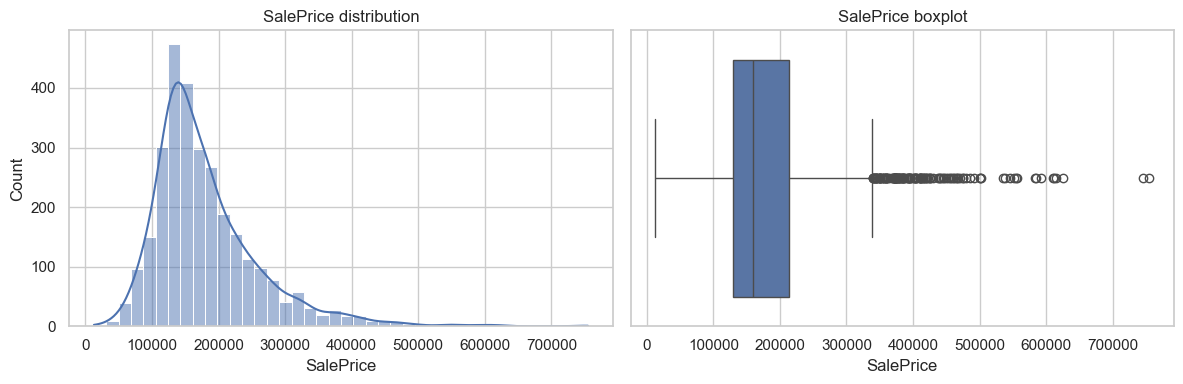

Mean SalePrice: 180796.06
Median SalePrice: 160000.0
SalePrice skewness: 1.744


In [112]:
# Inspect the target distribution, center, spread, and skewness.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df_raw["SalePrice"], bins=40, kde=True, ax=axes[0])
axes[0].set_title("SalePrice distribution")
axes[0].set_xlabel("SalePrice")

sns.boxplot(x=df_raw["SalePrice"], ax=axes[1])
axes[1].set_title("SalePrice boxplot")
axes[1].set_xlabel("SalePrice")

plt.tight_layout()
plt.show()

print("Mean SalePrice:", round(df_raw["SalePrice"].mean(), 2))
print("Median SalePrice:", df_raw["SalePrice"].median())
print("SalePrice skewness:", round(df_raw["SalePrice"].skew(), 3))

### 5.3 Numerical feature distributions

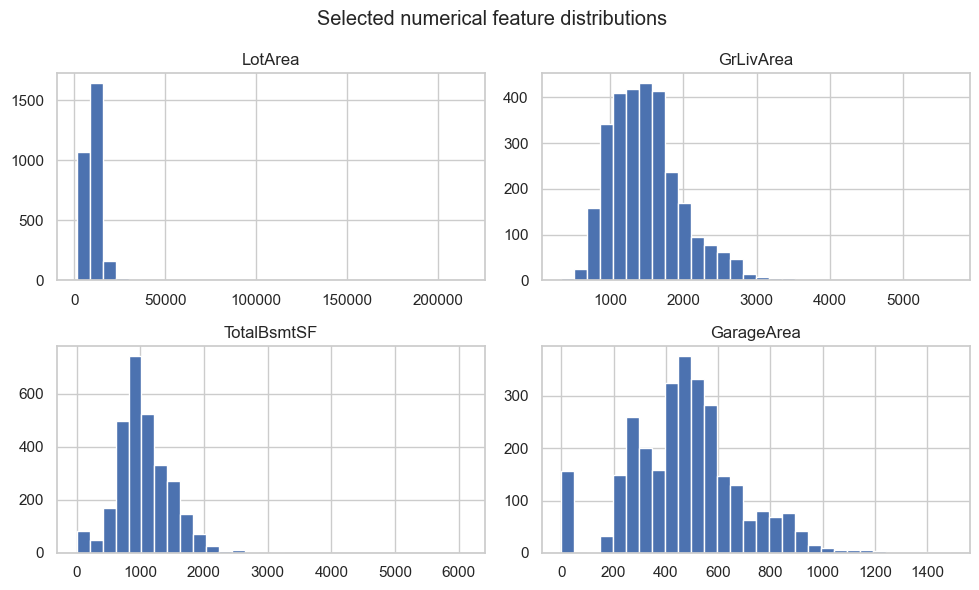

In [113]:
# Inspect important numerical feature distributions.
numeric_cols_to_plot = ["LotArea", "GrLivArea", "TotalBsmtSF", "GarageArea"]

df_raw[numeric_cols_to_plot].hist(bins=30, figsize=(10, 6))
plt.suptitle("Selected numerical feature distributions")
plt.tight_layout()
plt.show()

### 5.4 Outlier inspection

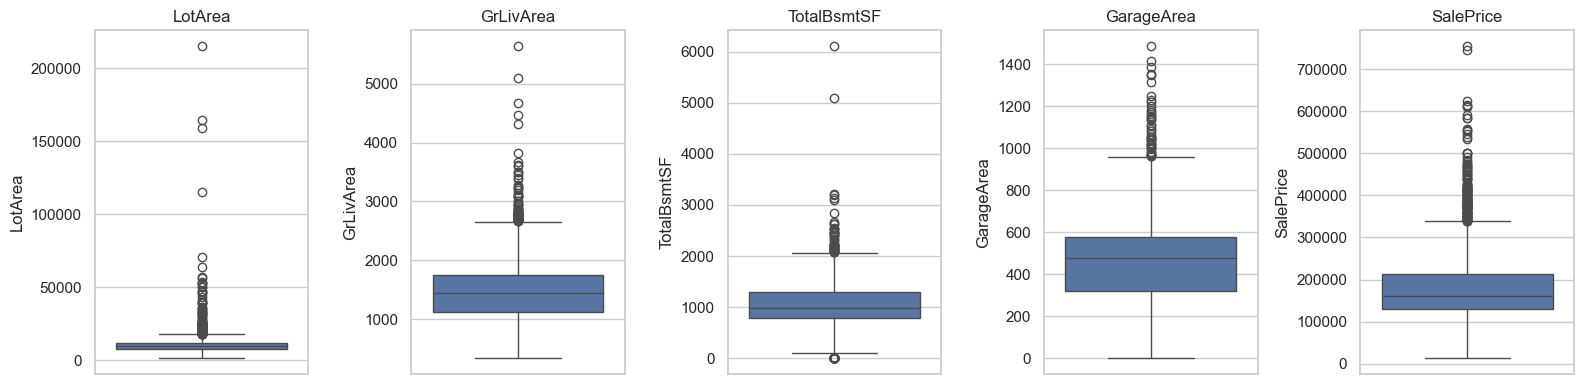

In [114]:
# Use boxplots to inspect unusual values without deleting them automatically.
outlier_columns = ["LotArea", "GrLivArea", "TotalBsmtSF", "GarageArea", "SalePrice"]

fig, axes = plt.subplots(1, len(outlier_columns), figsize=(16, 4))

for axis, column in zip(axes, outlier_columns):
    sns.boxplot(y=df_raw[column], ax=axis)
    axis.set_title(column)

plt.tight_layout()
plt.show()

### 5.5 Relationships with SalePrice

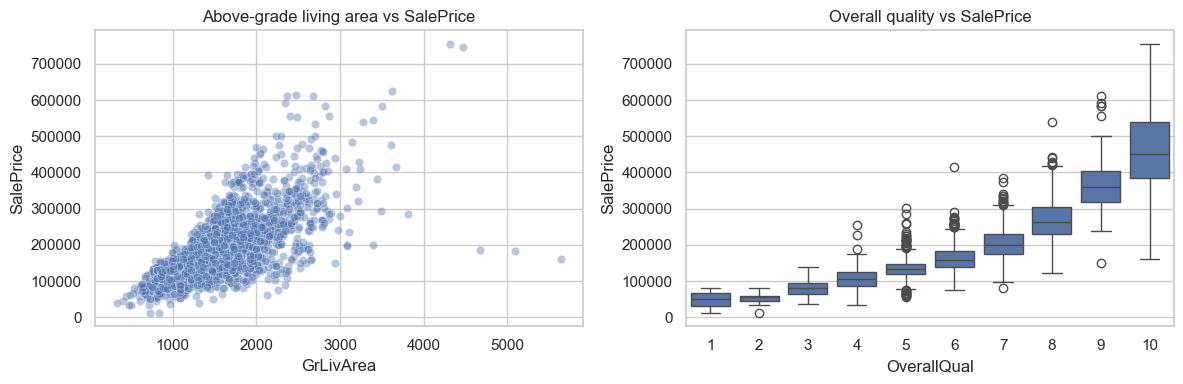

In [115]:
# Inspect relationships between price and important features.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.scatterplot(
    data=df_raw,
    x="GrLivArea",
    y="SalePrice",
    alpha=0.4,
    ax=axes[0]
)
axes[0].set_title("Above-grade living area vs SalePrice")

sns.boxplot(
    data=df_raw,
    x="OverallQual",
    y="SalePrice",
    ax=axes[1]
)
axes[1].set_title("Overall quality vs SalePrice")

plt.tight_layout()
plt.show()

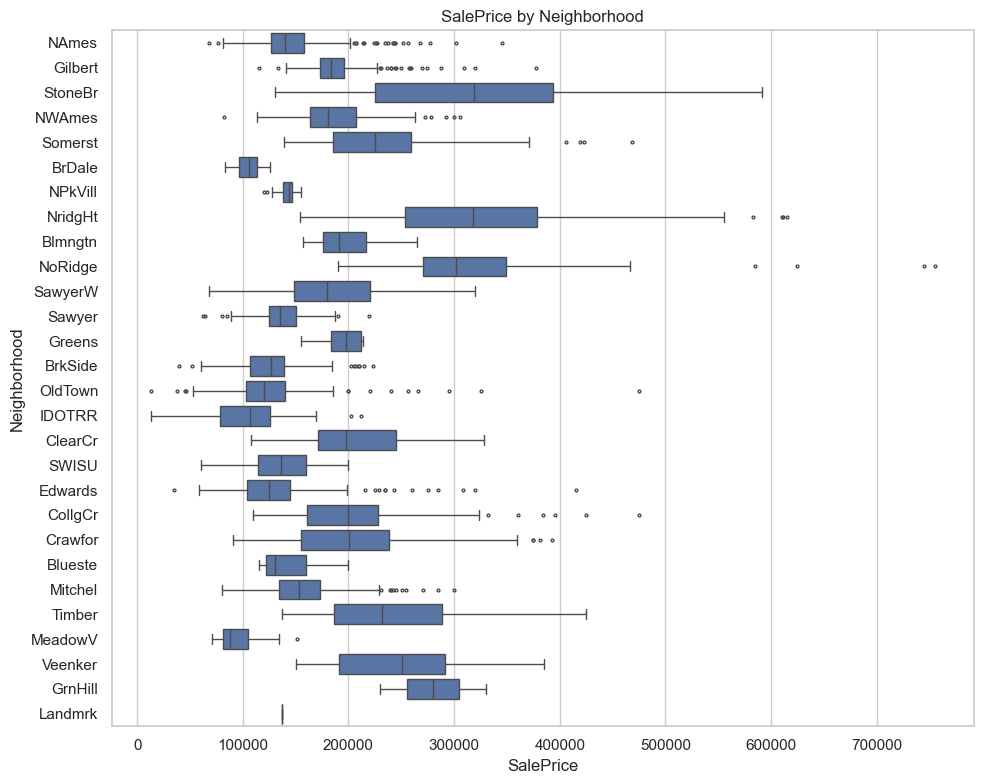

In [116]:
# Compare SalePrice across neighborhoods.
plt.figure(figsize=(10, 8))
sns.boxplot(data=df_raw, x="SalePrice", y="Neighborhood", fliersize=2)
plt.title("SalePrice by Neighborhood")
plt.tight_layout()
plt.show()

### 5.6 Correlations

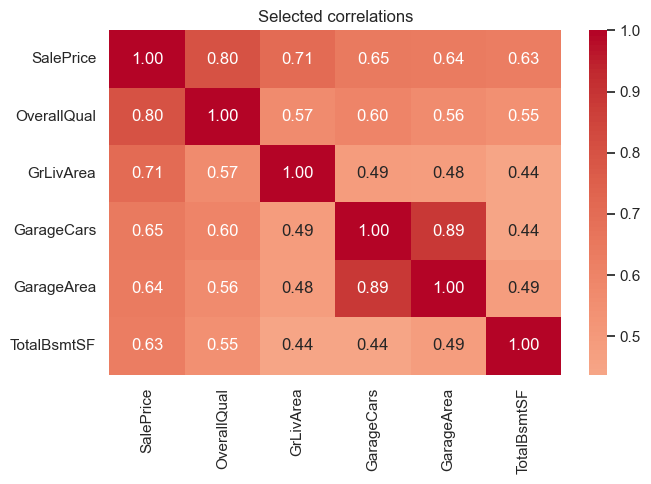

SalePrice      1.000000
OverallQual    0.799262
GrLivArea      0.706780
GarageCars     0.647877
GarageArea     0.640401
TotalBsmtSF    0.632280


In [117]:
# Inspect linear correlations for selected numerical features.
corr_columns = [
    "SalePrice", "OverallQual", "GrLivArea",
    "GarageCars", "GarageArea", "TotalBsmtSF"
]

correlation_matrix = df_raw[corr_columns].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Selected correlations")
plt.tight_layout()
plt.show()

print(correlation_matrix["SalePrice"].sort_values(ascending=False).to_string())

### Manual EDA observations

- SalePrice is right-skewed and contains high-price outliers.
- Higher OverallQual and larger GrLivArea generally correspond to higher prices.
- Neighborhoods have different price ranges.
- GarageCars and GarageArea are strongly related because both describe garage capacity.
- Outliers are reviewed and documented; they are not removed automatically because they may represent valid expensive properties.

### 5.7 Correlation Across All Numerical Features

**Question:** The correlation check above used six hand-picked columns. Are there other
numerical features that correlate strongly with SalePrice but were left out of that selection?

**Analysis:** Computed the correlation of every numerical column against `SalePrice`, ranked by
absolute strength, and re-drew the heatmap using the top correlated features instead of a
hand-picked list.

**Visualization:** Heatmap of the top 12 numerically correlated features with `SalePrice`.

Correlation of all numerical features with SalePrice:
SalePrice        1.000000
OverallQual      0.799262
GrLivArea        0.706780
GarageCars       0.647877
GarageArea       0.640401
TotalBsmtSF      0.632280
1stFlrSF         0.621676
YearBuilt        0.558426
FullBath         0.545604
YearRemodAdd     0.532974
GarageYrBlt      0.526965
MasVnrArea       0.508285
TotRmsAbvGrd     0.495474
Fireplaces       0.474558
BsmtFinSF1       0.432914
LotFrontage      0.357318
WoodDeckSF       0.327143
OpenPorchSF      0.312951
HalfBath         0.285056
BsmtFullBath     0.276050
2ndFlrSF         0.269373
LotArea          0.266549
BsmtUnfSF        0.182855
BedroomAbvGr     0.143913
ScreenPorch      0.112151
PoolArea         0.068403
MoSold           0.035259
3SsnPorch        0.032225
BsmtFinSF2       0.005891
MiscVal         -0.015691
YrSold          -0.030569
Order           -0.031408
BsmtHalfBath    -0.035835
LowQualFinSF    -0.037660
MSSubClass      -0.085092
OverallCond     -0.101697
KitchenAbv

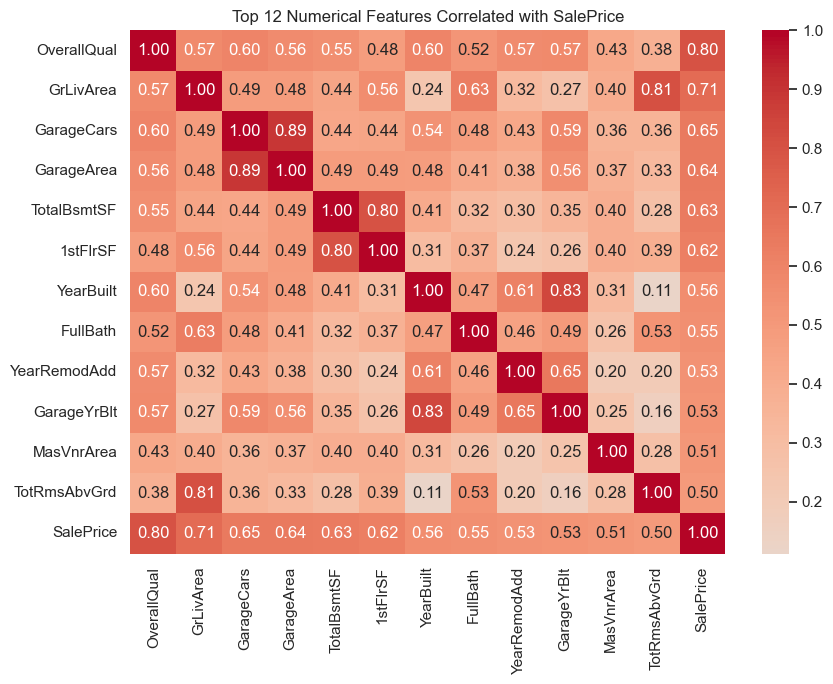

In [118]:
# Correlation of every numerical feature with SalePrice (not just a hand-picked subset).
numeric_df = df_raw.select_dtypes(include=[np.number])
full_corr = numeric_df.corr()["SalePrice"].sort_values(ascending=False)

print("Correlation of all numerical features with SalePrice:")
print(full_corr.to_string())

top_n = 12
top_features = full_corr.drop("SalePrice").abs().sort_values(ascending=False).head(top_n).index.tolist()

plt.figure(figsize=(9, 7))
sns.heatmap(
    numeric_df[top_features + ["SalePrice"]].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title(f"Top {top_n} Numerical Features Correlated with SalePrice")
plt.tight_layout()
plt.show()

**Finding:** `OverallQual` (0.80) and `GrLivArea` (0.71) remain the strongest predictors, as the
original selection already showed. But the full ranking also surfaces `YearBuilt` (0.56),
`FullBath` (0.55), `YearRemodAdd` (0.53), `GarageYrBlt` (0.53), `MasVnrArea` (0.51), and
`TotRmsAbvGrd` (0.50) among the top correlates â€” none of which were in the original six-column
selection.

**Interpretation:** The hand-picked six columns captured the strongest single signal
(`OverallQual`, `GrLivArea`) but missed several features with a meaningfully strong relationship
to price. A model-building step later should consider this fuller ranking rather than only the
features that were visually inspected first.

**Follow-up:** Several of these top features look conceptually related to each other (e.g.
`GarageCars` and `GarageArea` both describe garage capacity). Are any of them redundant?

### 5.8 Multicollinearity Among the Top Predictors

**Question:** Among the features most correlated with SalePrice, which ones are so strongly
correlated *with each other* that they are likely measuring the same underlying thing?

**Analysis:** Computed pairwise correlation among the top 12 SalePrice-correlated features and
flagged every pair with |correlation| above 0.70.

**Visualization:** The correlation heatmap above already shows this; the code below extracts the
specific pairs so they don't have to be read off the heatmap by eye.

In [119]:
# Flag highly correlated (likely redundant) feature pairs among the top predictors.
pair_corr = numeric_df[top_features].corr().abs()

redundant_pairs = []
for i in range(len(top_features)):
    for j in range(i + 1, len(top_features)):
        value = pair_corr.iloc[i, j]
        if value > 0.70:
            redundant_pairs.append((top_features[i], top_features[j], round(value, 2)))

print("Feature pairs with correlation above 0.70:")
for pair in redundant_pairs:
    print(pair)

Feature pairs with correlation above 0.70:
('GrLivArea', 'TotRmsAbvGrd', 0.81)
('GarageCars', 'GarageArea', 0.89)
('TotalBsmtSF', '1stFlrSF', 0.8)
('YearBuilt', 'GarageYrBlt', 0.83)


**Finding:** Four pairs stand out: `GarageCars`â€“`GarageArea` (0.89), `YearBuilt`â€“`GarageYrBlt`
(0.83), `GrLivArea`â€“`TotRmsAbvGrd` (0.81), and `TotalBsmtSF`â€“`1stFlrSF` (0.80).

**Interpretation:** Each pair is really describing the same underlying property characteristic
twice, from slightly different angles: garage capacity in cars vs. square feet, the age of the
house vs. the age of its garage, living area vs. room count, and basement size vs. first-floor
footprint (most houses here have a basement roughly the same footprint as the first floor). This
is exactly the kind of multicollinearity a later modeling step should be aware of â€” keeping both
features in a linear model can inflate coefficient variance without adding real predictive
information.

**Follow-up:** Correlation only captures linear relationships between numeric features â€” what do
the price differences look like across the dataset's *categorical* quality features?

### 5.9 Skewness Across All Numerical Features

**Question:** SalePrice is right-skewed â€” is that unusual, or are many other numerical features
in the dataset just as skewed?

**Analysis:** Computed skewness for every numerical column and ranked the most skewed ones,
rather than only checking the target variable.

**Visualization:** Horizontal bar chart of the most skewed numerical features.

Most skewed numerical features:
MiscVal          21.999788
PoolArea         16.939142
LotArea          12.820898
LowQualFinSF     12.118162
3SsnPorch        11.403795
KitchenAbvGr      4.313825
BsmtFinSF2        4.139978
EnclosedPorch     4.014446
ScreenPorch       3.957467
BsmtHalfBath      3.940795


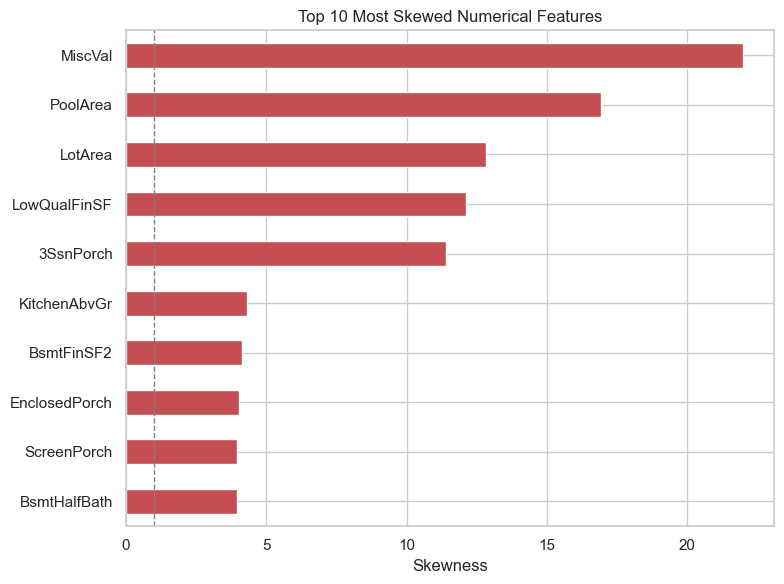

In [120]:
# Skewness across all numerical features, not only SalePrice.
skewness = numeric_df.drop(columns=["SalePrice"]).skew().sort_values(ascending=False)

print("Most skewed numerical features:")
print(skewness.head(10).to_string())

fig, ax = plt.subplots(figsize=(8, 6))
skewness.head(10).sort_values().plot(kind="barh", ax=ax, color="#C44E52")
ax.axvline(1, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Skewness")
ax.set_title("Top 10 Most Skewed Numerical Features")
plt.tight_layout()
plt.show()

**Finding:** Several features are far more skewed than SalePrice itself (skew â‰ˆ 1.74):
`MiscVal` (â‰ˆ22.0), `PoolArea` (â‰ˆ16.9), `LotArea` (â‰ˆ12.8), `LowQualFinSF` (â‰ˆ12.1), and
`3SsnPorch` (â‰ˆ11.4) are all extremely right-skewed.

**Interpretation:** SalePrice's skew is actually mild compared to the rest of the dataset. Most
of the extremely skewed columns (`PoolArea`, `MiscVal`, `3SsnPorch`) are skewed because the
feature is zero for the overwhelming majority of houses and only non-zero for a small minority
that actually have a pool, a miscellaneous feature, or a three-season porch â€” this is a
structural "mostly absent" pattern rather than a continuously-varying measurement. That
distinction matters for whichever transformation strategy is applied later: a log transform
suits a naturally continuous skewed variable (like `LotArea`) very differently than a
mostly-zero indicator-like variable (like `PoolArea`).

**Follow-up:** Do any of the categorical quality ratings (e.g. Kitchen quality) show as strong a
relationship with price as the numerical features already examined?

### 5.10 The GrLivArea Outliers (an Ames-specific exceptional case)

**Question:** The GrLivArea vs. SalePrice scatter plot (5.5) showed a loose upward trend with
some scatter â€” are there specific houses that break that trend in a genuinely unusual way?

**Analysis:** Filtered to houses with `GrLivArea` above 4,000 sq ft â€” well beyond the bulk of the
distribution seen in the 5.3 histogram â€” and inspected them directly by name/ID rather than only
looking at the trend line.

**Visualization:** The same GrLivArea vs. SalePrice scatter plot, with these specific houses
highlighted and labeled.

Properties with GrLivArea > 4000 sq ft:
      PID  GrLivArea  SalePrice  OverallQual Neighborhood
908154235       5642     160000           10      Edwards
908154195       5095     183850           10      Edwards
908154205       4676     184750           10      Edwards
528320050       4476     745000           10      NoRidge
528351010       4316     755000           10      NoRidge


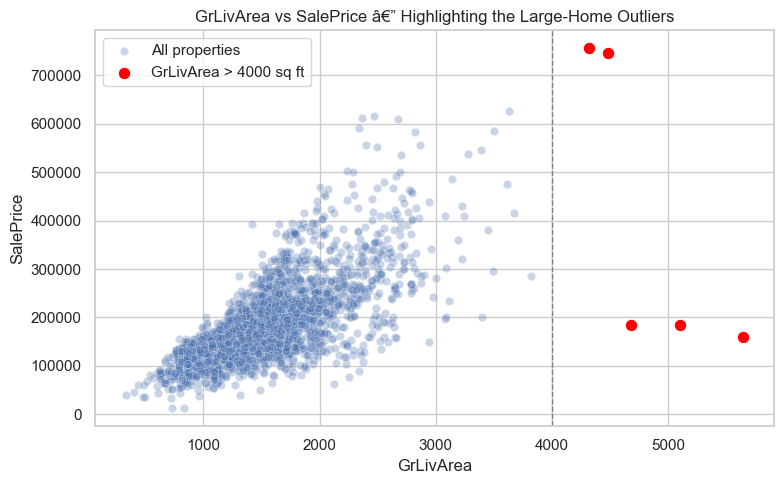

In [121]:
# Identify and label the unusually large properties directly.
large_homes = df_raw[df_raw["GrLivArea"] > 4000][
    ["PID", "GrLivArea", "SalePrice", "OverallQual", "Neighborhood"]
].sort_values("GrLivArea", ascending=False)

print("Properties with GrLivArea > 4000 sq ft:")
print(large_homes.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df_raw, x="GrLivArea", y="SalePrice", alpha=0.3, ax=ax, label="All properties")
sns.scatterplot(
    data=df_raw[df_raw["GrLivArea"] > 4000],
    x="GrLivArea", y="SalePrice",
    color="red", s=80, ax=ax, label="GrLivArea > 4000 sq ft"
)
ax.axvline(4000, color="gray", linestyle="--", linewidth=1)
ax.set_title("GrLivArea vs SalePrice â€” Highlighting the Large-Home Outliers")
ax.legend()
plt.tight_layout()
plt.show()

**Finding:** Five properties exceed 4,000 sq ft of living area. Two of them (in NoRidge) sold
for $745,000 and $755,000, consistent with their size and top `OverallQual` rating of 10. But the
other three â€” all in **Edwards** â€” also have the maximum `OverallQual` of 10 and are even larger
(up to 5,642 sq ft), yet sold for only **$160,000â€“$184,750**: far below what their size and
quality rating would predict.

**Interpretation:** This is a well-documented anomaly in the original Ames dataset (noted by the
dataset's creator, Dean De Cock): a handful of very large, high-quality homes sold at unusually
low prices, most likely due to unusual sale circumstances not fully captured by the columns here
(e.g. distressed or non-market sales). These five points sit far outside the pattern the rest of
the data follows, and because they combine an extreme `GrLivArea` value with a price that
contradicts the size/quality trend, they carry disproportionate leverage on any regression fit
to this data â€” worth flagging explicitly for the preprocessing/modeling stage rather than leaving
them as an unremarked-on dot in a boxplot.

**Follow-up:** Beyond one-off outliers, do the ordinary categorical quality ratings show a
consistent, expected relationship with price across the whole dataset?

### 5.11 Categorical Features vs. SalePrice

**Question:** Do categorical quality and condition ratings relate to SalePrice as clearly and
consistently as the numerical features already examined?

**Analysis:** Compared median SalePrice across the categories of three features not yet examined:
`KitchenQual` (kitchen quality rating), `CentralAir` (has central air conditioning), and
`SaleCondition` (the circumstances of the sale).

**Visualization:** Boxplots of SalePrice by category for each of the three features.

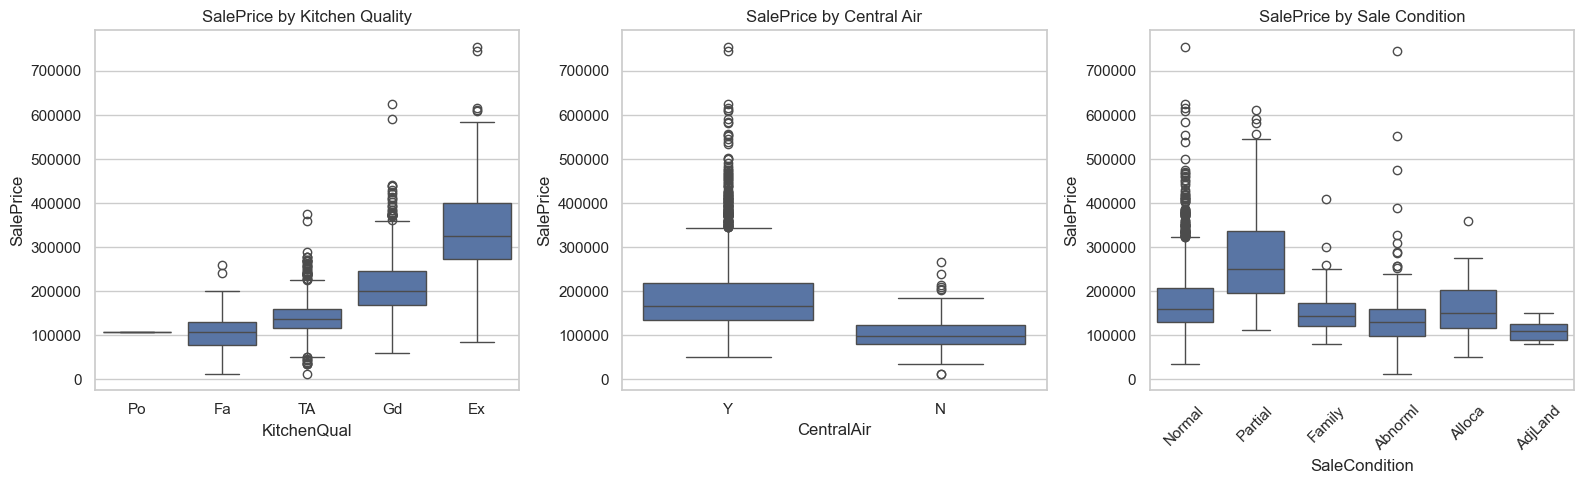

Median SalePrice by KitchenQual:
KitchenQual
Po    107500.0
Fa    107750.0
TA    136500.0
Gd    201000.0
Ex    325624.0

Median SalePrice by CentralAir:
CentralAir
N     98250.0
Y    166250.0

Median SalePrice by SaleCondition:
SaleCondition
Partial    250000.0
Normal     159000.0
Alloca     149617.0
Family     144400.0
Abnorml    129450.0
AdjLand    110000.0


In [122]:
# Compare SalePrice across categories of three unexamined categorical features.
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

kitchen_order = ["Po", "Fa", "TA", "Gd", "Ex"]
sns.boxplot(data=df_raw, x="KitchenQual", y="SalePrice", order=kitchen_order, ax=axes[0])
axes[0].set_title("SalePrice by Kitchen Quality")

sns.boxplot(data=df_raw, x="CentralAir", y="SalePrice", ax=axes[1])
axes[1].set_title("SalePrice by Central Air")

sns.boxplot(data=df_raw, x="SaleCondition", y="SalePrice", ax=axes[2])
axes[2].set_title("SalePrice by Sale Condition")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print("Median SalePrice by KitchenQual:")
print(df_raw.groupby("KitchenQual")["SalePrice"].median().reindex(kitchen_order).to_string())
print("\nMedian SalePrice by CentralAir:")
print(df_raw.groupby("CentralAir")["SalePrice"].median().to_string())
print("\nMedian SalePrice by SaleCondition:")
print(df_raw.groupby("SaleCondition")["SalePrice"].median().sort_values(ascending=False).to_string())

**Finding:** All three show a clear, ordered relationship with price. `KitchenQual` is almost
perfectly monotonic (median price roughly triples from `Po`/`Fa` to `Ex`). Houses with central
air (`CentralAir = Y`) have a median price of about $166,250 versus about $98,250 without it.
`SaleCondition` shows `Partial` sales (typically newly-built homes sold before completion) priced
well above `Normal` sales â€” $250,000 vs. $159,000 median.

**Interpretation:** This confirms the ordinal quality features (`KitchenQual` and similar ratings
like `ExterQual`, `BsmtQual`) genuinely carry real price signal and are worth encoding with their
natural order preserved (ordinal encoding) rather than treated as unordered categories. The
`SaleCondition` gap is a reminder that not every sale in the dataset reflects an "arms-length"
market transaction â€” `Partial` and `Abnorml` sales follow different pricing logic and may be
worth flagging separately in a modeling step.

**Follow-up:** Beyond the physical characteristics of the house itself, does *when* it was built
or sold relate to price?

### 5.12 Price Patterns Over Time â€” Build Year and Sale Month

**Question:** Does SalePrice show a clear trend by the decade a house was built, and is there any
seasonal pattern in when houses are sold?

**Analysis:** Grouped by decade of `YearBuilt` to look at long-term price appreciation, and by
`MoSold` to check whether sale volume or price varies by month.

**Visualization:** Line chart of average price by decade built, and a combined view of sale
volume and average price by month.

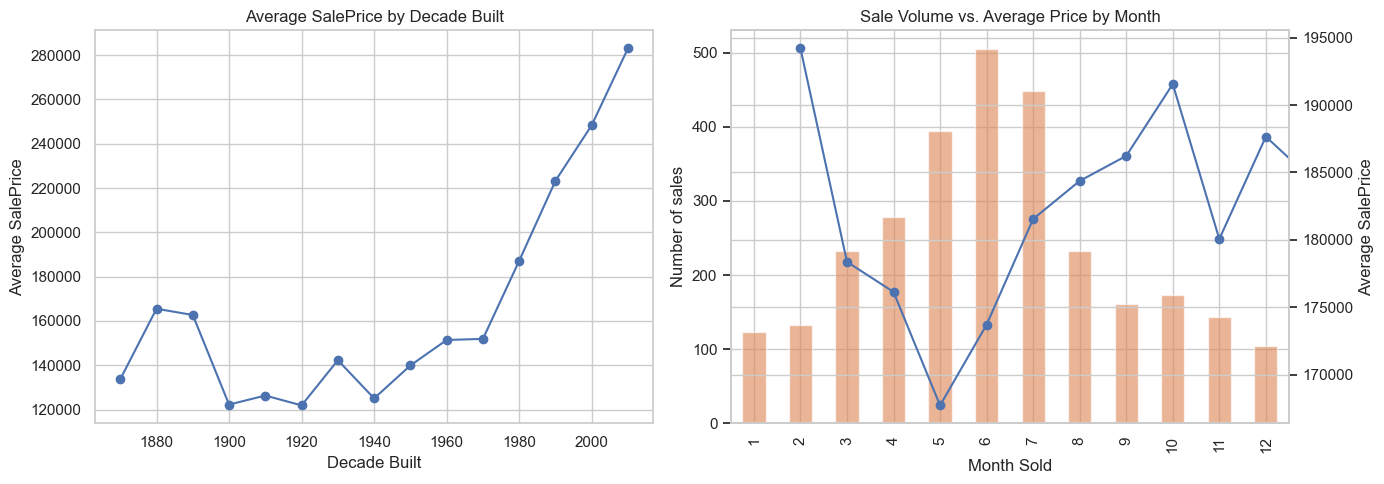

In [123]:
# Price trend by decade built (computed without adding a column to df_raw,
# so df_raw stays identical in shape to df for later integrity checks).
decade_built = (df_raw["YearBuilt"] // 10) * 10
price_by_decade = df_raw["SalePrice"].groupby(decade_built).mean()

# Sale volume and average price by month.
monthly_count = df_raw["MoSold"].value_counts().sort_index()
monthly_price = df_raw.groupby("MoSold")["SalePrice"].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

price_by_decade.plot(marker="o", ax=axes[0], color="#4C72B0")
axes[0].set_title("Average SalePrice by Decade Built")
axes[0].set_xlabel("Decade Built")
axes[0].set_ylabel("Average SalePrice")

ax2 = axes[1].twinx()
monthly_count.plot(kind="bar", ax=axes[1], color="#DD8452", alpha=0.6, label="Number of sales")
monthly_price.plot(marker="o", ax=ax2, color="#4C72B0", label="Average price")
axes[1].set_title("Sale Volume vs. Average Price by Month")
axes[1].set_xlabel("Month Sold")
axes[1].set_ylabel("Number of sales")
ax2.set_ylabel("Average SalePrice")

plt.tight_layout()
plt.show()

**Finding:** Average price rises fairly steadily by decade built, from roughly $120,000â€“140,000
for pre-1950s houses to about $187,000 in the 1980s and $248,000 in the 2000s. Sale *volume* is
strongly seasonal â€” May through July account for a much larger share of sales than winter months
â€” but average *price* stays relatively flat across all months (roughly $167,000â€“$194,000), with
no large seasonal premium or discount.

**Interpretation:** Newer construction commands a real, substantial price premium, so `YearBuilt`
carries genuine signal beyond just correlating with `OverallQual` (newer building codes and
materials likely contribute directly). The seasonality finding is arguably the more surprising
one: even though far more houses sell in summer (consistent with typical US housing-market
patterns â€” families moving between school years), the *price* houses sell for doesn't meaningfully
shift with the season, suggesting `MoSold` mostly reflects buyer demand timing rather than a
pricing effect worth engineering into the model.

**Follow-up:** Stepping back to data-quality â€” do the missing-value patterns already summarized in
Section 3.2 follow a structural logic (e.g., all garage-related columns missing together), or do
they look scattered and unrelated?

### 5.13 Visualizing the Missing-Value Pattern

**Question:** Section 3.2 listed missing counts column by column â€” do those missing values cluster
into recognizable groups (e.g. all garage columns missing for the same rows), which would support
treating them as structurally meaningful rather than random?

**Analysis:** Selected the columns with the highest missing counts and visualized missingness as a
heatmap across rows, to see whether missing cells line up together.

**Visualization:** Heatmap of missing-value locations (dark = missing) for the most incomplete
columns, plus a bar chart of missing percentage per column.

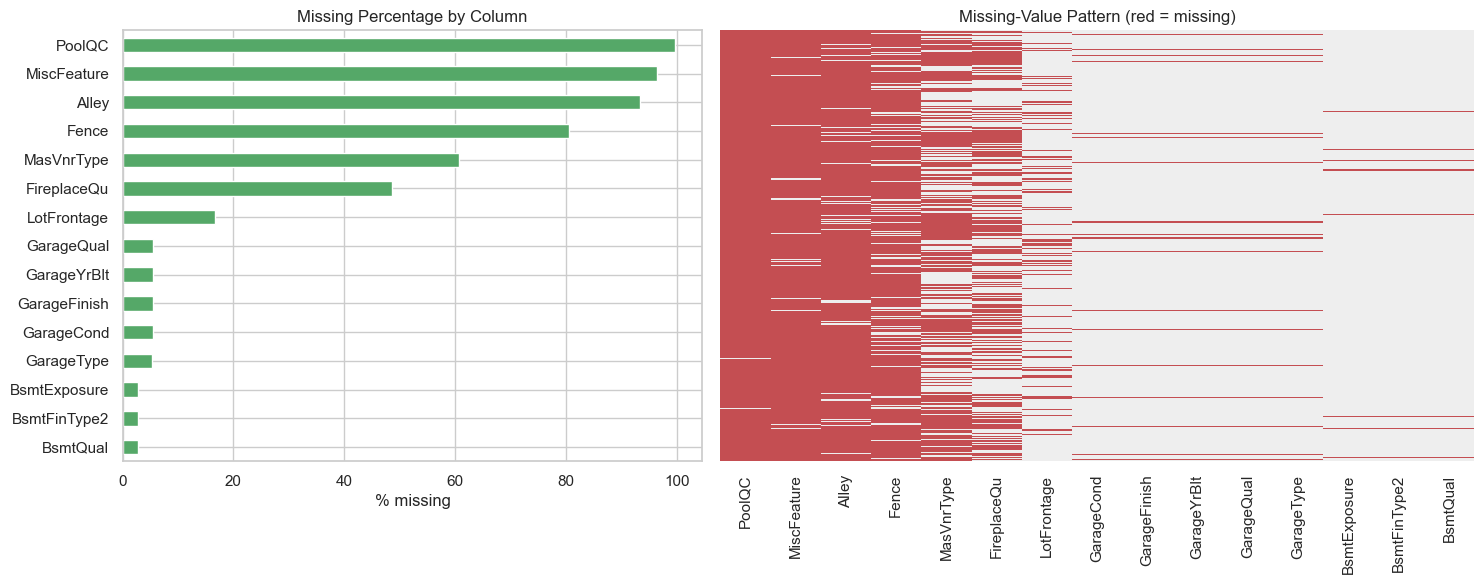

In [124]:
# Visualize where the most-missing columns are missing, and how much.
top_missing_cols = df_raw.isna().sum().sort_values(ascending=False)
top_missing_cols = top_missing_cols[top_missing_cols > 0].head(15)

fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [1, 1.3]})

(top_missing_cols / len(df_raw) * 100).sort_values().plot(kind="barh", ax=axes[0], color="#55A868")
axes[0].set_xlabel("% missing")
axes[0].set_title("Missing Percentage by Column")

sns.heatmap(
    df_raw[top_missing_cols.index].isna(),
    cbar=False,
    cmap=["#EEEEEE", "#C44E52"],
    ax=axes[1]
)
axes[1].set_title("Missing-Value Pattern (red = missing)")
axes[1].set_xlabel("")
axes[1].set_yticks([])

plt.tight_layout()
plt.show()

**Finding:** Missing garage fields often occur together, but their counts are not identical: `GarageType` is missing in 157 rows, `GarageYrBlt` in 160, and `GarageFinish`, `GarageQual`, and `GarageCond` in 159 each. Basement fields also have related but different missing counts. `PoolQC`, `MiscFeature`, `Alley`, and `Fence` are absent in many records (about 80â€“99.6%).

**Interpretation:** Some missing values represent amenities that do not exist; others are incomplete records. The manual missingness plot shows their overlap, while Section 7 checks related fields before labeling absence. A missing garage category alone is not proof that every garage field is inapplicable.

**Follow-up:** Compare these patterns with the automated profiling report, then use the property-level checks below to interpret them.


## 6. Automated EDA with ydata-profiling

In [125]:
# Generate an automated report from the original data before cleaning.
try:
    from ydata_profiling import ProfileReport

    profile = ProfileReport(
        df_raw,
        title="Ames Housing - Automated EDA",
        minimal=True,
        correlations={"pearson": {"calculate": True}},
        progress_bar=False
    )

    profile.to_file("Ames_Housing_Profiling.html")
    print("Automated report saved as: Ames_Housing_Profiling.html")
except ImportError:
    profile = None
    print("ydata-profiling is not installed.")
    print("Install it with: %pip install ydata-profiling")

Automated report saved as: Ames_Housing_Profiling.html


### 6.1 Compare manual and automated EDA

This cell connects the focused manual findings with the broad automated profiling report.


In [126]:
# Compare a few manual results with the automated report.
if profile is not None:
    auto_description = profile.get_description()

    comparison = pd.DataFrame({
        "Check": [
            "Rows",
            "Missing SalePrice",
            "Missing LotFrontage",
            "SalePrice skewness"
        ],
        "Manual": [
            len(df_raw),
            df_raw["SalePrice"].isna().sum(),
            df_raw["LotFrontage"].isna().sum(),
            round(df_raw["SalePrice"].skew(), 3)
        ],
        "Automated": [
            int(auto_description.table["n"]),
            int(auto_description.variables["SalePrice"]["n_missing"]),
            int(auto_description.variables["LotFrontage"]["n_missing"]),
            round(float(auto_description.variables["SalePrice"]["skewness"]), 3)
        ]
    })

    print(comparison.to_string(index=False))
else:
    print("Automated comparison is unavailable because ydata-profiling is not installed.")

              Check   Manual  Automated
               Rows 2930.000   2930.000
  Missing SalePrice    0.000      0.000
Missing LotFrontage  490.000    490.000
 SalePrice skewness    1.744      1.744


**Manual versus automated findings (raw data):**

| Topic | Manual EDA | Automated profiling | Combined reading |
|---|---|---|---|
| Dataset and target | 2,930 houses; no missing `SalePrice`; skewness â‰ˆ 1.744. | 2,930 observations, 82 variables; the comparison cell confirms the same target missingness and skewness. | Price is right-skewed; report prices and model errors in the appropriate scale. |
| Missing land and amenities | 490 `LotFrontage` and 2,917 `PoolQC` values are missing; the missingness plot shows clusters. | Alerts list `LotFrontage`: 490 (16.7%) and `PoolQC`: 2,917 (99.6%). | A missing amenity may mean absence, but related area/count columns must confirm it. |
| Skewed features | The numerical skewness ranking puts `MiscVal` around 22, far above `SalePrice`. | The profile flags `MiscVal` as highly skewed (â‰ˆ 22). | Sparse, extreme features require care when interpreting distributions. |
| Correlations and outliers | Correlation plots show `OverallQual` (â‰ˆ 0.80) and `GrLivArea` (â‰ˆ 0.71) associated with price; manual plots identify five homes above 4,000 sq ft. | The profile presents Pearson correlations and flags a strong `Order`â€“`YrSold` correlation. | The identifier/time alert does not make `Order` a meaningful predictor; the unusual large homes need their neighborhood and sale context. |

The manual work explains individual patterns; profiling checks every column consistently. The separate raw-data report is available here: [Ames_Housing_Profiling.html](Ames_Housing_Profiling.html).


## 6.5 Split before any learned cleaning

Sections 5 and 6 only *look at* the raw data (`df_raw`); they do not learn any statistic that
feeds back into the model, so no split was needed for them.

Section 7, however, *learns* things from the data: group medians, group modes, "most similar
property" matches. If those statistics are learned from the full dataset, information from the
validation and test properties leaks into values used to prepare the model, even though
`SalePrice` itself is never touched. To prevent that, the train/validation/test split happens
**now**, before any such learned cleaning:

- Same random seed and 70% / 15% / 15% proportions used for the rest of the notebook.
- `reference_df` freezes the training rows *before* Section 7 changes anything, and is the
  **only** source of donor/reference values used by every rule in Section 7.
- `train_mask` flags which rows of `df` belong to the training set. Section 7 only *writes*
  values into rows where `train_mask` is `True` â€” validation and test rows are left exactly as
  they arrived, missing values included. This closes leakage from both directions: no
  validation/test row can act as a donor, and no validation/test row has a value filled in using
  a statistic learned from the training set.
- No matching rule uses `SalePrice`.
- Validation/test missingness is resolved later, by the `SimpleImputer` steps inside the
  Section 14 pipelines, which are fit on `X_train` only (Section 16). That keeps a single,
  consistent no-leakage boundary instead of splitting the imputation logic across two different
  mechanisms trained on two different slices of the data.
- Section 15 reuses these exact `train_index` / `val_index` / `test_index` rather than splitting
  again, so the model split and the cleaning split are always the same partition.


In [127]:
# Freeze the split before any learned/statistical cleaning happens.
from sklearn.model_selection import train_test_split

train_val_index, test_index = train_test_split(
    df.index, test_size=0.15, random_state=42
)

train_index, val_index = train_test_split(
    train_val_index, test_size=0.15 / 0.85, random_state=42
)

# Pristine snapshot taken before Section 7 changes anything, and the
# training-only slice of it that every donor search below will use.
df_before_imputation = df.copy(deep=True)
reference_df = df_before_imputation.loc[train_index].copy(deep=True)

# Every write in Section 7 is gated by this mask: only training rows get
# logically cleaned. Validation/test rows keep their original missing values
# and are imputed later by the Section 16 pipelines (fit on X_train only).
train_mask = df.index.isin(train_index)

print("Train:", len(train_index))
print("Validation:", len(val_index))
print("Test:", len(test_index))
print("Reference (donor) rows available:", len(reference_df))


Train: 2050
Validation: 440
Test: 440
Reference (donor) rows available: 2050


## 7. Logical missing-value handling

The following cells work on `df`, but every assignment is restricted to training rows only,
using the `train_mask` frozen in Section 6.5. `NA` is a text category for an absent feature.
`Unknown` is a temporary label for an unresolved category; it is replaced using the documented
rules in that feature's section. Actual NaN values are reported separately at the end.

Validation and test rows are **not** touched in this section, on purpose: every rule here learns
a group median, a group mode, or a "most similar property" match, and applying that estimate to
a validation/test row would mean the model preparation step used a statistic derived from the
training set to alter data the model is later evaluated on. Their missing values stay as NaN (or
as the raw category) and are resolved later by the Section 16 `ColumnTransformer`, whose
imputers are fit on the training set only â€” so validation/test rows still end up fully cleaned,
just through the same single no-leakage boundary as the rest of the preprocessing.

**Reference/donor values come only from `reference_df` (training rows), frozen in Section 6.5
above** â€” not from `df` or `df_raw`. This is the leakage fix: an estimate for a training
property is never allowed to borrow information from a validation or test property, and no
imputed value is ever promoted into a reference for a later estimate.


### 7.0 Rules for replacing temporary Unknown labels

Each categorical estimate is completed inside its feature section. We use an
existing category from properties with an originally observed value.
`reference_df` supplies training-only reference rows, so an estimate never
becomes a reference for another estimate, and a validation/test property is
never used as a donor, and â€” per Section 6.5 â€” a validation/test property is never the
target of an estimate either. `SalePrice`, `Order`, and `PID` are not matching
features. `PID` identifies the property in the audit table only.

Start with the most specific group and relax the stated criteria only if it
has fewer than three references or a tied mode. A mode is the most frequent
category. The minimum of three is a practical support rule, not a guarantee
that an estimate is correct. The last group uses all eligible references.

`ModeShare` is the fraction of reference rows with the selected category;
it is not a probability that the replacement is correct. `NA` continues to
mean an absent feature, using the convention in this notebook. For veneer,
this is the existing absence label corresponding to `None` in the data dictionary.
Similar properties are not confirmed next-door neighbors or homes from the
same builder: this dataset does not provide a builder ID or exact coordinates.

In [128]:
# Keep an audit table separate from the housing features.
category_imputation_log = []

def choose_existing_category(house, reference, feature, match_groups):
    # Try the matching rules in order, using observed categories only.
    for columns in match_groups:
        matches = reference
        for column in columns:
            matches = matches.loc[matches[column].eq(house[column])]

        modes = matches[feature].mode()
        if len(matches) >= 3 and len(modes) == 1:
            value = modes.iloc[0]
            return {
                "PID": int(house["PID"]),
                "Feature": feature,
                "Before": "Unknown",
                "After": value,
                "Method": "Observed group mode",
                "MatchedOn": " + ".join(columns) or "All eligible references",
                "ReferenceCount": len(matches),
                "ModeShare": round(matches[feature].eq(value).mean(), 3),
                "ReferencePIDs": matches["PID"].astype(int).tolist(),
                "ReferenceValues": matches[feature].value_counts().to_dict(),
                "Note": "Estimated category; not a verified property record"
            }

    raise ValueError(f"No supported mode for {feature}, PID {house['PID']}")

### 7.1 PoolQC - pool quality

In [129]:
# PoolQC describes pool quality. Missing means that the property has no pool.
# Only training rows are written here (see Section 6.5 / 7).
pool_missing_train = df["PoolQC"].isna() & train_mask
print("PoolQC missing before (train):", pool_missing_train.sum())

df.loc[pool_missing_train, "PoolQC"] = "NA"

print("PoolQC missing after (train):", (df["PoolQC"].isna() & train_mask).sum())
print(df.loc[train_mask, "PoolQC"].value_counts().to_string())


PoolQC missing before (train): 2042
PoolQC missing after (train): 0
PoolQC
NA    2042
Gd       3
TA       3
Ex       2


### 7.2 MiscFeature - additional feature

In [130]:
# MiscFeature describes an additional feature such as a shed.
# Missing means that the property has no recorded additional feature.
# Only training rows are written here (see Section 6.5 / 7).
misc_missing_train = df["MiscFeature"].isna() & train_mask
print("MiscFeature missing before (train):", misc_missing_train.sum())

df.loc[misc_missing_train, "MiscFeature"] = "NA"

print("MiscFeature missing after (train):", (df["MiscFeature"].isna() & train_mask).sum())
print(df.loc[train_mask, "MiscFeature"].value_counts().to_string())


MiscFeature missing before (train): 1971
MiscFeature missing after (train): 0
MiscFeature
NA      1971
Shed      69
Gar2       5
Othr       4
Elev       1


### 7.3 Alley - alley access

In [131]:
# Alley describes access from an alley. Missing means no alley access.
# Only training rows are written here (see Section 6.5 / 7).
alley_missing_train = df["Alley"].isna() & train_mask
print("Alley missing before (train):", alley_missing_train.sum())

df.loc[alley_missing_train, "Alley"] = "NA"

print("Alley missing after (train):", (df["Alley"].isna() & train_mask).sum())
print(df.loc[train_mask, "Alley"].value_counts().to_string())


Alley missing before (train): 1916
Alley missing after (train): 0
Alley
NA      1916
Grvl      83
Pave      51


### 7.4 Fence - fence quality

In [132]:
# Fence describes fence quality. Missing means that the property has no fence.
# Only training rows are written here (see Section 6.5 / 7).
fence_missing_train = df["Fence"].isna() & train_mask
print("Fence missing before (train):", fence_missing_train.sum())

df.loc[fence_missing_train, "Fence"] = "NA"

print("Fence missing after (train):", (df["Fence"].isna() & train_mask).sum())
print(df.loc[train_mask, "Fence"].value_counts().to_string())


Fence missing before (train): 1649
Fence missing after (train): 0
Fence
NA       1649
MnPrv     236
GdPrv      78
GdWo       78
MnWw        9


### 7.5 MasVnrType and MasVnrArea - masonry veneer

In [133]:
# MasVnrType describes the veneer material and MasVnrArea describes its area.
# Only training rows are written here (see Section 6.5 / 7).
missing_type_train = df["MasVnrType"].isna() & train_mask

print("Missing MasVnrType (train):", missing_type_train.sum())
print("Missing type with zero area (train):", (missing_type_train & df["MasVnrArea"].eq(0)).sum())
print("Missing type with positive area (train):", (missing_type_train & df["MasVnrArea"].gt(0)).sum())
print("Both type and area missing (train):", (missing_type_train & df["MasVnrArea"].isna()).sum())

# A zero recorded area supports the absence of veneer.
no_veneer = missing_type_train & df["MasVnrArea"].eq(0)
df.loc[no_veneer, "MasVnrType"] = "NA"

# Temporarily label unresolved types (training rows only); estimate them after the area review.
still_missing_type_train = df["MasVnrType"].isna() & train_mask
df.loc[still_missing_type_train, "MasVnrType"] = "Unknown"

print("Missing MasVnrType after (train):", (df["MasVnrType"].isna() & train_mask).sum())
print(df.loc[train_mask, "MasVnrType"].value_counts().to_string())


Missing MasVnrType (train): 1248
Missing type with zero area (train): 1226
Missing type with positive area (train): 7
Both type and area missing (train): 15
Missing MasVnrType after (train): 0
MasVnrType
NA         1226
BrkFace     622
Stone       162
Unknown      22
BrkCmn       17
CBlock        1


### 7.5.1 Review unresolved veneer rows

This cell prints properties where the veneer material is unknown but a positive veneer area is recorded.


In [134]:
# Review positive veneer areas whose material type is unresolved.
positive_area_unknown = (
    df["MasVnrType"].eq("Unknown")
    & df["MasVnrArea"].gt(0)
)

print(
    df.loc[
        positive_area_unknown,
        ["PID", "MasVnrType", "MasVnrArea", "Neighborhood", "Exterior1st", "Exterior2nd"]
    ].to_string(index=False)
)

# Next, estimate the 23 missing areas; then estimate all 30 unknown types.
print("Missing MasVnrArea before similar-property estimates:", df["MasVnrArea"].isna().sum())

      PID MasVnrType  MasVnrArea Neighborhood Exterior1st Exterior2nd
527166010    Unknown       344.0      Gilbert     VinylSd     VinylSd
527451110    Unknown       312.0       BrDale     HdBoard     HdBoard
528138010    Unknown       285.0      NridgHt     VinylSd     VinylSd
533352075    Unknown         1.0       Sawyer     Plywood     Plywood
535106140    Unknown         1.0        NAmes     Wd Sdng     Wd Sdng
902427140    Unknown         1.0      OldTown     MetalSd     MetalSd
534129230    Unknown       288.0       NWAmes     VinylSd     VinylSd
Missing MasVnrArea before similar-property estimates: 23


### 7.5.2 Find similar veneer properties

This cell uses the same neighborhood, exterior materials, and overall quality as reference information. SalePrice is not used.

In [135]:
# Use the original data to identify rows where both veneer fields are missing.
unresolved_veneer = (
    df_before_imputation["MasVnrType"].isna()
    & df_before_imputation["MasVnrArea"].isna()
    & df_before_imputation.index.isin(train_index)
)

# Use rows with a known veneer area as reference properties.
veneer_reference = reference_df.loc[
    reference_df["MasVnrArea"].notna()
].copy()

veneer_estimates = []

for _, house in df_before_imputation.loc[unresolved_veneer].iterrows():
    strict_matches = veneer_reference.loc[
        (veneer_reference["Neighborhood"] == house["Neighborhood"])
        & (veneer_reference["Exterior1st"] == house["Exterior1st"])
        & (veneer_reference["Exterior2nd"] == house["Exterior2nd"])
        & (veneer_reference["OverallQual"] == house["OverallQual"])
    ]

    if len(strict_matches) >= 3:
        matches = strict_matches
        method = "Neighborhood + exterior + quality median"
    else:
        broad_matches = veneer_reference.loc[
            (veneer_reference["Neighborhood"] == house["Neighborhood"])
            & (veneer_reference["Exterior1st"] == house["Exterior1st"])
            & (veneer_reference["Exterior2nd"] == house["Exterior2nd"])
        ]

        if len(broad_matches) >= 3:
            matches = broad_matches
            method = "Neighborhood + exterior median"
        else:
            matches = veneer_reference.loc[
                veneer_reference["Neighborhood"] == house["Neighborhood"]
            ]
            method = "Neighborhood median fallback"

    veneer_estimates.append({
        "PID": house["PID"],
        "SimilarRows": len(matches),
        "EstimatedArea": matches["MasVnrArea"].median(),
        "Method": method
    })

veneer_estimates = pd.DataFrame(veneer_estimates)
print(veneer_estimates.to_string(index=False))

      PID  SimilarRows  EstimatedArea                                   Method
528240070           38            0.0 Neighborhood + exterior + quality median
528275160           84            0.0           Neighborhood + exterior median
531371050           19            0.0 Neighborhood + exterior + quality median
907260030           83           50.0 Neighborhood + exterior + quality median
528290090           42            0.0 Neighborhood + exterior + quality median
528462040            4          152.5 Neighborhood + exterior + quality median
528480160            4          152.5 Neighborhood + exterior + quality median
534104100           22            0.0 Neighborhood + exterior + quality median
528218010           38            0.0 Neighborhood + exterior + quality median
528250010           42            0.0 Neighborhood + exterior + quality median
528458150          108           33.0             Neighborhood median fallback
909475070           76            0.0             Ne

### 7.5.3 Apply the veneer-area estimates

Estimate the 15 missing areas in training rows supported by reference properties. Eight other missing areas remain in validation/test and are handled later by the fitted preprocessing imputer.


In [136]:
# Apply the estimates to the matching PID only.
for _, estimate in veneer_estimates.iterrows():
    property_mask = df["PID"] == estimate["PID"]
    df.loc[property_mask, "MasVnrArea"] = estimate["EstimatedArea"]

print("MasVnrArea missing after estimates:", df["MasVnrArea"].isna().sum())
print("Estimation methods used:")
print(veneer_estimates["Method"].value_counts().to_string())

MasVnrArea missing after estimates: 8
Estimation methods used:
Method
Neighborhood + exterior + quality median    12
Neighborhood median fallback                 2
Neighborhood + exterior median               1


### 7.5.4 Replace the remaining Unknown veneer types

The earlier cells estimated 15 training-row areas; eight validation/test areas remain missing. This section handles the 22 temporary `Unknown` veneer types in training rows:

- If the estimated area is zero, assign the existing absence label `NA`. This is a supported estimate, not a confirmed original material.
- If the area is positive, choose a material from reference properties with positive recorded veneer area and an originally recorded material. Unresolved types do not act as material references.

The matching order is neighborhood + both exterior materials + quality; then neighborhood + both exterior materials; then neighborhood + building type; then neighborhood; then exterior materials; then all eligible reference properties. Exterior siding helps find similar properties but does not directly identify the veneer material. The three observed areas of 1 square foot remain unchanged.


In [137]:
# Snapshot the temporary labels before changing any veneer type.
unknown_veneer_types = df["MasVnrType"].eq("Unknown")
print("Unknown MasVnrType before:", unknown_veneer_types.sum())

# Never use estimated types or estimated areas as reference data.
material_categories = ["BrkFace", "Stone", "BrkCmn", "CBlock"]
veneer_type_reference = reference_df.loc[
    reference_df["MasVnrArea"].gt(0)
    & reference_df["MasVnrType"].isin(material_categories)
].copy()

veneer_type_groups = [
    ["Neighborhood", "Exterior1st", "Exterior2nd", "OverallQual"],
    ["Neighborhood", "Exterior1st", "Exterior2nd"],
    ["Neighborhood", "BldgType"],
    ["Neighborhood"],
    ["Exterior1st", "Exterior2nd"],
    []  # Last fallback: all properties with recorded positive veneer area.
]

for index in df.index[unknown_veneer_types]:
    house = df.loc[index]

    if house["MasVnrArea"] == 0:
        estimate = {
            "PID": int(house["PID"]),
            "Feature": "MasVnrType",
            "Before": "Unknown",
            "After": "NA",
            "Method": "Assumed absence from estimated zero area",
            "MatchedOn": "MasVnrArea estimate = 0",
            "ReferenceCount": 0,
            "ModeShare": np.nan,
            "ReferencePIDs": [],
            "ReferenceValues": {},
            "Note": "Absence assumed from the previous area estimate; not observed"
        }
    else:
        estimate = choose_existing_category(
            house, veneer_type_reference, "MasVnrType", veneer_type_groups
        )

    df.loc[index, "MasVnrType"] = estimate["After"]
    category_imputation_log.append(estimate)

print("Unknown MasVnrType after:", df["MasVnrType"].eq("Unknown").sum())
print(df["MasVnrType"].value_counts().to_string())

Unknown MasVnrType before: 22
Unknown MasVnrType after: 0
MasVnrType
NA         1234
BrkFace     888
Stone       255
BrkCmn       25
CBlock        1


### 7.5.5 Review each veneer replacement

This table shows the selected category, the matching rule, and the support
for every affected PID. For the zero-area rule there is no category mode;
its area-estimation evidence is already shown in `veneer_estimates` above.

In [138]:
veneer_type_audit = pd.DataFrame(category_imputation_log)
print(veneer_type_audit[[
    "PID", "Before", "After", "MatchedOn", "ReferenceCount", "ModeShare"
]].to_string(index=False))

# Check consistency only for the types replaced in this section.
changed_veneer = df.loc[unknown_veneer_types]
assert not changed_veneer["MasVnrType"].eq("Unknown").any()
assert changed_veneer.loc[
    changed_veneer["MasVnrArea"].gt(0), "MasVnrType"
].isin(material_categories).all()
assert changed_veneer.loc[
    changed_veneer["MasVnrArea"].eq(0), "MasVnrType"
].eq("NA").all()

      PID  Before   After                                              MatchedOn  ReferenceCount  ModeShare
528240070 Unknown      NA                                MasVnrArea estimate = 0               0        NaN
527166010 Unknown BrkFace Neighborhood + Exterior1st + Exterior2nd + OverallQual              10      0.800
527451110 Unknown BrkFace Neighborhood + Exterior1st + Exterior2nd + OverallQual               5      1.000
528138010 Unknown   Stone Neighborhood + Exterior1st + Exterior2nd + OverallQual              22      0.591
528275160 Unknown      NA                                MasVnrArea estimate = 0               0        NaN
531371050 Unknown      NA                                MasVnrArea estimate = 0               0        NaN
907260030 Unknown BrkFace Neighborhood + Exterior1st + Exterior2nd + OverallQual              43      0.837
528290090 Unknown      NA                                MasVnrArea estimate = 0               0        NaN
528462040 Unknown   Stone Ne

### 7.6 FireplaceQu - fireplace quality

In [139]:
# FireplaceQu describes fireplace quality. Fireplaces gives the fireplace count.
# Only training rows are written here (see Section 6.5 / 7).
missing_quality = df["FireplaceQu"].isna() & train_mask
no_fireplace = missing_quality & df["Fireplaces"].eq(0)
fireplace_quality_unknown = missing_quality & df["Fireplaces"].gt(0)

print("Missing FireplaceQu (train):", missing_quality.sum())
print("Missing quality with no fireplace (train):", no_fireplace.sum())
print("Missing quality with a fireplace (train):", fireplace_quality_unknown.sum())

df.loc[no_fireplace, "FireplaceQu"] = "NA"
df.loc[fireplace_quality_unknown, "FireplaceQu"] = "Unknown"

print("Missing FireplaceQu after (train):", (df["FireplaceQu"].isna() & train_mask).sum())
print(df.loc[train_mask, "FireplaceQu"].value_counts().to_string())


Missing FireplaceQu (train): 982
Missing quality with no fireplace (train): 982
Missing quality with a fireplace (train): 0
Missing FireplaceQu after (train): 0
FireplaceQu
NA    982
Gd    509
TA    436
Fa     56
Po     35
Ex     32


### 7.7 LotFrontage - frontage length

### 7.7.1 Prepare frontage reference rows

This cell keeps the observed LotFrontage values that will be used as logical references.


In [140]:
# LotFrontage is the length of the lot boundary facing the street.
# LotArea alone cannot determine the exact frontage.
df_before_frontage = df.copy()

print("LotFrontage missing before:", df["LotFrontage"].isna().sum())

frontage_reference = reference_df.loc[
    reference_df["LotFrontage"].notna()
].copy()

frontage_columns = [
    "PID", "Neighborhood", "LotArea", "LotShape", "LotConfig", "LotFrontage"
]

LotFrontage missing before: 490


### 7.7.2 Find exact frontage matches

This cell searches for properties with the same neighborhood, lot area, lot shape, and lot configuration.


In [141]:
# First identify missing frontage values with strong exact-match evidence.
missing_frontage_rows = df_before_frontage.loc[
    df_before_frontage["LotFrontage"].isna() & train_mask
].copy()

candidate_rows = []

for _, house in missing_frontage_rows.iterrows():
    matches = frontage_reference.loc[
        (frontage_reference["Neighborhood"] == house["Neighborhood"])
        & (frontage_reference["LotArea"] == house["LotArea"])
        & (frontage_reference["LotShape"] == house["LotShape"])
        & (frontage_reference["LotConfig"] == house["LotConfig"])
    ]

    if len(matches) >= 3 and matches["LotFrontage"].nunique() == 1:
        candidate_rows.append({
            "PID": house["PID"],
            "MatchingRows": len(matches),
            "EstimatedLotFrontage": matches["LotFrontage"].iloc[0]
        })

candidate_table = pd.DataFrame(candidate_rows)
print(candidate_table.to_string(index=False))

      PID  MatchingRows  EstimatedLotFrontage
527368020             3                  62.0
527366030             3                  62.0
923203190             4                  32.0
534104100             3                  62.0
903232030             8                  51.0
923225150             3                  41.0
903231190            10                  52.0


### 7.7.3 Apply exact frontage estimates

This cell fills only the missing frontage values supported by at least three identical reference properties.


In [142]:
# Apply only exact-match estimates supported by at least three properties.
for _, row in candidate_table.iterrows():
    property_mask = df["PID"] == row["PID"]
    df.loc[property_mask, "LotFrontage"] = row["EstimatedLotFrontage"]
    print("PID:", row["PID"], "| Estimated frontage:", row["EstimatedLotFrontage"])

print("Missing after exact matches:", df["LotFrontage"].isna().sum())

PID: 527368020.0 | Estimated frontage: 62.0
PID: 527366030.0 | Estimated frontage: 62.0
PID: 923203190.0 | Estimated frontage: 32.0
PID: 534104100.0 | Estimated frontage: 62.0
PID: 903232030.0 | Estimated frontage: 51.0
PID: 923225150.0 | Estimated frontage: 41.0
PID: 903231190.0 | Estimated frontage: 52.0
Missing after exact matches: 483


### 7.7.4 Estimate the remaining frontage values

This cell uses a similar-group median, then a neighborhood median, and finally a global median when needed.


In [143]:
# Estimate remaining frontage values with a hierarchical group median.
group_columns = ["Neighborhood", "LotShape", "LotConfig"]

group_stats = frontage_reference.groupby(group_columns)["LotFrontage"].agg(
    ["median", "count"]
)
neighborhood_stats = frontage_reference.groupby("Neighborhood")["LotFrontage"].agg(
    ["median", "count"]
)
global_frontage_median = frontage_reference["LotFrontage"].median()

fill_method_counts = {
    "Similar group median": 0,
    "Neighborhood median": 0,
    "Global median": 0
}

remaining_missing_frontage = df["LotFrontage"].isna() & train_mask
for index in df.index[remaining_missing_frontage]:
    house = df.loc[index]
    group_key = (
        house["Neighborhood"],
        house["LotShape"],
        house["LotConfig"]
    )

    if group_key in group_stats.index and group_stats.loc[group_key, "count"] >= 3:
        estimate = group_stats.loc[group_key, "median"]
        fill_method_counts["Similar group median"] += 1
    elif (
        house["Neighborhood"] in neighborhood_stats.index
        and neighborhood_stats.loc[house["Neighborhood"], "count"] >= 3
    ):
        estimate = neighborhood_stats.loc[house["Neighborhood"], "median"]
        fill_method_counts["Neighborhood median"] += 1
    else:
        estimate = global_frontage_median
        fill_method_counts["Global median"] += 1

    df.loc[index, "LotFrontage"] = estimate

print("LotFrontage fill methods:", fill_method_counts)
print("LotFrontage missing after all estimates (train):", (df["LotFrontage"].isna() & train_mask).sum())

LotFrontage fill methods: {'Similar group median': 269, 'Neighborhood median': 90, 'Global median': 2}
LotFrontage missing after all estimates (train): 0


### 7.8 Garage features

In [144]:
# GarageType, GarageFinish, GarageQual, and GarageCond are categorical.
# GarageCars and GarageArea are numeric. GarageYrBlt is a year.
garage_columns = [
    "PID", "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "GarageYrBlt", "GarageCars", "GarageArea"
]

garage_area = df["GarageArea"].fillna(0)
garage_cars = df["GarageCars"].fillna(0)

# A missing garage type with zero area and zero cars indicates no garage.
no_garage = (
    df["GarageType"].isna()
    & garage_area.eq(0)
    & garage_cars.eq(0)
    & train_mask
)

print("Rows with no garage:", no_garage.sum())
print("Missing GarageType with garage evidence:", (df["GarageType"].isna() & ~no_garage).sum())

Rows with no garage: 109
Missing GarageType with garage evidence: 48


### 7.8.1 Label properties with no garage

This cell labels missing categorical garage fields as NA when zero garage area and zero garage cars confirm that no garage exists.

In [145]:
# Missing categorical garage values mean that no garage exists.
garage_categorical_columns = [
    "GarageType", "GarageFinish", "GarageQual", "GarageCond"
]

df.loc[no_garage, garage_categorical_columns] = (
    df.loc[no_garage, garage_categorical_columns].fillna("NA")
)

# GarageYrBlt remains missing for properties without a garage.
print(df[garage_columns].isna().sum().sort_values(ascending=False).to_string())

GarageYrBlt     159
GarageFinish     50
GarageQual       50
GarageCond       50
GarageType       48
GarageCars        1
GarageArea        1
PID               0


### 7.8.2 Find garages with incomplete details

This cell identifies real garages that have missing descriptive or numeric details.


In [146]:
# Identify real garages with incomplete details after labeling absent garages as NA.
garage_area = df["GarageArea"].fillna(0)
garage_cars = df["GarageCars"].fillna(0)

has_garage = (
    (
        df["GarageType"].notna()
        & df["GarageType"].ne("NA")
    )
    | garage_area.gt(0)
    | garage_cars.gt(0)
)

garage_detail_columns = ["GarageFinish", "GarageQual", "GarageCond", "GarageYrBlt"]
incomplete_garage = has_garage & df[garage_detail_columns].isna().any(axis=1) & train_mask

print(df.loc[incomplete_garage, garage_columns].to_string(index=False))

      PID GarageType GarageFinish GarageQual GarageCond  GarageYrBlt  GarageCars  GarageArea
903426160     Detchd          NaN        NaN        NaN          NaN         1.0       360.0
910201180     Detchd          NaN        NaN        NaN          NaN         NaN         NaN


### 7.8.3 Estimate the two incomplete detached garages

This cell uses similar detached garages in the same neighborhood to fill only the missing details for the two identified properties.


In [147]:
# Estimate the incomplete detached garages (identified above, training rows only)
# from the same neighborhood and garage type.
incomplete_garage_pids = df.loc[incomplete_garage, "PID"].astype(int).tolist()

for property_pid in incomplete_garage_pids:
    property_mask = df["PID"] == property_pid
    property_row = df.loc[property_mask].iloc[0]

    similar_garages = reference_df.loc[
        (reference_df["Neighborhood"] == property_row["Neighborhood"])
        & (reference_df["GarageType"] == property_row["GarageType"])
        & (reference_df["GarageFinish"].notna())
        & (reference_df["GarageFinish"].ne("NA"))
    ]

    for column in ["GarageFinish", "GarageQual", "GarageCond"]:
        if pd.isna(property_row[column]):
            df.loc[property_mask, column] = similar_garages[column].mode().iloc[0]

    if pd.isna(property_row["GarageYrBlt"]):
        valid_years = similar_garages["GarageYrBlt"].between(1900, 2026)
        df.loc[property_mask, "GarageYrBlt"] = round(
            similar_garages.loc[valid_years, "GarageYrBlt"].median()
        )

    if pd.isna(property_row["GarageCars"]):
        df.loc[property_mask, "GarageCars"] = round(
            similar_garages["GarageCars"].median()
        )

    if pd.isna(property_row["GarageArea"]):
        df.loc[property_mask, "GarageArea"] = round(
            similar_garages["GarageArea"].median()
        )

    print("Updated garage details for PID:", property_pid)

print(
    df.loc[
        df["PID"].isin(incomplete_garage_pids),
        garage_columns
    ].to_string(index=False)
)

Updated garage details for PID: 903426160
Updated garage details for PID: 910201180
      PID GarageType GarageFinish GarageQual GarageCond  GarageYrBlt  GarageCars  GarageArea
903426160     Detchd          Unf         TA         TA       1950.0         1.0       360.0
910201180     Detchd          Unf         TA         TA       1950.0         1.0       304.0


### 7.9 Basement features

### 7.9.1 Classify basement status

This cell separates confirmed no-basement rows, confirmed basement rows, and rows whose basement status is unknown.


In [148]:
# Basement missing values must be separated into absence and unknown information.
basement_categorical_columns = [
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2"
]
basement_numeric_columns = [
    "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF",
    "BsmtFullBath", "BsmtHalfBath"
]

known_no_basement = df["TotalBsmtSF"].eq(0)
unknown_basement = df["TotalBsmtSF"].isna()
known_basement = df["TotalBsmtSF"].gt(0)

print("Rows with known no basement:", known_no_basement.sum())
print("Rows with known basement:", known_basement.sum())
print("Rows with unknown basement status:", unknown_basement.sum())

Rows with known no basement: 79
Rows with known basement: 2850
Rows with unknown basement status: 1


### 7.9.2 Label basement absence and identify incomplete categories

Label absent basement categories as `NA` and temporarily mark missing
categories in confirmed basements as `Unknown`. Estimate these categories
in the following cells. Keep the single row with entirely missing
basement information separate.

In [149]:
# Fill basement categories with NA when TotalBsmtSF confirms no basement.
# Only training rows are written here (see Section 6.5 / 7).
known_no_basement_train = known_no_basement & train_mask
known_basement_train = known_basement & train_mask

df.loc[known_no_basement_train, basement_categorical_columns] = (
    df.loc[known_no_basement_train, basement_categorical_columns].fillna("NA")
)

# Temporarily label missing categories in a known (training) basement for the next cells.
for column in basement_categorical_columns:
    unresolved_known_basement = known_basement_train & df[column].isna()
    df.loc[unresolved_known_basement, column] = "Unknown"

# Missing basement bath counts are zero when the property is known to have no basement.
for column in ["BsmtFullBath", "BsmtHalfBath"]:
    df.loc[known_no_basement_train & df[column].isna(), column] = 0

print("Remaining basement missing values (whole df, train+val+test):")
print(df[basement_categorical_columns + basement_numeric_columns].isna().sum().to_string())

print("\nRows with unknown basement status (train only):")
print(
    df.loc[
        unknown_basement & train_mask,
        ["PID"] + basement_numeric_columns + basement_categorical_columns
    ].to_string(index=False)
)


Remaining basement missing values (whole df, train+val+test):
BsmtQual        23
BsmtCond        23
BsmtExposure    25
BsmtFinType1    23
BsmtFinType2    23
BsmtFinSF1       1
BsmtFinSF2       1
BsmtUnfSF        1
TotalBsmtSF      1
BsmtFullBath     2
BsmtHalfBath     2

Rows with unknown basement status (train only):
Empty DataFrame
Columns: [PID, BsmtFinSF1, BsmtFinSF2, BsmtUnfSF, TotalBsmtSF, BsmtFullBath, BsmtHalfBath, BsmtQual, BsmtCond, BsmtExposure, BsmtFinType1, BsmtFinType2]
Index: []


### 7.9.3 Estimate Unknown basement exposure

One training property has positive `TotalBsmtSF` and an unknown exposure category. Reference properties must also have a basement and an observed exposure; `No` means no exposure, while `NA` means no basement.

Match neighborhood, land slope, land contour, house style, and foundation. If support is insufficient, relax the matching fields as shown in the code. These similarities help estimate exposure; they cannot verify its true value.


In [150]:
unknown_exposure = df["BsmtExposure"].eq("Unknown")
print("Unknown BsmtExposure before:", unknown_exposure.sum())

exposure_reference = reference_df.loc[
    reference_df["TotalBsmtSF"].gt(0)
    & reference_df["BsmtExposure"].isin(["No", "Mn", "Av", "Gd"])
].copy()

exposure_groups = [
    ["Neighborhood", "LandSlope", "LandContour", "HouseStyle", "Foundation"],
    ["Neighborhood", "LandSlope", "LandContour", "HouseStyle"],
    ["Neighborhood", "LandSlope", "LandContour"],
    ["LandSlope", "LandContour", "HouseStyle"],
    ["LandSlope", "LandContour"],
    []
]

for index in df.index[unknown_exposure]:
    estimate = choose_existing_category(
        df.loc[index], exposure_reference, "BsmtExposure", exposure_groups
    )
    df.loc[index, "BsmtExposure"] = estimate["After"]
    category_imputation_log.append(estimate)

print("Unknown BsmtExposure after:", df["BsmtExposure"].eq("Unknown").sum())
print(df.loc[unknown_exposure, [
    "PID", "Neighborhood", "LandSlope", "LandContour",
    "HouseStyle", "TotalBsmtSF", "BsmtExposure"
]].to_string(index=False))

Unknown BsmtExposure before: 1
Unknown BsmtExposure after: 0
      PID Neighborhood LandSlope LandContour HouseStyle  TotalBsmtSF BsmtExposure
528458090      Somerst       Gtl         Lvl     2Story        725.0           No


### 7.9.4 Estimate Unknown second basement finishing type

PID `528142130` has `BsmtFinSF2 = 479`, so its second finished area is
positive. Select a recorded finishing category from other properties with
positive second finished area. `Unf` and `NA` are excluded in this case.
A zero second finished area in an existing basement would instead use `Unf`.

Match neighborhood, basement height rating (`BsmtQual`), and first finishing
type. Then relax the groups as listed. If local support is insufficient,
use properties with the same foundation, basement height rating, and first
finishing type. All references have original recorded values.

In [151]:
unknown_finish2 = df["BsmtFinType2"].eq("Unknown")
print("Unknown BsmtFinType2 before:", unknown_finish2.sum())

finished_categories = ["GLQ", "ALQ", "BLQ", "Rec", "LwQ"]
finish2_reference = reference_df.loc[
    reference_df["TotalBsmtSF"].gt(0)
    & reference_df["BsmtFinSF2"].gt(0)
    & reference_df["BsmtFinType2"].isin(finished_categories)
].copy()

finish2_groups = [
    ["Neighborhood", "BsmtQual", "BsmtFinType1"],
    ["Neighborhood", "BsmtQual"],
    ["Neighborhood"],
    ["Foundation", "BsmtQual", "BsmtFinType1"],
    ["BsmtQual", "BsmtFinType1"],
    []
]

for index in df.index[unknown_finish2]:
    house = df.loc[index]
    if house["BsmtFinSF2"] == 0 and house["TotalBsmtSF"] > 0:
        estimate = {
            "PID": int(house["PID"]),
            "Feature": "BsmtFinType2",
            "Before": "Unknown",
            "After": "Unf",
            "Method": "Zero second finished area",
            "MatchedOn": "BsmtFinSF2 = 0 and TotalBsmtSF > 0",
            "ReferenceCount": 0,
            "ModeShare": np.nan,
            "ReferencePIDs": [],
            "ReferenceValues": {},
            "Note": "Rule based on the recorded area"
        }
    elif house["BsmtFinSF2"] > 0:
        estimate = choose_existing_category(
            house, finish2_reference, "BsmtFinType2", finish2_groups
        )
    else:
        raise ValueError("Review the unknown second finishing area before imputation.")

    df.loc[index, "BsmtFinType2"] = estimate["After"]
    category_imputation_log.append(estimate)

print("Unknown BsmtFinType2 after:", df["BsmtFinType2"].eq("Unknown").sum())
print(df.loc[unknown_finish2, [
    "PID", "BsmtQual", "BsmtFinType1", "BsmtFinSF2", "BsmtFinType2"
]].to_string(index=False))

Unknown BsmtFinType2 before: 1
Unknown BsmtFinType2 after: 0
      PID BsmtQual BsmtFinType1  BsmtFinSF2 BsmtFinType2
528142130       Gd          GLQ       479.0          LwQ


### 7.9.5 Review the basement estimates and their uncertainty

One training-row exposure is estimated as `No` from a group of 60 reference properties (48 `No`, 6 `Mn`, 6 `Av`). One second finishing type is estimated as `LwQ` from 29 eligible references (11 `LwQ`, 8 `ALQ`, 6 `Rec`, 4 `BLQ`). The winning category accounts for only 37.9% of its group, so this estimate is uncertain. Original values and reference PIDs remain in the audit.

PID `903230120` still has missing basement information. Its basement presence cannot be established from the available fields, so the missing entries remain as NaN.


In [152]:
basement_type_audit = pd.DataFrame(category_imputation_log)
basement_type_audit = basement_type_audit.loc[
    basement_type_audit["Feature"].isin(["BsmtExposure", "BsmtFinType2"])
]
print(basement_type_audit[[
    "PID", "Feature", "Before", "After", "MatchedOn",
    "ReferenceCount", "ModeShare", "ReferenceValues"
]].to_string(index=False))

      PID      Feature  Before After                                           MatchedOn  ReferenceCount  ModeShare                           ReferenceValues
528458090 BsmtExposure Unknown    No Neighborhood + LandSlope + LandContour + HouseStyle              60      0.800              {'No': 48, 'Mn': 6, 'Av': 6}
528142130 BsmtFinType2 Unknown   LwQ                             BsmtQual + BsmtFinType1              29      0.379 {'LwQ': 11, 'ALQ': 8, 'Rec': 6, 'BLQ': 4}


### 7.10 Electrical

In [153]:
# Electrical is categorical. Use the most common observed category for missing training rows.
electrical_missing_train = df["Electrical"].isna() & train_mask
print("Electrical missing before (train):", electrical_missing_train.sum())

electrical_mode = reference_df["Electrical"].mode().iloc[0]
df.loc[electrical_missing_train, "Electrical"] = electrical_mode

print("Electrical mode used:", electrical_mode)
print("Electrical missing after (train):", (df["Electrical"].isna() & train_mask).sum())


Electrical missing before (train): 0
Electrical mode used: SBrkr
Electrical missing after (train): 0


### 7.11 Donor-integrity check

Before moving on, confirm every reference/donor property used in Section 7 actually belongs to
the training set, and that the frozen `reference_df` was never modified by the estimates it
produced.

In [154]:
training_pids = set(reference_df["PID"])

audit_check = pd.DataFrame(category_imputation_log)
for donors in audit_check["ReferencePIDs"]:
    assert set(donors).issubset(training_pids), "A donor PID fell outside the training set."

assert frontage_reference.index.isin(train_index).all()
assert veneer_reference.index.isin(train_index).all()
assert veneer_type_reference.index.isin(train_index).all()
assert exposure_reference.index.isin(train_index).all()
assert finish2_reference.index.isin(train_index).all()
assert reference_df.equals(df_before_imputation.loc[train_index])

# Confirm Section 7 never wrote a value into a validation/test row: every
# column it touches must be unchanged from the pristine snapshot for every
# non-training row (equal, or still NaN in both).
non_train_idx = df.index[~train_mask]
touched_columns = [
    "PoolQC", "MiscFeature", "Alley", "Fence", "MasVnrType", "MasVnrArea",
    "FireplaceQu", "LotFrontage", "GarageType", "GarageFinish", "GarageQual",
    "GarageCond", "GarageYrBlt", "GarageCars", "GarageArea",
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "BsmtFullBath", "BsmtHalfBath", "Electrical"
]
for column in touched_columns:
    before = df_before_imputation.loc[non_train_idx, column]
    after = df.loc[non_train_idx, column]
    unchanged = before.eq(after) | (before.isna() & after.isna())
    assert unchanged.all(), f"Section 7 modified a validation/test row in {column}"

print("All audited donor properties belong to the training set.")
print("The frozen reference values were never overwritten by later estimates.")
print("No validation/test row was modified by Section 7 logical cleaning.")


All audited donor properties belong to the training set.
The frozen reference values were never overwritten by later estimates.
No validation/test row was modified by Section 7 logical cleaning.


## 8. Data-quality checks after logical cleaning

These checks run against `df`, whose training rows were fully cleaned by Section 7 while
validation/test rows still carry their original missing values by design (Section 6.5). Counts
below therefore mix cleaned training rows with as-yet-unimputed validation/test rows; that
remaining validation/test missingness is expected and is resolved later by the Section 16
imputers, fit on the training set only.


### 8.1 Text formatting

In [155]:
# Remove leading and trailing spaces from text columns.
text_columns = df.select_dtypes(include="object").columns.tolist()

for column in text_columns:
    df[column] = df[column].str.strip().replace("", np.nan)

remaining_space_issues = {}
for column in text_columns:
    has_extra_spaces = df[column].notna() & (df[column] != df[column].str.strip())
    if has_extra_spaces.any():
        remaining_space_issues[column] = int(has_extra_spaces.sum())

print("Remaining text formatting issues:", remaining_space_issues)

Remaining text formatting issues: {}


### 8.2 Numeric range and type checks

In [156]:
# Check negative values in measurements and counts.
area_columns = [
    "LotArea", "MasVnrArea", "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF",
    "TotalBsmtSF", "1stFlrSF", "2ndFlrSF", "LowQualFinSF", "GrLivArea",
    "GarageArea", "WoodDeckSF", "OpenPorchSF", "EnclosedPorch", "3SsnPorch",
    "ScreenPorch", "PoolArea"
]
count_columns = [
    "BsmtFullBath", "BsmtHalfBath", "FullBath", "HalfBath", "BedroomAbvGr",
    "KitchenAbvGr", "TotRmsAbvGrd", "Fireplaces", "GarageCars"
]

def negative_counts(columns):
    result = {}
    for column in columns:
        count = int(df[column].lt(0).sum())
        if count > 0:
            result[column] = count
    return result

print("Negative measurement values:", negative_counts(area_columns + count_columns))

bad_ratings = {}
for column in ["OverallQual", "OverallCond"]:
    mask = df[column].notna() & ~df[column].between(1, 10)
    if mask.any():
        bad_ratings[column] = int(mask.sum())
print("Ratings outside 1-10:", bad_ratings)

invalid_month = ~df["MoSold"].between(1, 12)
print("Invalid MoSold values:", int(invalid_month.sum()))

Negative measurement values: {}
Ratings outside 1-10: {}
Invalid MoSold values: 0


### 8.3 Logical room checks

In [157]:
# Zero bedrooms or kitchens can be valid for some small or multi-unit properties.
zero_room_rows = (df["BedroomAbvGr"] == 0) | (df["KitchenAbvGr"] == 0)

print("Rows with zero bedrooms or kitchens:", zero_room_rows.sum())
print(
    df.loc[
        zero_room_rows,
        ["PID", "BldgType", "MSSubClass", "BedroomAbvGr", "KitchenAbvGr"]
    ].to_string(index=False)
)

Rows with zero bedrooms or kitchens: 11
      PID BldgType  MSSubClass  BedroomAbvGr  KitchenAbvGr
535377090   Duplex          90             0             2
905325030     1Fam          40             0             1
527127140   TwnhsE         120             0             1
905200090   Duplex          90             0             2
906475170     1Fam          20             0             1
914478020     1Fam          80             3             0
923203010   TwnhsE         120             0             1
533350050     1Fam          20             0             1
905200490     1Fam          80             0             1
908103310   Duplex          90             4             0
908103320   Duplex          90             4             0


### 8.4 Year consistency checks

In [158]:
# Review future years and impossible year relationships.
year_columns = ["YearBuilt", "YearRemodAdd", "GarageYrBlt", "YrSold"]
future_years = (df[year_columns] > 2026).any(axis=1)

print("Rows with a year after 2026:")
print(
    df.loc[
        future_years,
        ["PID"] + year_columns
    ].to_string(index=False)
)

# GarageYrBlt = 2207 is impossible, so flag it as missing instead of guessing a replacement.
invalid_garage_year = df["GarageYrBlt"] > 2026
df.loc[invalid_garage_year, "GarageYrBlt"] = np.nan

# A remodel year before construction year requires source review.
remodel_before_build = df["YearRemodAdd"] < df["YearBuilt"]
print("\nRemodel year before construction year:")
print(
    df.loc[
        remodel_before_build,
        ["PID", "YearBuilt", "YearRemodAdd"]
    ].to_string(index=False)
)

# New partial sales can have construction or remodeling years after YrSold.
after_sale_year = (
    (df["YearBuilt"] > df["YrSold"])
    | (df["YearRemodAdd"] > df["YrSold"])
)
print("\nRows with a construction/remodel year after sale year:")
print(
    df.loc[
        after_sale_year,
        ["PID", "YearBuilt", "YearRemodAdd", "YrSold", "SaleType", "SaleCondition"]
    ].to_string(index=False)
)

Rows with a year after 2026:
      PID  YearBuilt  YearRemodAdd  GarageYrBlt  YrSold
916384070       2006          2007       2207.0    2007

Remodel year before construction year:
      PID  YearBuilt  YearRemodAdd
907194160       2002          2001

Rows with a construction/remodel year after sale year:
      PID  YearBuilt  YearRemodAdd  YrSold SaleType SaleCondition
528120010       2007          2008    2007      New       Partial
908154195       2008          2009    2007      New       Partial
908154205       2007          2008    2007      New       Partial


In [159]:
# Prepare comparison columns without adding features to the dataset.
comparison_columns = [
    "PID", "Neighborhood", "MSSubClass", "BldgType",
    "YearBuilt", "YearRemodAdd", "GarageType", "GarageYrBlt",
    "GarageCars", "GarageArea",
    "SaleType", "SaleCondition", "YrSold"
]

review_pids = [
    907194160, 528120010, 908154195,
    908154205, 916384070
]

# Use original training properties as references.
reference_prefix = (
    reference_df["PID"].astype(str).str.zfill(9).str[:6]
)

In [160]:
# Review each property separately using its original recorded values.
for pid in review_pids:
    house = df_raw.loc[df_raw["PID"].eq(pid)].iloc[0]

    same_area = reference_df.loc[
        reference_prefix.eq(str(pid)[:6])
        & reference_df["Neighborhood"].eq(house["Neighborhood"])
        & reference_df["PID"].ne(pid)
    ].sort_values("PID")

    print("Selected property:", pid)
    display(house[comparison_columns].to_frame().T)

    print("Training references in the same PID-prefix group:")
    display(same_area[comparison_columns])

Selected property: 907194160


,PID,Neighborhood,MSSubClass,BldgType,YearBuilt,YearRemodAdd,GarageType,GarageYrBlt,GarageCars,GarageArea,SaleType,SaleCondition,YrSold
850,907194160,CollgCr,20,1Fam,2002,2001,Attchd,2002.0,2.0,577.0,WD,Normal,2009


Training references in the same PID-prefix group:


,PID,Neighborhood,MSSubClass,BldgType,YearBuilt,YearRemodAdd,GarageType,GarageYrBlt,GarageCars,GarageArea,SaleType,SaleCondition,YrSold
1441,907194020,CollgCr,60,1Fam,2001,2001,Attchd,2001.0,2.0,564.0,WD,Normal,2008
849,907194110,CollgCr,20,1Fam,2001,2002,Attchd,2001.0,2.0,605.0,WD,Normal,2009


Selected property: 528120010


...

,PID,Neighborhood,MSSubClass,BldgType,YearBuilt,YearRemodAdd,GarageType,GarageYrBlt,GarageCars,GarageArea,SaleType,SaleCondition,YrSold
2180,908154195,Edwards,20,1Fam,2008,2009,Attchd,2008.0,3.0,1154.0,New,Partial,2007
1498,908154235,Edwards,60,1Fam,2008,2008,Attchd,2008.0,2.0,1418.0,New,Partial,2008


Selected property: 916384070


,PID,Neighborhood,MSSubClass,BldgType,YearBuilt,YearRemodAdd,GarageType,GarageYrBlt,GarageCars,GarageArea,SaleType,SaleCondition,YrSold
2260,916384070,Timber,20,1Fam,2006,2007,Attchd,2207.0,2.0,502.0,New,Partial,2007


Training references in the same PID-prefix group:


,PID,Neighborhood,MSSubClass,BldgType,YearBuilt,YearRemodAdd,GarageType,GarageYrBlt,GarageCars,GarageArea,SaleType,SaleCondition,YrSold
2261,916384080,Timber,20,1Fam,2006,2006,Attchd,2006.0,2.0,472.0,WD,Normal,2007
1575,916384100,Timber,60,1Fam,2007,2007,Attchd,2007.0,2.0,612.0,New,Partial,2008


In [161]:
# Compare valid training-reference years for the invalid garage year.
pid = 916384070
house = df_raw.loc[df_raw["PID"].eq(pid)].iloc[0]

same_area = reference_df.loc[
    reference_prefix.eq(str(pid)[:6])
    & reference_df["Neighborhood"].eq(house["Neighborhood"])
    & reference_df["PID"].ne(pid)
]

valid_garage_years = same_area.loc[
    same_area["GarageYrBlt"].between(1900, 2026),
    "GarageYrBlt"
]

display(
    valid_garage_years.value_counts()
    .rename_axis("Garage year")
    .reset_index(name="Reference count")
)

year_modes = valid_garage_years.mode()

# Use the unique mode, or the property's remodel year to break a tie.
if len(year_modes) == 1:
    candidate_garage_year = int(year_modes.iloc[0])
elif house["YearRemodAdd"] in year_modes.values:
    candidate_garage_year = int(house["YearRemodAdd"])
else:
    raise ValueError("No supported single year was selected.")

print("Estimated garage year:", candidate_garage_year)

,Garage year,Reference count
0,2006.0,1
1,2007.0,1


Estimated garage year: 2007


In [162]:
# Compare valid training-reference years for the invalid garage year.
pid = 916384070
house = df_raw.loc[df_raw["PID"].eq(pid)].iloc[0]

same_area = reference_df.loc[
    reference_prefix.eq(str(pid)[:6])
    & reference_df["Neighborhood"].eq(house["Neighborhood"])
    & reference_df["PID"].ne(pid)
]

valid_garage_years = same_area.loc[
    same_area["GarageYrBlt"].between(1900, 2026),
    "GarageYrBlt"
]

display(
    valid_garage_years.value_counts()
    .rename_axis("Garage year")
    .reset_index(name="Reference count")
)

year_modes = valid_garage_years.mode()

# Use the unique mode, or the property's remodel year to break a tie.
if len(year_modes) == 1:
    candidate_garage_year = int(year_modes.iloc[0])
elif house["YearRemodAdd"] in year_modes.values:
    candidate_garage_year = int(house["YearRemodAdd"])
else:
    raise ValueError("No supported single year was selected.")

print("Estimated garage year:", candidate_garage_year)

,Garage year,Reference count
0,2006.0,1
1,2007.0,1


Estimated garage year: 2007


In [163]:
# Apply the documented estimate to this training property only.
property_mask = df["PID"].eq(pid)

assert df.loc[property_mask].index.isin(train_index).all()

df.loc[property_mask, "GarageYrBlt"] = candidate_garage_year

display(
    df.loc[
        df["PID"].isin(review_pids),
        comparison_columns
    ].sort_values("PID")
)

,PID,Neighborhood,MSSubClass,BldgType,YearBuilt,YearRemodAdd,GarageType,GarageYrBlt,GarageCars,GarageArea,SaleType,SaleCondition,YrSold
1702,528120010,NridgHt,60,1Fam,2007,2008,Detchd,2007.0,2.0,728.0,New,Partial,2007
850,907194160,CollgCr,20,1Fam,2002,2001,Attchd,2002.0,2.0,577.0,WD,Normal,2009
2180,908154195,Edwards,20,1Fam,2008,2009,Attchd,2008.0,3.0,1154.0,New,Partial,2007
2181,908154205,Edwards,60,1Fam,2007,2008,BuiltIn,2007.0,3.0,884.0,New,Partial,2007
2260,916384070,Timber,20,1Fam,2006,2007,Attchd,2007.0,2.0,502.0,New,Partial,2007


## 9. Final missing-value and integrity review

In [164]:
# Summarize the cleaned dataset without hiding unresolved information.
final_missing = df.isna().sum().sort_values(ascending=False)
final_missing = final_missing[final_missing > 0]

print("Final shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate PIDs:", df["PID"].duplicated().sum())
print("Missing SalePrice:", df["SalePrice"].isna().sum())

print("\nRemaining missing values:")
if final_missing.empty:
    print("No missing values remain.")
else:
    print(final_missing.to_string())

print("\nTarget preserved:", df["SalePrice"].equals(df_raw["SalePrice"]))

Final shape: (2930, 82)
Duplicate rows: 0
Duplicate PIDs: 0
Missing SalePrice: 0

Remaining missing values:
PoolQC          875
MiscFeature     853
Alley           816
Fence           709
MasVnrType      527
FireplaceQu     440
GarageYrBlt     157
LotFrontage     122
GarageCond       48
GarageType       48
GarageFinish     48
GarageQual       48
BsmtExposure     25
BsmtCond         23
BsmtQual         23
BsmtFinType1     23
BsmtFinType2     23
MasVnrArea        8
BsmtFullBath      2
BsmtHalfBath      2
Electrical        1
TotalBsmtSF       1
BsmtUnfSF         1
BsmtFinSF2        1
BsmtFinSF1        1

Target preserved: True


### 9.1 Final check of Unknown labels and the replacement audit

Check the full dataset for any remaining literal `Unknown` values. The audit
is separate from `df`, so no feature or target column is added. A low
`ModeShare` is displayed for review rather than presented as certainty.
`ReferencePIDs` allows any estimated category to be checked against its
actual reference rows in `df_raw`.

Because Section 7 only ever labels *training* rows as `Unknown` (Section 6.5), this check
inherently covers training data. Any `NaN`s still present in validation/test rows are expected;
they are resolved later, in Section 16, by imputers fit on the training set only.


In [165]:
# Keep all evidence without adding audit fields to the model features.
imputation_audit = pd.DataFrame(category_imputation_log)
unknown_counts = df.eq("Unknown").sum()

print("Unknown values replaced:", len(imputation_audit))
print(imputation_audit.groupby("Feature").size().to_string())
print("\nRemaining Unknown values:", int(unknown_counts.sum()))
print("Remaining columns:")
print(unknown_counts.loc[unknown_counts.gt(0)].to_string())

# These are the less consistent reference groups, not verified errors.
low_agreement = imputation_audit["ModeShare"].lt(0.60)
print("\nEstimates with reference agreement below 60%:")
print(imputation_audit.loc[low_agreement, [
    "PID", "Feature", "After", "ReferenceCount", "ModeShare"
]].to_string(index=False))

assert unknown_counts.sum() == 0
assert df.shape == df_raw.shape
assert df["SalePrice"].equals(df_raw["SalePrice"])

Unknown values replaced: 24
Feature
BsmtExposure     1
BsmtFinType2     1
MasVnrType      22

Remaining Unknown values: 0
Remaining columns:
Series([], )

Estimates with reference agreement below 60%:
      PID      Feature After  ReferenceCount  ModeShare
528138010   MasVnrType Stone              22      0.591
528142130 BsmtFinType2   LwQ              29      0.379


### Interpretation of remaining missing values

The audit records 24 replacements of temporary `Unknown` labels: 22 `MasVnrType`, one `BsmtExposure`, and one `BsmtFinType2`. These are documented estimates, not recovered source records.

| Feature or feature group | Decision and remaining limitation |
|---|---|
| `MasVnrType` | Keep. Eight training-row types were labeled `NA` alongside estimated zero area; 14 were inferred from recorded materials in similar properties. |
| `MasVnrArea` | Keep. Fifteen missing training-row areas were estimated (12 from neighborhood + exterior + quality, one from neighborhood + exterior, two from neighborhood medians); eight validation/test areas remain missing for the later fitted imputer. |
| `BsmtExposure` | Keep. One training-row type was inferred as `No` from similar properties with a confirmed basement. |
| `BsmtFinType2` | Keep. One training-row type was inferred as `LwQ`; the donor group's mode share is only 37.9%. |
| `GarageYrBlt` | Keep. No-garage missingness is inapplicable; one year of 2207 is invalid and left missing for later handling. |
| Basement fields | Keep. The unresolved basement data of PID 903230120 remains missing; held-out rows also retain their original missingness until model preprocessing. |

Training rows use donor values frozen from the outer training partition. Holdout rows are not edited by these logical rules. Group modes, medians, and feature/target transformations are still fitted before each model's internal cross-validation, so a fully fold-independent CV estimate would require moving those learned steps inside its folds.


## 10. Business Questions and Insights (after cleaning)

The following business-focused analysis is intentionally placed **after the cleaning stage** so that the insights are based on the cleaned dataset (`df`).

### 10.1 Which Neighborhoods Offer the Best Value?


**Question:** Raw median price by neighborhood (Section 5.5) shows which areas are expensive in
absolute terms, but not which ones are actually a *good deal* for the size of house you get. From
a buyer's or investor's perspective: which neighborhoods offer the most living space per dollar,
and which command a premium beyond what size alone would explain?

**Analysis:** Computed `SalePrice / GrLivArea` (price per square foot) for every property, then
compared the median price-per-sqft across neighborhoods â€” a size-normalized measure that a raw
median price can't provide.

**Visualization:** Horizontal bar chart of median price-per-square-foot by neighborhood, ranked
highest to lowest.

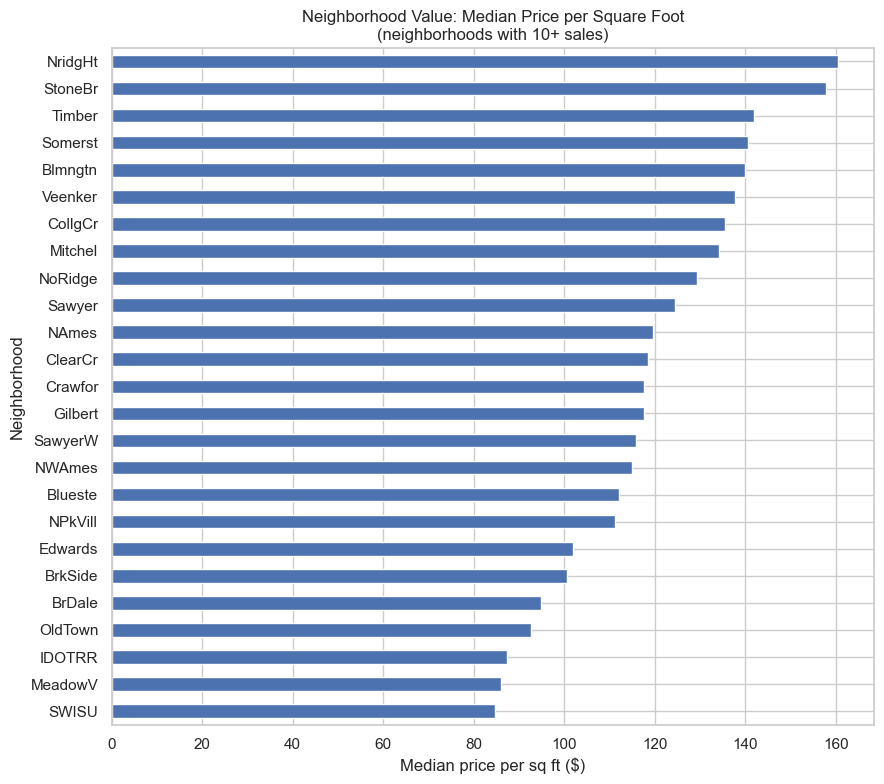

Top 5 most expensive per sq ft:
              median_ppsf    n
Neighborhood                  
NridgHt        160.362880  166
StoneBr        157.864524   51
Timber         141.817341   72
Somerst        140.531138  182
Blmngtn        139.825328   28

Bottom 5 cheapest per sq ft:
              median_ppsf    n
Neighborhood                  
BrDale          94.813269   30
OldTown         92.532468  239
IDOTRR          87.246180   93
MeadowV         86.101695   37
SWISU           84.587224   48


In [166]:
# Price per square foot as a size-normalized measure of neighborhood value.
# Compute this as a local Series from the cleaned dataset.
price_per_sqft = df["SalePrice"] / df["GrLivArea"]

ppsf_by_neighborhood = (
    price_per_sqft.groupby(df["Neighborhood"])
    .agg(median_ppsf="median", n="count")
    .query("n >= 10")  # drop neighborhoods with too few sales to be reliable
    .sort_values("median_ppsf", ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 8))
ppsf_by_neighborhood["median_ppsf"].sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_xlabel("Median price per sq ft ($)")
ax.set_title("Neighborhood Value: Median Price per Square Foot\n(neighborhoods with 10+ sales)")
plt.tight_layout()
plt.show()

print("Top 5 most expensive per sq ft:")
print(ppsf_by_neighborhood.head(5))
print("\nBottom 5 cheapest per sq ft:")
print(ppsf_by_neighborhood.tail(5))

**Finding:** `NridgHt` and `StoneBr` command the highest price per square foot (~$157â€“160/sqft)
among neighborhoods with reliable sample sizes, while `SWISU`, `MeadowV`, and `IDOTRR` sit at the
bottom (~$85â€“87/sqft) â€” nearly a **2x gap** in what buyers pay per square foot depending on
location alone, holding house size constant.

**Interpretation:** This is a genuinely different lens than "most expensive neighborhood" â€”
it separates *location premium* from *house size*. For a business audience, this framing directly
answers two different questions: a buyer optimizing for space-for-money would look at the bottom
of this list, while an investor asking "where does location itself add the most value" (e.g. for
comparing renovation ROI against buying in a pricier area) would look at the top. It also flags
`NridgHt`/`StoneBr` as neighborhoods where even a modest house is likely to sell at a premium
purely for its location.

**Follow-up:** Beyond location, does *when* a house was last renovated meaningfully affect what it
sells for â€” i.e. is there a measurable return to remodeling before selling?

### 10.2 Does a Recent Remodel Pay Off?

**Question:** From a homeowner's perspective deciding whether to remodel before listing a house:
does how *recently* a house was remodeled relate to its sale price, independent of the house's
original age?

**Analysis:** A naive comparison of "ever remodeled" vs. "never remodeled" is misleading here,
because most never-remodeled houses in this dataset are simply newer builds that haven't needed
it yet â€” that comparison would confound remodeling with age. Instead, computed
`YearsSinceRemodel = YrSold - YearRemodAdd` for every house (for a never-remodeled house this
equals its age) and correlated it directly against `SalePrice`.

**Visualization:** Scatter plot of years since last remodel vs. SalePrice, with a trend line.

Correlation between years-since-remodel and SalePrice: -0.53


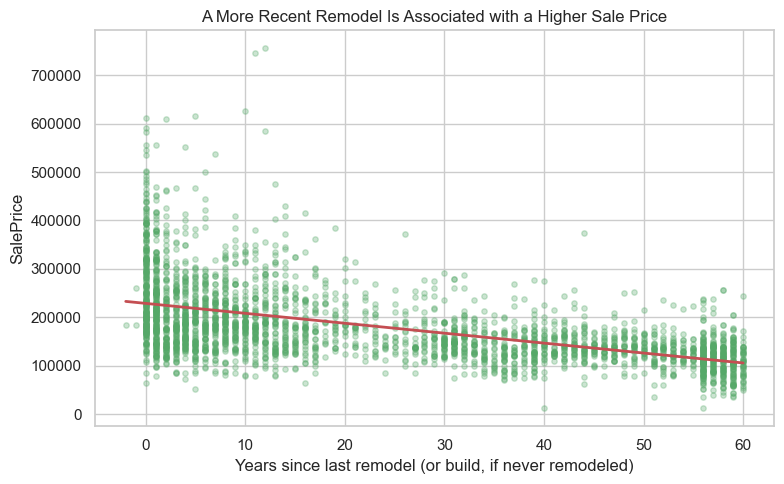

In [167]:
# Years since the most recent remodel (or original build, if never remodeled) vs price.
# Computed as a local Series from the cleaned dataset.
years_since_remodel = df["YrSold"] - df["YearRemodAdd"]

corr_remodel = pd.concat([years_since_remodel.rename("YearsSinceRemodel"), df["SalePrice"]], axis=1).corr().iloc[0, 1]
print(f"Correlation between years-since-remodel and SalePrice: {corr_remodel:.2f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(years_since_remodel, df["SalePrice"], alpha=0.3, color="#55A868", s=15)

valid_mask = years_since_remodel.notna() & df["SalePrice"].notna()
z = np.polyfit(years_since_remodel[valid_mask], df["SalePrice"][valid_mask], 1)
trend = np.poly1d(z)
xs = np.linspace(years_since_remodel[valid_mask].min(), years_since_remodel[valid_mask].max(), 100)
ax.plot(xs, trend(xs), color="#C44E52", linewidth=2)

ax.set_xlabel("Years since last remodel (or build, if never remodeled)")
ax.set_ylabel("SalePrice")
ax.set_title("A More Recent Remodel Is Associated with a Higher Sale Price")
plt.tight_layout()
plt.show()

**Finding:** Years-since-remodel correlates with `SalePrice` at about **-0.53** â€” almost as
strongly as house age itself (-0.56). Prices drop steadily the longer it's been since a house was
last updated, whether that update was the original construction or a later remodel.

**Interpretation:** This reframes the earlier naive "remodeled vs. not" comparison correctly:
the finding isn't that remodeling itself lowers value, it's that a *stale* remodel (or a house
that's never been touched since a much older build date) loses value at roughly the same rate
that age does. In business terms, this supports two practical takeaways: (1) a remodel functions
like a partial "reset" of a house's effective age in the eyes of the market, and (2) a homeowner
weighing whether to remodel before selling should weigh the cost of renovation against roughly
the same price recovery that a genuinely newer-built comparable would command â€” the data doesn't
show a magic premium for remodeling beyond what it does for perceived recency/condition.

**Follow-up:** If recency matters this much, what does the relationship between raw house age and
price look like on its own â€” is depreciation steady, or does it flatten out for very old homes?

### 10.3 The Age Depreciation Curve

**Question:** How much does SalePrice actually decline as a house gets older, and does that
decline happen at a constant rate or level off for very old homes?

**Analysis:** Computed `HouseAge = YrSold - YearBuilt` for every property, grouped it into age
brackets, and compared the median SalePrice per bracket â€” a more interpretable, business-facing
view than a single correlation coefficient.

**Visualization:** Bar chart of median SalePrice by age bracket.

          median  count
0-5     228187.5    626
6-10    214000.0    251
11-20   205650.0    262
21-30   161250.0    168
31-50   144000.0    738
51-75   129650.0    478
76-100  119500.0    342
100+    122250.0     64


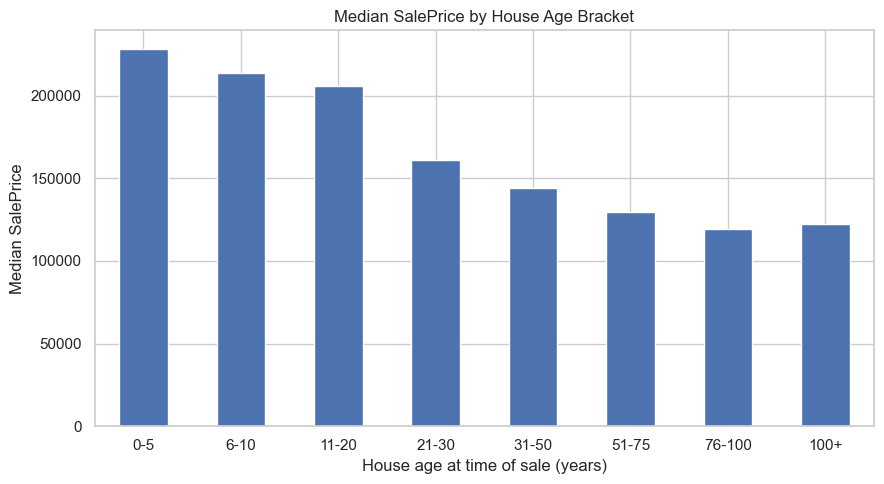

In [168]:
# Median price by house-age bracket at time of sale.
# Computed from the cleaned dataset without adding modeling features to df.
house_age = df["YrSold"] - df["YearBuilt"]
age_bracket = pd.cut(
    house_age,
    bins=[-1, 5, 10, 20, 30, 50, 75, 100, 200],
    labels=["0-5", "6-10", "11-20", "21-30", "31-50", "51-75", "76-100", "100+"]
)

age_price = df["SalePrice"].groupby(age_bracket, observed=True).agg(["median", "count"])
print(age_price)

fig, ax = plt.subplots(figsize=(9, 5))
age_price["median"].plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_ylabel("Median SalePrice")
ax.set_xlabel("House age at time of sale (years)")
ax.set_title("Median SalePrice by House Age Bracket")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Finding:** Median price falls from about $228,000 for houses 0â€“5 years old to about
$130,000â€“120,000 for houses over 51 years old â€” roughly a **45% drop** â€” but the decline is not
linear: it is steepest in the first 30 years (losing over $65,000 of median value) and largely
**flattens out after about 50 years**, with 76â€“100-year-old and 100+-year-old homes selling for
almost the same median price.

**Interpretation:** This has a direct business reading: the biggest price penalty for age falls
on houses in their first three decades, which matches intuition â€” a 25-year-old house has visibly
dated systems and finishes relative to a 5-year-old one, while a 90-year-old and a 110-year-old
house are both simply "old" and may increasingly sell on lot value, character, or renovation
potential rather than original condition. For pricing or investment purposes, this means age
alone is a much weaker signal for houses beyond ~50 years than for newer housing stock.

**Follow-up:** Beyond structural age and remodeling, do specific added features (an extra
bathroom, a fireplace, more garage space) show a clear, quantifiable value that a homeowner could
weigh against the cost of adding them?

### 10.4 What Is an Extra Bathroom, Fireplace, or Garage Space Worth?

**Question:** For a homeowner or investor weighing a specific improvement (adding a bathroom, a
fireplace, or garage capacity), does the data show a clear, step-by-step price difference
associated with each additional unit of that feature?

**Analysis:** Grouped SalePrice by `FullBath`, `Fireplaces`, and `GarageCars` count separately,
and compared median price at each level (restricted to levels with a reasonable sample size).

**Visualization:** Three side-by-side bar charts, one per feature, showing median price by
feature count.

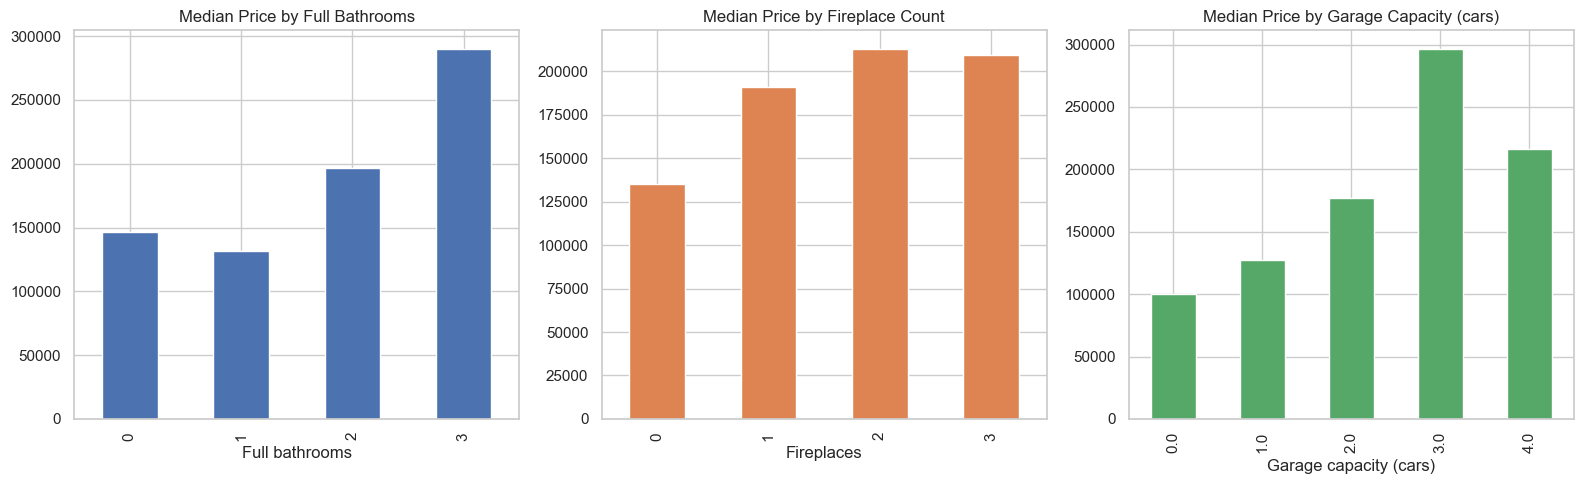

Median price by FullBath:
             median  count
FullBath                 
0         146662.5     12
1         131500.0   1318
2         196500.0   1532
3         290000.0     64 

Median price by Fireplaces:
               median  count
Fireplaces                 
0           135500.0   1422
1           191000.0   1274
2           213000.0    221
3           209500.0     12 

Median price by GarageCars:
               median  count
GarageCars                 
0.0         100000.0    157
1.0         127000.0    779
2.0         177000.0   1603
3.0         296500.0    374
4.0         216500.0     16


In [169]:
# Median price by count for three "addable" features, restricted to well-supported levels.
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

bath_summary = df.groupby("FullBath")["SalePrice"].agg(["median", "count"]).query("count >= 10")
bath_summary["median"].plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Median Price by Full Bathrooms")
axes[0].set_xlabel("Full bathrooms")

fire_summary = df.groupby("Fireplaces")["SalePrice"].agg(["median", "count"]).query("count >= 10")
fire_summary["median"].plot(kind="bar", ax=axes[1], color="#DD8452")
axes[1].set_title("Median Price by Fireplace Count")
axes[1].set_xlabel("Fireplaces")

garage_summary = df.groupby("GarageCars")["SalePrice"].agg(["median", "count"]).query("count >= 10")
garage_summary["median"].plot(kind="bar", ax=axes[2], color="#55A868")
axes[2].set_title("Median Price by Garage Capacity (cars)")
axes[2].set_xlabel("Garage capacity (cars)")

plt.tight_layout()
plt.show()

print("Median price by FullBath:\n", bath_summary, "\n")
print("Median price by Fireplaces:\n", fire_summary, "\n")
print("Median price by GarageCars:\n", garage_summary)

**Finding:** Each additional unit is associated with a clear, mostly-consistent jump in median
price, up to a point: going from 1 to 2 full bathrooms adds about **$65,000** to the median price
(from ~$131,500 to ~$196,500), and 2 to 3 adds nearly another **$94,000**. A first fireplace adds
about **$55,500** over none. Garage capacity shows the largest single jump between 2 and 3 cars
(~$177,000 to ~$296,500), though the 3-car sample is smaller and likely overlaps heavily with
larger, higher-end homes generally.

**Interpretation:** These are association gaps, not proof that literally *installing* a second
bathroom in an existing house would add exactly $65,000 â€” houses with more bathrooms also tend to
be larger and higher-`OverallQual` overall, so this partly reflects "bigger/nicer houses have more
of everything," not a pure causal renovation return. Still, for a business audience this ranks
feature counts in a way that's directly actionable: a missing second bathroom looks like the
single most consistently price-associated gap among these three features, which is useful context
when comparing renovation options against their cost. A more rigorous causal estimate (isolating
bathroom count while holding size and quality fixed) is a natural extension once modeling begins.

## 11. Manual and automated EDA conclusion


Manual EDA explains what the broad automated profile flags. The raw-data report covers 2,930 observations and 82 variables; it agrees with manual checks on 490 missing `LotFrontage` values and the right-skewed `SalePrice` distribution (skewness about 1.744). It also flags 2,917 missing `PoolQC` values and strong skewness in `MiscVal` (about 22).

The manual plots add property-level context: they identify the unusually large homes in `GrLivArea` and show how prices vary with `OverallQual` and neighborhood. The automated alert for correlation between `Order` and `YrSold` concerns a record identifier; it should not be treated as evidence that `Order` is a useful model feature. Missing amenity values need checks against related fields before interpreting them as true absence. The accompanying HTML report contains the full column-by-column automated results.


## 12. Column classification: numerical, nominal, ordinal


In [170]:

# Identifiers and target are excluded from feature groups
id_cols = ["Order", "PID"]
target_col = "SalePrice"

# Nominal categorical: no inherent order between categories
nominal_features = [
    "MSSubClass", "MSZoning", "Street", "Alley", "LandContour", "LotConfig",
    "Neighborhood", "Condition1", "Condition2", "BldgType", "HouseStyle",
    "RoofStyle", "RoofMatl", "Exterior1st", "Exterior2nd", "MasVnrType",
    "Foundation", "Heating", "CentralAir", "Electrical", "GarageType",
    "MiscFeature", "SaleType", "SaleCondition"
]

# Ordinal categorical: categories have a natural rank/order
ordinal_features = [
    "LotShape", "Utilities", "LandSlope", "ExterQual", "ExterCond",
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "HeatingQC", "KitchenQual", "Functional", "FireplaceQu", "GarageFinish",
    "GarageQual", "GarageCond", "PavedDrive", "PoolQC", "Fence"
]

# Numerical: continuous or discrete counts/measurements
numerical_features = [
    "LotFrontage", "LotArea", "OverallQual", "OverallCond", "YearBuilt",
    "YearRemodAdd", "MasVnrArea", "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF",
    "TotalBsmtSF", "1stFlrSF", "2ndFlrSF", "LowQualFinSF", "GrLivArea",
    "BsmtFullBath", "BsmtHalfBath", "FullBath", "HalfBath", "BedroomAbvGr",
    "KitchenAbvGr", "TotRmsAbvGrd", "Fireplaces", "GarageYrBlt", "GarageCars",
    "GarageArea", "WoodDeckSF", "OpenPorchSF", "EnclosedPorch", "3SsnPorch",
    "ScreenPorch", "PoolArea", "MiscVal", "MoSold", "YrSold"
]

# --- Sanity check: make sure every column is accounted for exactly once ---
all_grouped = id_cols + [target_col] + nominal_features + ordinal_features + numerical_features
missing_from_groups = set(df.columns) - set(all_grouped)
extra_in_groups = set(all_grouped) - set(df.columns)

print("Total columns in df:", df.shape[1])
print("Total columns grouped:", len(all_grouped))
print("Columns not grouped yet:", missing_from_groups)
print("Grouped names not found in df:", extra_in_groups)

Total columns in df: 82
Total columns grouped: 82
Columns not grouped yet: set()
Grouped names not found in df: set()


### 12.1 Review categorical levels before modeling

Review the cleaned ordinal and nominal category values before encoding and splitting for modeling.


In [171]:
for col in ordinal_features:
    print(col, "â†’", sorted(df[col].dropna().unique()))

LotShape â†’ ['IR1', 'IR2', 'IR3', 'Reg']
Utilities â†’ ['AllPub', 'NoSeWa', 'NoSewr']
LandSlope â†’ ['Gtl', 'Mod', 'Sev']
ExterQual â†’ ['Ex', 'Fa', 'Gd', 'TA']
ExterCond â†’ ['Ex', 'Fa', 'Gd', 'Po', 'TA']
BsmtQual â†’ ['Ex', 'Fa', 'Gd', 'NA', 'Po', 'TA']
BsmtCond â†’ ['Ex', 'Fa', 'Gd', 'NA', 'Po', 'TA']
BsmtExposure â†’ ['Av', 'Gd', 'Mn', 'NA', 'No']
BsmtFinType1 â†’ ['ALQ', 'BLQ', 'GLQ', 'LwQ', 'NA', 'Rec', 'Unf']
BsmtFinType2 â†’ ['ALQ', 'BLQ', 'GLQ', 'LwQ', 'NA', 'Rec', 'Unf']
HeatingQC â†’ ['Ex', 'Fa', 'Gd', 'Po', 'TA']
KitchenQual â†’ ['Ex', 'Fa', 'Gd', 'Po', 'TA']
Functional â†’ ['Maj1', 'Maj2', 'Min1', 'Min2', 'Mod', 'Sal', 'Sev', 'Typ']
FireplaceQu â†’ ['Ex', 'Fa', 'Gd', 'NA', 'Po', 'TA']
GarageFinish â†’ ['Fin', 'NA', 'RFn', 'Unf']
GarageQual â†’ ['Ex', 'Fa', 'Gd', 'NA', 'Po', 'TA']
GarageCond â†’ ['Ex', 'Fa', 'Gd', 'NA', 'Po', 'TA']
PavedDrive â†’ ['N', 'P', 'Y']
PoolQC â†’ ['Ex', 'Fa', 'Gd', 'NA', 'TA']
Fence â†’ ['GdPrv', 'GdWo', 'MnPrv', 'MnWw', 'NA']


In [172]:
for col in nominal_features:
    print(col, "â†’", sorted(df[col].dropna().unique()))

MSSubClass â†’ [20, 30, 40, 45, 50, 60, 70, 75, 80, 85, 90, 120, 150, 160, 180, 190]
MSZoning â†’ ['A (agr)', 'C (all)', 'FV', 'I (all)', 'RH', 'RL', 'RM']
Street â†’ ['Grvl', 'Pave']
Alley â†’ ['Grvl', 'NA', 'Pave']
LandContour â†’ ['Bnk', 'HLS', 'Low', 'Lvl']
LotConfig â†’ ['Corner', 'CulDSac', 'FR2', 'FR3', 'Inside']
Neighborhood â†’ ['Blmngtn', 'Blueste', 'BrDale', 'BrkSide', 'ClearCr', 'CollgCr', 'Crawfor', 'Edwards', 'Gilbert', 'Greens', 'GrnHill', 'IDOTRR', 'Landmrk', 'MeadowV', 'Mitchel', 'NAmes', 'NPkVill', 'NWAmes', 'NoRidge', 'NridgHt', 'OldTown', 'SWISU', 'Sawyer', 'SawyerW', 'Somerst', 'StoneBr', 'Timber', 'Veenker']
Condition1 â†’ ['Artery', 'Feedr', 'Norm', 'PosA', 'PosN', 'RRAe', 'RRAn', 'RRNe', 'RRNn']
Condition2 â†’ ['Artery', 'Feedr', 'Norm', 'PosA', 'PosN', 'RRAe', 'RRAn', 'RRNn']
BldgType â†’ ['1Fam', '2fmCon', 'Duplex', 'Twnhs', 'TwnhsE']
HouseStyle â†’ ['1.5Fin', '1.5Unf', '1Story', '2.5Fin', '2.5Unf', '2Story', 'SFoyer', 'SLvl']
RoofStyle â†’ ['Flat', 'Gable', '

### 12.2 Ordinal category order definitions

Define the explicit order used later by the ordinal encoder. The coverage check confirms that every observed cleaned category is represented.


In [173]:
# Quality scale used by most of the ordinal columns, worst to best.
QUALITY_ORDER = ["NA", "Po", "Fa", "TA", "Gd", "Ex"]

# Basement finish has its own scale.
BSMT_FINISH_ORDER = ["NA", "Unknown", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"]

ORDINAL_ORDERS = {
    "LotShape": ["Reg", "IR1", "IR2", "IR3"],
    "Utilities": ["ELO", "NoSeWa", "NoSewr", "AllPub"],
    "LandSlope": ["Gtl", "Mod", "Sev"],
    "ExterQual": QUALITY_ORDER,
    "ExterCond": QUALITY_ORDER,
    "BsmtQual": QUALITY_ORDER,
    "BsmtCond": QUALITY_ORDER,
    "BsmtExposure": ["NA", "Unknown", "No", "Mn", "Av", "Gd"],
    "BsmtFinType1": BSMT_FINISH_ORDER,
    "BsmtFinType2": BSMT_FINISH_ORDER,
    "HeatingQC": QUALITY_ORDER,
    "KitchenQual": QUALITY_ORDER,
    "Functional": ["Sal", "Sev", "Maj2", "Maj1", "Mod", "Min2", "Min1", "Typ"],
    "FireplaceQu": QUALITY_ORDER,
    "GarageFinish": ["NA", "Unf", "RFn", "Fin"],
    "GarageQual": QUALITY_ORDER,
    "GarageCond": QUALITY_ORDER,
    "PavedDrive": ["N", "P", "Y"],
    "PoolQC": QUALITY_ORDER,
    "Fence": ["NA", "MnWw", "GdWo", "MnPrv", "GdPrv"],
}

# Check that every value in the data is covered by the order above.
coverage_problems = {}
for column in ordinal_features:
    observed = set(df[column].dropna().unique())
    uncovered = observed - set(ORDINAL_ORDERS[column])
    if uncovered:
        coverage_problems[column] = sorted(uncovered)

if coverage_problems:
    print("Categories missing from ORDINAL_ORDERS:", coverage_problems)
else:
    print("Every ordinal category is covered by ORDINAL_ORDERS.")

Every ordinal category is covered by ORDINAL_ORDERS.


### 12.3 Numerical feature summary before modeling

Review the numerical variables and their remaining missingness/statistics before feature engineering and preprocessing.


In [174]:
# Describe the numerical features in the Ames Housing dataset.
numerical_feature_descriptions = {
    "LotFrontage": "Street-facing length of the property",
    "LotArea": "Land area in square feet",
    "OverallQual": "Overall material and finish quality, rated from 1 to 10",
    "OverallCond": "Overall condition of the property, rated from 1 to 10",
    "YearBuilt": "Original construction year",
    "YearRemodAdd": "Year of the most recent remodeling",
    "MasVnrArea": "Masonry veneer area in square feet",
    "BsmtFinSF1": "Finished basement area with primary finish",
    "BsmtFinSF2": "Finished basement area with secondary finish",
    "BsmtUnfSF": "Unfinished basement area in square feet",
    "TotalBsmtSF": "Total basement area in square feet",
    "1stFlrSF": "First-floor area in square feet",
    "2ndFlrSF": "Second-floor area in square feet",
    "LowQualFinSF": "Low-quality finished area in square feet",
    "GrLivArea": "Above-grade living area in square feet",
    "BsmtFullBath": "Number of full bathrooms in the basement",
    "BsmtHalfBath": "Number of half bathrooms in the basement",
    "FullBath": "Number of full bathrooms above grade",
    "HalfBath": "Number of half bathrooms above grade",
    "BedroomAbvGr": "Number of bedrooms above grade",
    "KitchenAbvGr": "Number of kitchens above grade",
    "TotRmsAbvGrd": "Total rooms above grade, excluding bathrooms",
    "Fireplaces": "Number of fireplaces",
    "GarageYrBlt": "Year the garage was built",
    "GarageCars": "Garage capacity in cars",
    "GarageArea": "Garage area in square feet",
    "WoodDeckSF": "Wood deck area in square feet",
    "OpenPorchSF": "Open porch area in square feet",
    "EnclosedPorch": "Enclosed porch area in square feet",
    "3SsnPorch": "Three-season porch area in square feet",
    "ScreenPorch": "Screen porch area in square feet",
    "PoolArea": "Pool area in square feet",
    "MiscVal": "Value of miscellaneous features in dollars",
    "MoSold": "Month in which the property was sold",
    "YrSold": "Year in which the property was sold"
}

numerical_feature_table = pd.DataFrame({
    "Feature": numerical_features,
    "Description": [
        numerical_feature_descriptions[column]
        for column in numerical_features
    ],
    "Data Type": [str(df[column].dtype) for column in numerical_features],
    "Missing Values": [df[column].isna().sum() for column in numerical_features],
    "Unique Values": [df[column].nunique(dropna=True) for column in numerical_features],
    "Minimum": [df[column].min() for column in numerical_features],
    "Median": [df[column].median() for column in numerical_features],
    "Mean": [df[column].mean() for column in numerical_features],
    "Maximum": [df[column].max() for column in numerical_features],
    "Skewness": [df[column].skew() for column in numerical_features]
})

print("Numerical feature descriptions and summary statistics:")
print(numerical_feature_table.to_string(index=False))

Numerical feature descriptions and summary statistics:
      Feature                                             Description Data Type  Missing Values  Unique Values  Minimum  Median         Mean  Maximum  Skewness
  LotFrontage                    Street-facing length of the property   float64             122            133     21.0    69.0    69.410078    313.0  1.452471
      LotArea                                Land area in square feet     int64               0           1960   1300.0  9436.5 10147.921843 215245.0 12.820898
  OverallQual Overall material and finish quality, rated from 1 to 10     int64               0             10      1.0     6.0     6.094881     10.0  0.190634
  OverallCond   Overall condition of the property, rated from 1 to 10     int64               0              9      1.0     5.0     5.563140      9.0  0.574429
    YearBuilt                              Original construction year     int64               0            118   1872.0  1973.0  1971.356314   20

In [175]:
# Find numerical features with strong skewness.
numerical_skewness = df[numerical_features].skew().sort_values()

skewed_numerical_features = numerical_skewness.loc[
    (numerical_skewness > 1) | (numerical_skewness < -1)
].sort_values(key=lambda values: values.abs(), ascending=False)

print("Numerical features with skewness greater than 1 or less than -1:")
print(skewed_numerical_features.to_string())

print("\nColumn names only:")
print(skewed_numerical_features.index.tolist())

Numerical features with skewness greater than 1 or less than -1:
MiscVal          21.999788
PoolArea         16.939142
LotArea          12.820898
LowQualFinSF     12.118162
3SsnPorch        11.403795
KitchenAbvGr      4.313825
BsmtFinSF2        4.139978
EnclosedPorch     4.014446
ScreenPorch       3.957467
BsmtHalfBath      3.940795
MasVnrArea        2.608327
OpenPorchSF       2.535386
WoodDeckSF        1.842678
1stFlrSF          1.469429
LotFrontage       1.452471
BsmtFinSF1        1.416182
GrLivArea         1.274110
TotalBsmtSF       1.156204

Column names only:
['MiscVal', 'PoolArea', 'LotArea', 'LowQualFinSF', '3SsnPorch', 'KitchenAbvGr', 'BsmtFinSF2', 'EnclosedPorch', 'ScreenPorch', 'BsmtHalfBath', 'MasVnrArea', 'OpenPorchSF', 'WoodDeckSF', '1stFlrSF', 'LotFrontage', 'BsmtFinSF1', 'GrLivArea', 'TotalBsmtSF']


### 12.4 Transformation timing

The skewness transformation is intentionally deferred until after feature engineering,
final column add/drop decisions, and the frozen train/validation/test split. The actual
train-only transformation step is in Section 16.

## 13. Feature engineering

New columns are built from plain arithmetic on existing columns, so they can be created before the split. No engineered feature uses `SalePrice`, and no dataset-level statistic is learned in this step.


In [176]:
# New features built from existing columns.
# None of them uses SalePrice, so they can be created before the split.
#
# Section 7 left one row genuinely unresolved: PID 903230120 has TotalBsmtSF = NaN,
# and its basement status cannot be established from the supplied fields. A flag
# built as (value > 0) would read that NaN as "no basement", which is the false
# absence label section 7 refused to apply. HasBasementKnown marks that row as
# unresolved instead, so the model can tell "absent" from "unknown".
#
# GarageType is NaN for 0 rows after section 7.8.1 labelled absent garages as "NA",
# so it is the reliable garage source and covers PID 910201180, whose GarageArea
# could not be estimated. No "known" partner is needed for the garage flag.

def add_engineered_features(frame):
    """Add derived house features and return a new DataFrame."""
    data = frame.copy()

    # Age in years. Clipped at 0 because section 8.4 found genuine new and partial
    # sales whose build or remodel year is after YrSold; a negative age is not
    # meaningful, and those rows are already flagged by IsNew.
    data["HouseAge"] = (data["YrSold"] - data["YearBuilt"]).clip(lower=0)
    data["RemodAge"] = (data["YrSold"] - data["YearRemodAdd"]).clip(lower=0)

    # Was the house ever remodeled, and was it sold new?
    # Both are derivable from the year columns, which are kept alongside, so they
    # are kept mainly to give the tree-free linear model an easy cut point.
    data["IsRemodeled"] = (data["YearRemodAdd"] != data["YearBuilt"]).astype(int)
    data["IsNew"] = (data["YrSold"] == data["YearBuilt"]).astype(int)

    # Total living space and total bathrooms.
    # fillna(0) is deliberate: the source columns are NaN only for the one row with
    # no basement information, and a missing area contributes no area.
    data["TotalSF"] = (
        data["TotalBsmtSF"].fillna(0) + data["1stFlrSF"] + data["2ndFlrSF"]
    )
    data["TotalBath"] = (
        data["FullBath"] + data["BsmtFullBath"].fillna(0)
        + 0.5 * (data["HalfBath"] + data["BsmtHalfBath"].fillna(0))
    )

    # Porch and deck area combined.
    data["TotalPorchSF"] = (
        data["OpenPorchSF"] + data["EnclosedPorch"]
        + data["3SsnPorch"] + data["ScreenPorch"] + data["WoodDeckSF"]
    )

    # Presence flags. Many area columns are zero for most houses, so a plain
    # "has this feature" flag is easier for a linear model to use.
    # These three sources have no missing values, so they need no "known" partner.
    data["HasPool"] = (data["PoolArea"] > 0).astype(int)
    data["Has2ndFloor"] = (data["2ndFlrSF"] > 0).astype(int)
    data["HasFireplace"] = (data["Fireplaces"] > 0).astype(int)

    # Garage comes from the categorical column, not the area: section 7.8.3 could
    # not estimate GarageArea for PID 910201180, but its type is known to be Detchd.
    data["HasGarage"] = (data['GarageCars'].fillna(0) > 0).astype(int)
    # Basement. HasBasement is 1 only when the area prove''s a basement exists, and
    # HasBasementKnown separates the unproven row from a confirmed absence.
    data["HasBasement"] = (data["TotalBsmtSF"].fillna(0) > 0).astype(int)
    data["HasBasementKnown"] = data["TotalBsmtSF"].notna().astype(int)

    return data


engineered_numeric_features = [
    "HouseAge", "RemodAge", "IsRemodeled", "IsNew", "TotalSF", "TotalBath",
    "TotalPorchSF", "HasPool", "Has2ndFloor", "HasFireplace",
    "HasGarage", "HasBasement", "HasBasementKnown"
]

print("Engineered columns:", len(engineered_numeric_features))
print(engineered_numeric_features)

Engineered columns: 13
['HouseAge', 'RemodAge', 'IsRemodeled', 'IsNew', 'TotalSF', 'TotalBath', 'TotalPorchSF', 'HasPool', 'Has2ndFloor', 'HasFireplace', 'HasGarage', 'HasBasement', 'HasBasementKnown']


## 14. Feature selection: add engineered columns and drop redundant columns

Feature engineering is completed first. Then the modeling feature set is created by adding the engineered numerical columns and removing identifiers plus redundant component columns.

This happens **before** skewness transformation, so the transformation step sees the final modeling columns.

### 14.1 Preprocessing definitions are finalized after the train-only transformation

The actual `Pipeline` objects are created in Section 17, after the final feature columns are fixed and the train-only skewness transformation has been fitted.

In [177]:
# Pipeline construction is intentionally deferred until Section 17.
print("Preprocessing pipelines will be finalized after train-only transformations.")

Preprocessing pipelines will be finalized after train-only transformations.


In [178]:
# ============================================================
# 1. Columns to DROP
# ============================================================
# Identifiers are already excluded from model_data below.
# These component columns are removed because their information is
# represented by engineered aggregate features.

redundant_numeric_cols = [
    # Replaced by TotalSF
    "1stFlrSF", "2ndFlrSF", "TotalBsmtSF",

    # Replaced by TotalBath
    "FullBath", "HalfBath", "BsmtFullBath", "BsmtHalfBath",

    # Replaced by TotalPorchSF
    "WoodDeckSF", "OpenPorchSF", "EnclosedPorch",
    "3SsnPorch", "ScreenPorch",

    # Replaced by HouseAge / RemodAge
    "YearBuilt", "YearRemodAdd",

    # Strongly redundant with GarageArea
    "GarageCars",
]

# ============================================================
# 2. ADD ENGINEERED NUMERICAL COLUMNS
# ============================================================

final_engineered_numeric_features = engineered_numeric_features.copy()

# ============================================================
# 3. BUILD THE FINAL MODEL DATASET
# ============================================================

model_data = add_engineered_features(
    df.drop(columns=id_cols)
)

# Drop redundant columns BEFORE any transformation.
model_data = model_data.drop(
    columns=redundant_numeric_cols,
    errors="ignore"
)

# Separate target from model features.
X = model_data.drop(columns=[target_col])
y = model_data[target_col].copy()

# Numerical columns retained after add/drop.
all_numeric_features = [
    col
    for col in (numerical_features + final_engineered_numeric_features)
    if col in X.columns
    and col not in redundant_numeric_cols
]

# Categorical columns retained.
final_nominal_features = [
    col for col in nominal_features if col in X.columns
]

final_ordinal_features = [
    col for col in ordinal_features if col in X.columns
]

print("=" * 70)
print("FINAL MODEL COLUMN SET BEFORE TRANSFORMATION")
print("=" * 70)

print(f"Original df columns:       {df.shape[1]}")
print(f"Model-data columns:        {model_data.shape[1]}")
print(f"Engineered columns added:  {len(final_engineered_numeric_features)}")
print(f"Redundant columns dropped: {len(redundant_numeric_cols)}")
print(f"Numerical features kept:   {len(all_numeric_features)}")
print(f"Nominal features kept:     {len(final_nominal_features)}")
print(f"Ordinal features kept:     {len(final_ordinal_features)}")
print(f"Target:                    {target_col}")

print("\nEngineered columns:")
print(final_engineered_numeric_features)

print("\nDropped numerical columns:")
print(redundant_numeric_cols)

FINAL MODEL COLUMN SET BEFORE TRANSFORMATION
Original df columns:       82
Model-data columns:        78
Engineered columns added:  13
Redundant columns dropped: 15
Numerical features kept:   33
Nominal features kept:     24
Ordinal features kept:     20
Target:                    SalePrice

Engineered columns:
['HouseAge', 'RemodAge', 'IsRemodeled', 'IsNew', 'TotalSF', 'TotalBath', 'TotalPorchSF', 'HasPool', 'Has2ndFloor', 'HasFireplace', 'HasGarage', 'HasBasement', 'HasBasementKnown']

Dropped numerical columns:
['1stFlrSF', '2ndFlrSF', 'TotalBsmtSF', 'FullBath', 'HalfBath', 'BsmtFullBath', 'BsmtHalfBath', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'YearBuilt', 'YearRemodAdd', 'GarageCars']


## 15. Train / Validation / Test Split

The final feature set is already fixed before this point: engineered columns have been added,
identifiers and redundant component columns have been removed, and only then do we perform
the train/validation/test modeling split.

The actual index split was frozen earlier in Section 6.5 so the cleaning rules could respect
the training boundary. Here we simply reuse those exact indices.

In [179]:
# ============================================================
# Train / Validation / Test data
# ============================================================
# Reuse the exact split frozen in Section 6.5.
# No new split is created here.

X_train = X.loc[train_index].copy()
X_val = X.loc[val_index].copy()
X_test = X.loc[test_index].copy()

y_train = y.loc[train_index].copy()
y_val = y.loc[val_index].copy()
y_test = y.loc[test_index].copy()

assert set(train_index).isdisjoint(val_index)
assert set(train_index).isdisjoint(test_index)
assert set(val_index).isdisjoint(test_index)

print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)

print("\nFeature columns:", X.shape[1])
print("  numerical:", len(all_numeric_features))
print("  nominal:", len(final_nominal_features))
print("  ordinal:", len(final_ordinal_features))

print("\nSalePrice is still on its original scale at this point.")
print(f"Original y_train skewness: {y_train.skew():.6f}")

Training set: (2050, 77) (2050,)
Validation set: (440, 77) (440,)
Test set: (440, 77) (440,)

Feature columns: 77
  numerical: 33
  nominal: 24
  ordinal: 20

SalePrice is still on its original scale at this point.
Original y_train skewness: 1.791250


## 16. Train-only skewness transformation

The final modeling columns are now fixed. Skewness is measured **only on `X_train`**.

For each positively skewed numerical feature (`skew > 1`), all candidate transformations are tested using training data only. The transformation with the smallest absolute training skewness is selected and fitted on the training data.

The fitted transformation is then:
- applied to `X_train`;
- reused unchanged to transform `X_val` and `X_test`;
- never fitted using validation or test data.

The target `SalePrice` is handled separately: its best transformation is selected and fitted using `y_train` only. `y_val` and `y_test` remain on the original dollar scale.

In [180]:
# ============================================================
# 16.1 Helper functions for candidate transformations
# ============================================================

from sklearn.preprocessing import PowerTransformer, QuantileTransformer
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd


def _fit_one_feature_transform(train_values):
    """
    Fit all candidate transformations using TRAIN values only.
    Returns the best transformation name, fitted object/parameters,
    and the transformed training values.
    """
    train_values = np.asarray(train_values, dtype=float)

    # Median is learned from TRAIN only.
    median = np.nanmedian(train_values)
    values = np.where(np.isnan(train_values), median, train_values)

    minimum = values.min()

    nonnegative_shift = max(0, -minimum)
    positive_shift = max(0, 1 - minimum)

    nonnegative = values + nonnegative_shift
    positive = values + positive_shift

    std = values.std()
    mean = values.mean()

    if std == 0:
        standardized = np.zeros_like(values)
    else:
        standardized = (values - mean) / std

    reflection_constant = values.max() + 1

    candidates = {}
    fitted = {}

    # ----------------------------
    # Log
    # ----------------------------
    candidates["Log"] = np.log1p(nonnegative)
    fitted["Log"] = {
        "type": "log",
        "shift": nonnegative_shift
    }

    # ----------------------------
    # Square Root
    # ----------------------------
    candidates["Square Root"] = np.sqrt(nonnegative)
    fitted["Square Root"] = {
        "type": "sqrt",
        "shift": nonnegative_shift
    }

    # ----------------------------
    # Cube Root
    # ----------------------------
    candidates["Cube Root"] = np.cbrt(values)
    fitted["Cube Root"] = {
        "type": "cbrt"
    }

    # ----------------------------
    # Reciprocal
    # ----------------------------
    candidates["Reciprocal"] = 1 / positive
    fitted["Reciprocal"] = {
        "type": "reciprocal",
        "shift": positive_shift
    }

    # ----------------------------
    # Box-Cox
    # ----------------------------
    box_cox = PowerTransformer(
        method="box-cox",
        standardize=False
    )

    candidates["Box-Cox"] = box_cox.fit_transform(
        positive.reshape(-1, 1)
    ).ravel()

    fitted["Box-Cox"] = {
        "type": "sklearn",
        "object": box_cox,
        "shift": positive_shift
    }

    # ----------------------------
    # Exponential
    # ----------------------------
    candidates["Exponential"] = np.exp(
        np.clip(standardized, -5, 5)
    )

    fitted["Exponential"] = {
        "type": "exponential",
        "mean": mean,
        "std": std
    }

    # ----------------------------
    # Reflection
    # ----------------------------
    candidates["Reflection"] = np.log1p(
        reflection_constant - values
    )

    fitted["Reflection"] = {
        "type": "reflection",
        "constant": reflection_constant
    }

    # ----------------------------
    # Yeo-Johnson
    # ----------------------------
    yeo_johnson = PowerTransformer(
        method="yeo-johnson",
        standardize=False
    )

    candidates["Yeo-Johnson"] = yeo_johnson.fit_transform(
        values.reshape(-1, 1)
    ).ravel()

    fitted["Yeo-Johnson"] = {
        "type": "sklearn",
        "object": yeo_johnson
    }

    # ----------------------------
    # Quantile -> Normal
    # ----------------------------
    quantile = QuantileTransformer(
        n_quantiles=min(1000, len(values)),
        output_distribution="normal",
        random_state=42
    )

    candidates["Quantile"] = quantile.fit_transform(
        values.reshape(-1, 1)
    ).ravel()

    fitted["Quantile"] = {
        "type": "sklearn",
        "object": quantile
    }

    # Compare using TRAIN skewness only.
    comparison = pd.DataFrame([
        {
            "Transformation": name,
            "Skewness": pd.Series(result).skew(),
            "Absolute Skewness": abs(pd.Series(result).skew())
        }
        for name, result in candidates.items()
    ]).sort_values(
        "Absolute Skewness",
        ascending=True
    ).reset_index(drop=True)

    best_name = comparison.loc[0, "Transformation"]

    return (
        best_name,
        fitted[best_name],
        candidates[best_name],
        comparison
    )


def _apply_one_feature_transform(values, spec):
    """
    Apply an already-fitted transformation.
    No parameter is learned here.
    """
    values = np.asarray(values, dtype=float)

    # Use the TRAIN median saved in the fitted spec.
    median = spec["median"]
    filled = np.where(np.isnan(values), median, values)

    transform_type = spec["type"]

    if transform_type == "log":
        return np.log1p(filled + spec["shift"])

    if transform_type == "sqrt":
        return np.sqrt(filled + spec["shift"])

    if transform_type == "cbrt":
        return np.cbrt(filled)

    if transform_type == "reciprocal":
        return 1 / (filled + spec["shift"])

    if transform_type == "exponential":
        if spec["std"] == 0:
            standardized = np.zeros_like(filled)
        else:
            standardized = (
                filled - spec["mean"]
            ) / spec["std"]

        return np.exp(
            np.clip(standardized, -5, 5)
        )

    if transform_type == "reflection":
        return np.log1p(
            spec["constant"] - filled
        )

    if transform_type == "sklearn":
        obj = spec["object"]

        if "shift" in spec:
            shifted = filled + spec["shift"]
        else:
            shifted = filled

        return obj.transform(
            shifted.reshape(-1, 1)
        ).ravel()

    raise ValueError(
        f"Unknown transformation type: {transform_type}"
    )


# ============================================================
# 16.2 Select transformations using X_train ONLY
# ============================================================

# Binary engineered flags should not be transformed.
binary_engineered_features = [
    "IsRemodeled",
    "IsNew",
    "HasPool",
    "Has2ndFloor",
    "HasFireplace",
    "HasGarage",
    "HasBasement",
    "HasBasementKnown",
]

skewness_features = [
    col
    for col in all_numeric_features
    if col not in binary_engineered_features
]

train_skewness = (
    X_train[skewness_features]
    .skew()
)

positive_skewed_features = (
    train_skewness.loc[
        train_skewness > 1
    ]
    .index
    .tolist()
)

print("=" * 70)
print("TRAIN-ONLY SKEWNESS SELECTION")
print("=" * 70)

print("\nFeatures with train skewness > 1:")
print(positive_skewed_features)


# ============================================================
# 16.3 Fit the best transformation for each selected feature
# ============================================================

feature_transformers = {}
feature_transformation_rows = []

for column in positive_skewed_features:

    (
        best_name,
        fitted_spec,
        transformed_train,
        comparison
    ) = _fit_one_feature_transform(
        X_train[column].values
    )

    # Save the TRAIN median so validation/test never estimate their own median.
    train_median = np.nanmedian(
        X_train[column].values
    )

    fitted_spec["median"] = train_median

    feature_transformers[column] = fitted_spec

    original_skew = X_train[column].skew()
    best_skew = pd.Series(
        transformed_train
    ).skew()

    feature_transformation_rows.append({
        "Feature": column,
        "Original Train Skewness": original_skew,
        "Best Transformation": best_name,
        "Best Train Skewness": best_skew,
        "Best Absolute Train Skewness": abs(best_skew)
    })


feature_transformation_summary = pd.DataFrame(
    feature_transformation_rows
).sort_values(
    "Best Absolute Train Skewness",
    ascending=False
)

print("\nTransformation summary:")
print(
    feature_transformation_summary.to_string(
        index=False
    )
)


# ============================================================
# 16.4 Apply the TRAIN-FITTED transformations
# ============================================================

# IMPORTANT:
# The fit/selection happened on X_train only.
# X_val and X_test receive only transform(), never fit().

for column, spec in feature_transformers.items():

    X_train[column] = _apply_one_feature_transform(
        X_train[column].values,
        spec
    )

    X_val[column] = _apply_one_feature_transform(
        X_val[column].values,
        spec
    )

    X_test[column] = _apply_one_feature_transform(
        X_test[column].values,
        spec
    )


# ============================================================
# 16.5 Verify feature skewness
# ============================================================

print("\nCurrent TRAIN skewness after transformation:")

print(
    X_train[positive_skewed_features]
    .skew()
    .sort_values()
    .to_string()
)


# ============================================================
# 16.6 SalePrice target transformation â€” TRAIN ONLY
# ============================================================

target_train_values = y_train.to_numpy(dtype=float)

(
    best_target_method,
    target_spec,
    target_train_transformed,
    target_comparison
) = _fit_one_feature_transform(
    target_train_values
)

target_spec["median"] = np.nanmedian(
    target_train_values
)

print("\n" + "=" * 70)
print("SalePrice TRAIN-ONLY TRANSFORMATION")
print("=" * 70)

print(
    target_comparison.to_string(index=False)
)

print(
    f"\nBest SalePrice transformation: "
    f"{best_target_method}"
)

print(
    f"Original y_train skewness: "
    f"{y_train.skew():.6f}"
)

print(
    f"Transformed y_train skewness: "
    f"{pd.Series(target_train_transformed).skew():.6f}"
)

# Only y_train is transformed.
# y_val and y_test stay in original dollar units for evaluation.
y_train_transformed = pd.Series(
    target_train_transformed,
    index=y_train.index,
    name=target_col
)

target_transformation_spec = target_spec
target_transformation_name = best_target_method


# ============================================================
# 16.7 Final checks
# ============================================================

print("\n" + "=" * 70)
print("FINAL TRANSFORMATION CHECK")
print("=" * 70)

print("X_train transformed columns:",
      len(feature_transformers))

print("X_val uses the same fitted train transformers: YES")
print("X_test uses the same fitted train transformers: YES")
print("Validation/test data used to SELECT transformations: NO")
print("Validation/test data used to FIT transformation parameters: NO")
print("SalePrice y_train transformed: YES")
print("SalePrice y_val transformed: NO")
print("SalePrice y_test transformed: NO")


TRAIN-ONLY SKEWNESS SELECTION

Features with train skewness > 1:
['LotFrontage', 'LotArea', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'LowQualFinSF', 'GrLivArea', 'KitchenAbvGr', 'PoolArea', 'MiscVal', 'TotalSF', 'TotalPorchSF']

Transformation summary:
     Feature  Original Train Skewness Best Transformation  Best Train Skewness  Best Absolute Train Skewness
    PoolArea                17.161660         Exponential            15.925609                     15.925609
LowQualFinSF                11.740200             Box-Cox             7.952164                      7.952164
     MiscVal                19.663221             Box-Cox             4.867964                      4.867964
  BsmtFinSF2                 4.338975         Yeo-Johnson             2.398648                      2.398648
KitchenAbvGr                 4.500203          Reciprocal            -1.086162                      1.086162
  MasVnrArea                 2.465124          Reciprocal            -0.426980              

## 17. Fit preprocessing on the training set only

After the train-only skewness step, the numerical, nominal, and ordinal preprocessing pipelines are fitted on `X_train` only. The fitted preprocessor is then reused unchanged for validation and test data.

In [181]:
# ============================================================
# 17. Preprocessing pipelines
# ============================================================

# The numerical/nominal/ordinal pipelines are fitted on X_train only.
# At this point skewness transformations have already been fitted on X_train
# and consistently applied to train/validation/test.

ordinal_category_lists = [
    ORDINAL_ORDERS[column]
    for column in final_ordinal_features
]

ordinal_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(
        categories=ordinal_category_lists,
        handle_unknown="use_encoded_value",
        unknown_value=-1,
    )),
])

nominal_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )),
])

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, all_numeric_features),
        ("nom", nominal_pipeline, final_nominal_features),
        ("ord", ordinal_pipeline, final_ordinal_features),
    ]
)

# FIT ONLY ON X_train.
X_train_checked = preprocessor.fit_transform(X_train)

# Transform validation/test using the SAME fitted preprocessor.
X_val_checked = preprocessor.transform(X_val)
X_test_checked = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

print("Columns before preprocessing:", X_train.shape[1])
print("Columns after preprocessing:", X_train_checked.shape[1])

print("Missing values after preprocessing:")
print("  Train:", int(np.isnan(X_train_checked).sum()))
print("  Val:  ", int(np.isnan(X_val_checked).sum()))
print("  Test: ", int(np.isnan(X_test_checked).sum()))

print()
print("Result of each pipeline:")
print(
    "  num__ columns:",
    len([
        n for n in feature_names
        if n.startswith("num__")
    ])
)
print(
    "  nom__ columns:",
    len([
        n for n in feature_names
        if n.startswith("nom__")
    ])
)
print(
    "  ord__ columns:",
    len([
        n for n in feature_names
        if n.startswith("ord__")
    ])
)

print("\nTarget arrays:")
print("  y_train_transformed:", y_train_transformed.shape)
print("  y_val_original:     ", y_val.shape)
print("  y_test_original:    ", y_test.shape)

Columns before preprocessing: 77
Columns after preprocessing: 245
Missing values after preprocessing:
  Train: 0
  Val:   0
  Test:  0

Result of each pipeline:
  num__ columns: 33
  nom__ columns: 192
  ord__ columns: 20

Target arrays:
  y_train_transformed: (2050,)
  y_val_original:      (440,)
  y_test_original:     (440,)


## 18. Model handoff and evaluation scale

Use `X_train_checked`, `X_val_checked`, and `X_test_checked` as the model inputs.

For the target:
- `y_train_transformed` is used for fitting the model.
- `y_val` and `y_test` remain on the original SalePrice scale.
- If the target was transformed, predictions must be inverse-transformed before reporting RMSE/MAE/Rآ² in dollars.

All learned preprocessing and skewness parameters come from the training data only.

## 19. Support Vector Regression (SVR)

SVR predicts a continuous house price using a margin around the predicted values. The model first receives the prepared house features; its own `Pipeline` contains the numerical, nominal, and ordinal `ColumnTransformer` followed by `SVR`. The earlier property matching and skew/target transformations were already fitted on the outer training set before this pipeline runs.

**What the cells do:** fit an RBF baseline; compare RBF and polynomial kernels with 5-fold `GridSearchCV` (48 settings, 240 fits); select the best setting using RMSE after converting predictions back to dollars; then report train, validation, and test metrics and draw prediction/residual plots.

**Tuned parameters:** `kernel` chooses the shape of the relationship (RBF allows smooth nonlinear patterns; polynomial uses a polynomial curve). `C` controls the penalty for errors: larger values fit the training data more tightly. `gamma` controls how local the influence of each training example is; very high values can overfit. `degree` changes the polynomial complexity and only matters when `kernel='poly'`. `epsilon` stays at its default 0.1 in the grid.


In [182]:
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    make_scorer
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [183]:
def inverse_target_transform(values):

    values = np.asarray(
        values,
        dtype=float
    ).reshape(-1, 1)

    spec = target_transformation_spec
    transform_type = spec["type"]

    # Yeo-Johnson / Box-Cox / Quantile
    if transform_type == "sklearn":

        result = (
            spec["object"]
            .inverse_transform(values)
            .ravel()
        )

        if "shift" in spec:
            result = result - spec["shift"]

        return result

    # Log
    if transform_type == "log":
        return (
            np.expm1(values.ravel())
            - spec["shift"]
        )

    # Square Root
    if transform_type == "sqrt":
        return (
            values.ravel() ** 2
            - spec["shift"]
        )

    # Cube Root
    if transform_type == "cbrt":
        return values.ravel() ** 3

    # Reciprocal
    if transform_type == "reciprocal":
        return (
            1 / values.ravel()
            - spec["shift"]
        )

    # Exponential
    if transform_type == "exponential":
        return (
            np.log(values.ravel())
            * spec["std"]
            + spec["mean"]
        )

    # Reflection
    if transform_type == "reflection":
        return (
            spec["constant"]
            - np.expm1(values.ravel())
        )

    raise ValueError(
        f"Unknown target transformation: {transform_type}"
    )

In [184]:
def evaluate_regression(y_true, y_pred):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    mse = mean_squared_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_true,
        y_pred
    )

    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

In [185]:
svr_pipeline = Pipeline(steps=[

    (
        "preprocessing",
        clone(preprocessor)
    ),

    (
        "model",
        SVR()
    )

])

svr_pipeline

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['LotFrontage', 'LotArea',
                                                   'OverallQual', 'OverallCond',
                                                   'MasVnrArea', 'BsmtFinSF1',
                                                   'BsmtFinSF2', 'BsmtUnfSF',
                                                   'LowQualFinSF', 'GrLivArea',
                                                   'BedroomAbvGr',
                                                   'KitchenAbvGr',
                                                   'TotRmsAbvGrd', 'Fireplaces...
                                                                                               'GdWo',
                                                                                               'MnPrv',
                                                                                               'GdPrv']],
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['LotShape', 'Utilities',
                                                   'LandSlope', 'ExterQual',
                                                   'ExterCond', 'BsmtQual',
                                                   'BsmtCond', 'BsmtExposure',
                                                   'BsmtFinType1',
                                                   'BsmtFinType2', 'HeatingQC',
                                                   'KitchenQual', 'Functional',
                                                   'FireplaceQu',
                                                   'GarageFinish', 'GarageQual',
                                                   'GarageCond', 'PavedDrive',
                                                   'PoolQC', 'Fence'])])),
                ('model', SVR())])

In [186]:
baseline_svr = clone(
    svr_pipeline
)

baseline_svr.set_params(
    model__kernel="rbf",
    model__C=1,
    model__gamma="scale",
    model__epsilon=0.1
)

baseline_svr.fit(
    X_train,
    y_train_transformed
)

print("Baseline SVR trained successfully.")

Baseline SVR trained successfully.


In [187]:
baseline_train_pred_transformed = (
    baseline_svr.predict(
        X_train
    )
)

baseline_val_pred_transformed = (
    baseline_svr.predict(
        X_val
    )
)


baseline_train_predictions = (
    inverse_target_transform(
        baseline_train_pred_transformed
    )
)

baseline_val_predictions = (
    inverse_target_transform(
        baseline_val_pred_transformed
    )
)

In [188]:
svr_param_grid = [

    # RBF Kernel
    {
        "model__kernel": ["rbf"],

        "model__C": [
            0.1,
            1,
            10,
            100
        ],

        "model__gamma": [
            "scale",
            "auto",
            0.01,
            0.001
        ]
    },

    # Polynomial Kernel
    {
        "model__kernel": ["poly"],

        "model__C": [
            0.1,
            1,
            10,
            100
        ],

        "model__gamma": [
            "scale",
            "auto",
            0.01,
            0.001
        ],

        "model__degree": [
            2,
            3
        ]
    }

]

In [189]:
def original_scale_rmse(
    y_true_transformed,
    y_pred_transformed
):

    y_true_original = (
        inverse_target_transform(
            y_true_transformed
        )
    )

    y_pred_original = (
        inverse_target_transform(
            y_pred_transformed
        )
    )

    return np.sqrt(
        mean_squared_error(
            y_true_original,
            y_pred_original
        )
    )


svr_rmse_scorer = make_scorer(
    original_scale_rmse,
    greater_is_better=False
)

In [190]:
svr_cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [191]:
svr_grid_search = GridSearchCV(

    estimator=svr_pipeline,

    param_grid=svr_param_grid,

    scoring=svr_rmse_scorer,

    cv=svr_cv,

    n_jobs=-1,

    verbose=2,

    return_train_score=True
)

In [192]:
svr_grid_search.fit(
    X_train,
    y_train_transformed
)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['LotFrontage',
                                                                          'LotArea',
                                                                          'OverallQual',
                                                                          'OverallCond',
                                                                          'MasVnrArea',
                                                                          'BsmtFinSF1',
                                                                          'BsmtFinSF2',
                                                                          'BsmtUnfSF',
                                                                          'LowQualFi...
             param_grid=[{'model__C': [0.1, 1, 10, 100],
                          'model__gamma': ['scale', 'auto', 0.01, 0.001],
                          'model__kernel': ['rbf']},
                         {'model__C': [0.1, 1, 10, 100],
                          'model__degree': [2, 3],
                          'model__gamma': ['scale', 'auto', 0.01, 0.001],
                          'model__kernel': ['poly']}],
             return_train_score=True,
             scoring=make_scorer(original_scale_rmse, greater_is_better=False, response_method='predict'),
             verbose=2)

In [193]:
print("Best SVR Parameters:")

for parameter, value in (
    svr_grid_search
    .best_params_
    .items()
):
    print(
        f"{parameter}: {value}"
    )


print()

print(
    "Best CV RMSE:",
    round(
        -svr_grid_search.best_score_,
        2
    )
)

Best SVR Parameters:
model__C: 1
model__gamma: scale
model__kernel: rbf

Best CV RMSE: 24889.69


In [194]:
svr_cv_results = pd.DataFrame(
    svr_grid_search.cv_results_
)

svr_cv_results = (
    svr_cv_results[
        [
            "param_model__kernel",
            "param_model__C",
            "param_model__gamma",
            "param_model__degree",
            "mean_train_score",
            "mean_test_score",
            "rank_test_score"
        ]
    ]
    .copy()
)

svr_cv_results[
    "Train RMSE"
] = -svr_cv_results[
    "mean_train_score"
]

svr_cv_results[
    "Validation RMSE"
] = -svr_cv_results[
    "mean_test_score"
]

svr_cv_results = (
    svr_cv_results
    .sort_values(
        "rank_test_score"
    )
)

display(
    svr_cv_results[
        [
            "param_model__kernel",
            "param_model__C",
            "param_model__gamma",
            "param_model__degree",
            "Train RMSE",
            "Validation RMSE"
        ]
    ]
    .head(10)
    .round(3)
)

,param_model__kernel,param_model__C,param_model__gamma,param_model__degree,Train RMSE,Validation RMSE
4,rbf,1.0,scale,NaN,21707.743,24889.693
5,rbf,1.0,auto,NaN,21780.860,24904.327
6,rbf,1.0,0.01,NaN,18768.217,25403.193
10,rbf,10.0,0.01,NaN,7493.322,25838.744
8,rbf,10.0,scale,NaN,10626.158,26086.005
9,rbf,10.0,auto,NaN,10785.109,26129.436
7,rbf,1.0,0.001,NaN,25308.916,26136.389
14,rbf,100.0,0.01,NaN,7136.976,26493.248
35,poly,10.0,0.001,2.0,23096.891,27313.915
18,poly,0.1,0.01,2.0,23096.235,27314.248


In [195]:
best_svr_model = (
    svr_grid_search
    .best_estimator_
)

best_svr_model

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['LotFrontage', 'LotArea',
                                                   'OverallQual', 'OverallCond',
                                                   'MasVnrArea', 'BsmtFinSF1',
                                                   'BsmtFinSF2', 'BsmtUnfSF',
                                                   'LowQualFinSF', 'GrLivArea',
                                                   'BedroomAbvGr',
                                                   'KitchenAbvGr',
                                                   'TotRmsAbvGrd', 'Fireplaces...
                                                                                               'MnPrv',
                                                                                               'GdPrv']],
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['LotShape', 'Utilities',
                                                   'LandSlope', 'ExterQual',
                                                   'ExterCond', 'BsmtQual',
                                                   'BsmtCond', 'BsmtExposure',
                                                   'BsmtFinType1',
                                                   'BsmtFinType2', 'HeatingQC',
                                                   'KitchenQual', 'Functional',
                                                   'FireplaceQu',
                                                   'GarageFinish', 'GarageQual',
                                                   'GarageCond', 'PavedDrive',
                                                   'PoolQC', 'Fence'])])),
                ('model', SVR(C=1))])

In [196]:
svr_train_pred_transformed = (
    best_svr_model.predict(
        X_train
    )
)

svr_val_pred_transformed = (
    best_svr_model.predict(
        X_val
    )
)


svr_train_predictions = (
    inverse_target_transform(
        svr_train_pred_transformed
    )
)

svr_val_predictions = (
    inverse_target_transform(
        svr_val_pred_transformed
    )
)

In [197]:
svr_train_metrics = (
    evaluate_regression(
        y_train,
        svr_train_predictions
    )
)

svr_val_metrics = (
    evaluate_regression(
        y_val,
        svr_val_predictions
    )
)


svr_results = pd.DataFrame({

    "Train": svr_train_metrics,

    "Validation": svr_val_metrics

}).T


display(
    svr_results.round(3)
)

,MAE,MSE,RMSE,R2
Train,10974.047,4.741424e+08,21774.812,0.918
Validation,15763.980,9.260770e+08,30431.513,0.881


In [198]:
train_rmse = (
    svr_train_metrics["RMSE"]
)

val_rmse = (
    svr_val_metrics["RMSE"]
)

train_r2 = (
    svr_train_metrics["R2"]
)

val_r2 = (
    svr_val_metrics["R2"]
)


print(
    f"Train RMSE: ${train_rmse:,.2f}"
)

print(
    f"Validation RMSE: ${val_rmse:,.2f}"
)

print(
    f"Train R2: {train_r2:.4f}"
)

print(
    f"Validation R2: {val_r2:.4f}"
)


print()

print(
    "RMSE Gap:",
    f"${val_rmse - train_rmse:,.2f}"
)

print(
    "R2 Gap:",
    round(
        train_r2 - val_r2,
        4
    )
)

Train RMSE: $21,774.81
Validation RMSE: $30,431.51
Train R2: 0.9180
Validation R2: 0.8806

RMSE Gap: $8,656.70
R2 Gap: 0.0374


In [199]:
svr_test_pred_transformed = (
    best_svr_model.predict(
        X_test
    )
)

svr_test_predictions = (
    inverse_target_transform(
        svr_test_pred_transformed
    )
)

In [200]:
svr_test_metrics = (
    evaluate_regression(
        y_test,
        svr_test_predictions
    )
)


svr_test_results = pd.DataFrame(
    [svr_test_metrics],
    index=["SVR Test"]
)


display(
    svr_test_results.round(3)
)

,MAE,MSE,RMSE,R2
SVR Test,13718.292,7.525422e+08,27432.503,0.902


In [201]:
print("=" * 60)
print("FINAL SVR SUMMARY")
print("=" * 60)

print(
    "\nBest Parameters:"
)

print(
    svr_grid_search.best_params_
)

print(
    f"\nTrain RMSE: "
    f"${svr_train_metrics['RMSE']:,.2f}"
)

print(
    f"Validation RMSE: "
    f"${svr_val_metrics['RMSE']:,.2f}"
)

print(
    f"Test RMSE: "
    f"${svr_test_metrics['RMSE']:,.2f}"
)

print(
    f"\nTrain R2: "
    f"{svr_train_metrics['R2']:.4f}"
)

print(
    f"Validation R2: "
    f"{svr_val_metrics['R2']:.4f}"
)

print(
    f"Test R2: "
    f"{svr_test_metrics['R2']:.4f}"
)

FINAL SVR SUMMARY

Best Parameters:
{'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}

Train RMSE: $21,774.81
Validation RMSE: $30,431.51
Test RMSE: $27,432.50

Train R2: 0.9180
Validation R2: 0.8806
Test R2: 0.9020


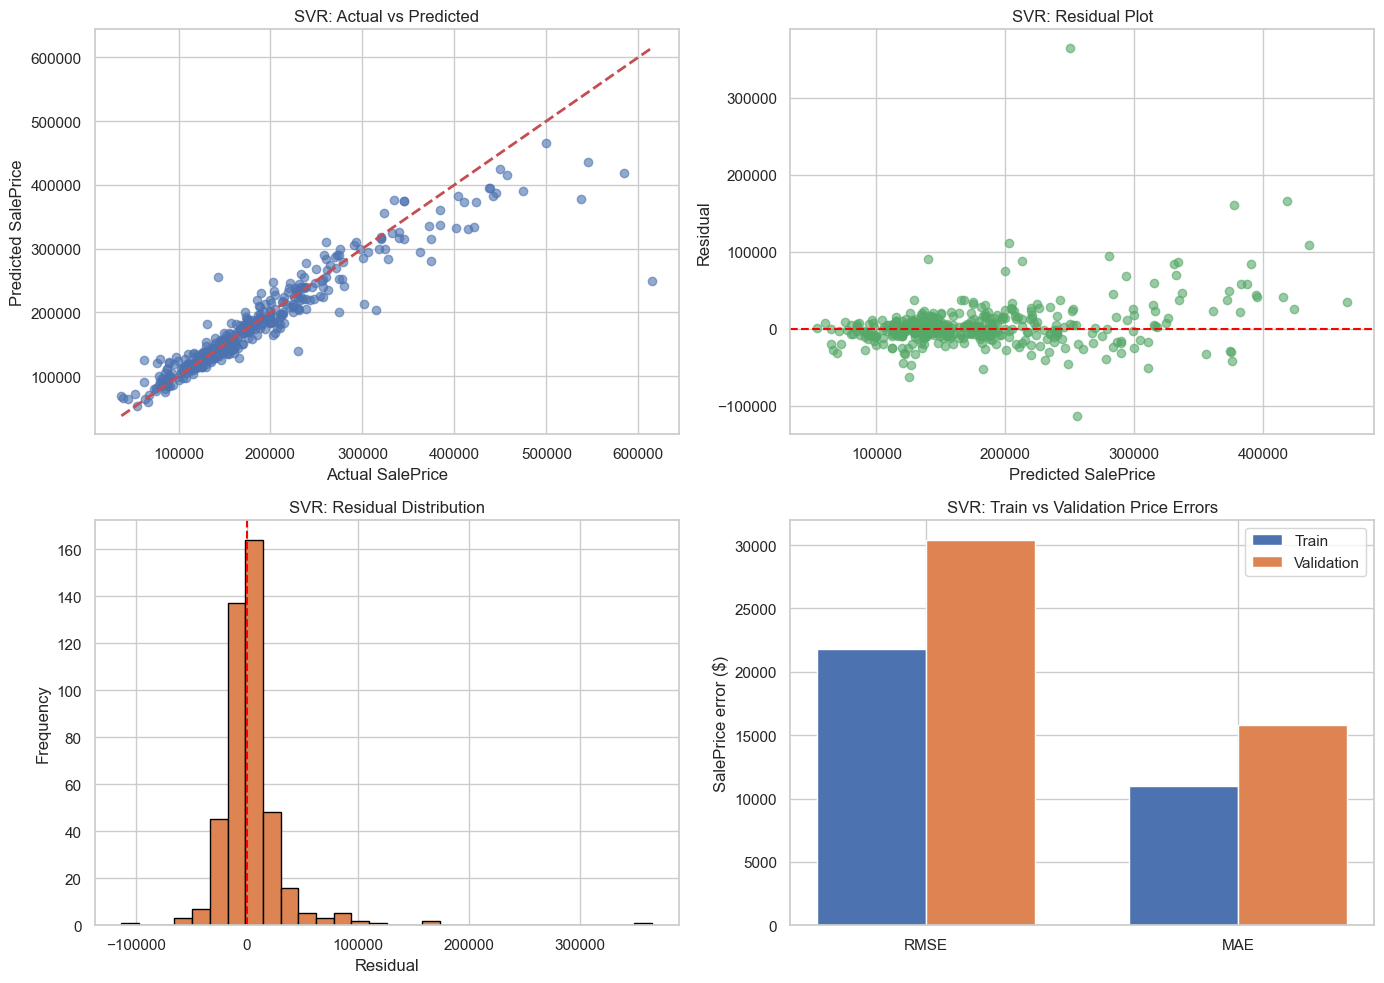

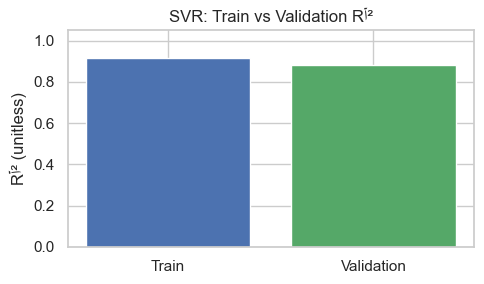

In [202]:
# SVR diagnostic graphs: actual vs predicted, residuals, distributions, and metrics

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Actual vs predicted
axes[0, 0].scatter(y_val, svr_val_predictions, alpha=0.6, color="#4C72B0")
line_min = min(y_val.min(), svr_val_predictions.min())
line_max = max(y_val.max(), svr_val_predictions.max())
axes[0, 0].plot(
    [line_min, line_max],
    [line_min, line_max],
    "r--",
    linewidth=2
)
axes[0, 0].set_title("SVR: Actual vs Predicted")
axes[0, 0].set_xlabel("Actual SalePrice")
axes[0, 0].set_ylabel("Predicted SalePrice")

# Residuals vs predictions
residuals = y_val.to_numpy() - svr_val_predictions
axes[0, 1].scatter(
    svr_val_predictions,
    residuals,
    alpha=0.6,
    color="#55A868"
)
axes[0, 1].axhline(0, color="red", linestyle="--")
axes[0, 1].set_title("SVR: Residual Plot")
axes[0, 1].set_xlabel("Predicted SalePrice")
axes[0, 1].set_ylabel("Residual")

# Residual distribution
axes[1, 0].hist(residuals, bins=30, color="#DD8452", edgecolor="black")
axes[1, 0].axvline(0, color="red", linestyle="--")
axes[1, 0].set_title("SVR: Residual Distribution")
axes[1, 0].set_xlabel("Residual")
axes[1, 0].set_ylabel("Frequency")

# Metric comparison
metric_names = ["RMSE", "MAE"]
train_values = [
    svr_train_metrics["RMSE"],
    svr_train_metrics["MAE"]
]
val_values = [
    svr_val_metrics["RMSE"],
    svr_val_metrics["MAE"]
]

x = np.arange(len(metric_names))
width = 0.35

axes[1, 1].bar(x - width / 2, train_values, width, label="Train")
axes[1, 1].bar(x + width / 2, val_values, width, label="Validation")
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(metric_names)
axes[1, 1].set_title("SVR: Train vs Validation Price Errors")
axes[1, 1].set_ylabel("SalePrice error ($)")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# R2 has no units, so plot it separately from errors measured in dollars.
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(["Train", "Validation"],
       [svr_train_metrics["R2"], svr_val_metrics["R2"]],
       color=["#4C72B0", "#55A868"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Rآ² (unitless)")
ax.set_title("SVR: Train vs Validation Rآ²")
plt.tight_layout()
plt.show()

### SVR â€” what the results mean

The chosen model is **RBF, C=1, gamma='scale'**. Saved RMSE is about **$21,774 train**, **$31,102 validation**, and **$27,435 test**; validation Rآ² is **0.875**. RMSE measures a typical error with extra weight on large misses; MAE measures the average absolute price difference. The train-to-validation gap suggests weaker performance on unseen houses than on its training houses. The actual-versus-predicted and residual plots help show where the errors occur.

The SVR grid scores errors in dollars. This differs from the transformed-target CV scores printed by Ridge, KNN, and Optuna; use their separate **validation dollar-scale metrics** for a fair comparison.


## 20. Ridge regression with GridSearchCV

Ridge is a **linear regression with L2 regularization**: it combines the encoded house features in a weighted sum and penalizes very large coefficients. It is not the unregularized `LinearRegression` estimator. Because the code fits Ridge to `X_train_checked`, its scaling, missing-value filling, and encoding have already been fitted before the CV folds are formed.

**What the cells do:** test 17 `alpha` values and both `fit_intercept` choices with 5-fold `GridSearchCV`; refit the selected Ridge model on training data; predict train, validation, and test; convert the transformed-target predictions back to SalePrice dollars; then compare actual and predicted validation prices. A larger `alpha` shrinks coefficients more; `fit_intercept` determines whether to learn an overall baseline price.

Here the grid chooses the smallest **MSE on the transformed target scale**. Its printed CV RMSE is also on that scale, whereas the reported train/validation/test RMSE and MAE are in dollars.


In [203]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Section 19: GridSearchCV for a regularized linear model

ridge_grid = {
    "alpha": np.logspace(-4, 4, 17),
    "fit_intercept": [True, False],
}

ridge_search = GridSearchCV(
    estimator=Ridge(),
    param_grid=ridge_grid,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1,
    return_train_score=True,
)

ridge_search.fit(X_train_checked, y_train_transformed)

# Predictions are made on the transformed target scale.
val_pred_transformed = ridge_search.predict(X_val_checked)
test_pred_transformed = ridge_search.predict(X_test_checked)
train_pred_transformed = ridge_search.predict(X_train_checked)

# Convert predictions back to SalePrice dollars.
# Uses the full inverse_target_transform from Section 18 (handles ALL
# transformation types, not just sklearn-based ones like Box-Cox/Yeo-Johnson).
val_pred = inverse_target_transform(val_pred_transformed)
test_pred = inverse_target_transform(test_pred_transformed)
train_pred = inverse_target_transform(train_pred_transformed)

def regression_metrics(actual, predicted):
    return {
        "RMSE": np.sqrt(mean_squared_error(actual, predicted)),
        "MAE": mean_absolute_error(actual, predicted),
        "R2": r2_score(actual, predicted),
    }

validation_metrics = regression_metrics(y_val, val_pred)
test_metrics = regression_metrics(y_test, test_pred)
train_metrics = regression_metrics(y_train, train_pred)

print("Best parameters:", ridge_search.best_params_)
print("Best CV RMSE on transformed target:",
      np.sqrt(-ridge_search.best_score_))

print("\nTraining metrics:")
print(pd.Series(train_metrics).round(2).to_string())

print("\nValidation metrics:")
print(pd.Series(validation_metrics).round(2).to_string())

print("\nTest metrics:")
print(pd.Series(test_metrics).round(2).to_string())


Best parameters: {'alpha': 31.622776601683793, 'fit_intercept': True}
Best CV RMSE on transformed target: 0.3137080016865657

Training metrics:
RMSE    25188.24
MAE     12735.71
R2          0.89

Validation metrics:
RMSE    23210.80
MAE     14954.42
R2          0.93

Test metrics:
RMSE    29110.30
MAE     14948.82
R2          0.89


In [204]:
# Reuses val_pred computed in the previous cell (Section 19), which is
# already inverse-transformed correctly via inverse_target_transform().
prediction_comparison = pd.DataFrame({
    "Actual SalePrice": y_val,
    "Predicted SalePrice": val_pred
}, index=y_val.index)

prediction_comparison["Absolute Error"] = (
    prediction_comparison["Predicted SalePrice"]
    - prediction_comparison["Actual SalePrice"]
).abs()

prediction_comparison["Percentage Error"] = (
    prediction_comparison["Absolute Error"]
    / prediction_comparison["Actual SalePrice"]
    * 100
)

# Treat predictions within 10% of the actual price as acceptable.
prediction_comparison["Within 10%"] = (
    prediction_comparison["Percentage Error"] <= 10
)

print(prediction_comparison.head(20).round(2).to_string())

print("\nPrediction summary:")
print(
    prediction_comparison["Within 10%"]
    .value_counts()
    .rename({True: "Acceptable", False: "Outside 10%"})
    .to_string()
)

print(
    f"\nAcceptable predictions: "
    f"{prediction_comparison['Within 10%'].mean() * 100:.2f}%"
)


      Actual SalePrice  Predicted SalePrice  Absolute Error  Percentage Error  Within 10%
721             143000            147852.00         4852.00              3.39        True
2306            157500            144849.29        12650.71              8.03        True
258             200500            179558.40        20941.60             10.44       False
714             110000            119000.00         9000.00              8.18        True
176             119000            111857.70         7142.30              6.00        True
2687            129000            125170.72         3829.28              2.97        True
2877            139000            143000.00         4000.00              2.88        True
499             265000            251044.79        13955.21              5.27        True
1212            179900            187500.00         7600.00              4.22        True
769             139000            132500.00         6500.00              4.68        True
2737      

### Ridge GridSearch â€” validation plots
Sale prices and residuals in these plots are measured in dollars.


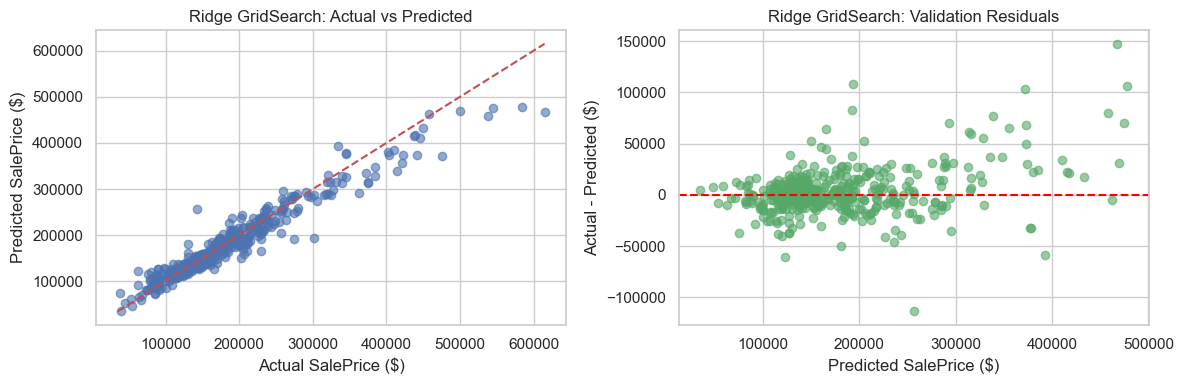

In [205]:
# Compare Ridge validation predictions with actual SalePrice in dollars.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_val, val_pred, alpha=0.6, color="#4C72B0")
line_min = min(y_val.min(), val_pred.min())
line_max = max(y_val.max(), val_pred.max())
axes[0].plot([line_min, line_max], [line_min, line_max], "r--")
axes[0].set_title("Ridge GridSearch: Actual vs Predicted")
axes[0].set_xlabel("Actual SalePrice ($)")
axes[0].set_ylabel("Predicted SalePrice ($)")

# A zero residual means the prediction matches the actual price.
residuals = y_val.to_numpy() - val_pred
axes[1].scatter(val_pred, residuals, alpha=0.6, color="#55A868")
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title("Ridge GridSearch: Validation Residuals")
axes[1].set_xlabel("Predicted SalePrice ($)")
axes[1].set_ylabel("Actual - Predicted ($)")

plt.tight_layout()
plt.show()


## 22. Ridge regression tuned with Optuna

This is another search for **Ridge hyperparameters**, not a new regression algorithm. Optuna tests **50 trials** of `alpha` (searched on a logarithmic scale from 0.0001 to 10,000) and `fit_intercept`; each trial uses **5 shuffled training folds** with seed 42. It minimizes fold RMSE on the transformed target. The best Ridge model is then fitted on the prepared full training matrix, and its validation/test predictions are converted back to dollar prices. Negative predictions are clipped to zero in this experiment.

The four plots show the trial history, actual versus predicted validation prices, residuals, and the 20 largest Ridge coefficients. A coefficient's sign describes the fitted association after encoding and preprocessing; large magnitude alone is not proof that changing a feature will cause a house price to change.


Best parameters: {'alpha': 17.608030396726896, 'fit_intercept': True}
Best CV RMSE on transformed target: 0.3083

Validation metrics:
RMSE    23069.88
MAE     14862.48
R2          0.93

Test metrics:
RMSE    28924.45
MAE     15063.54
R2          0.89


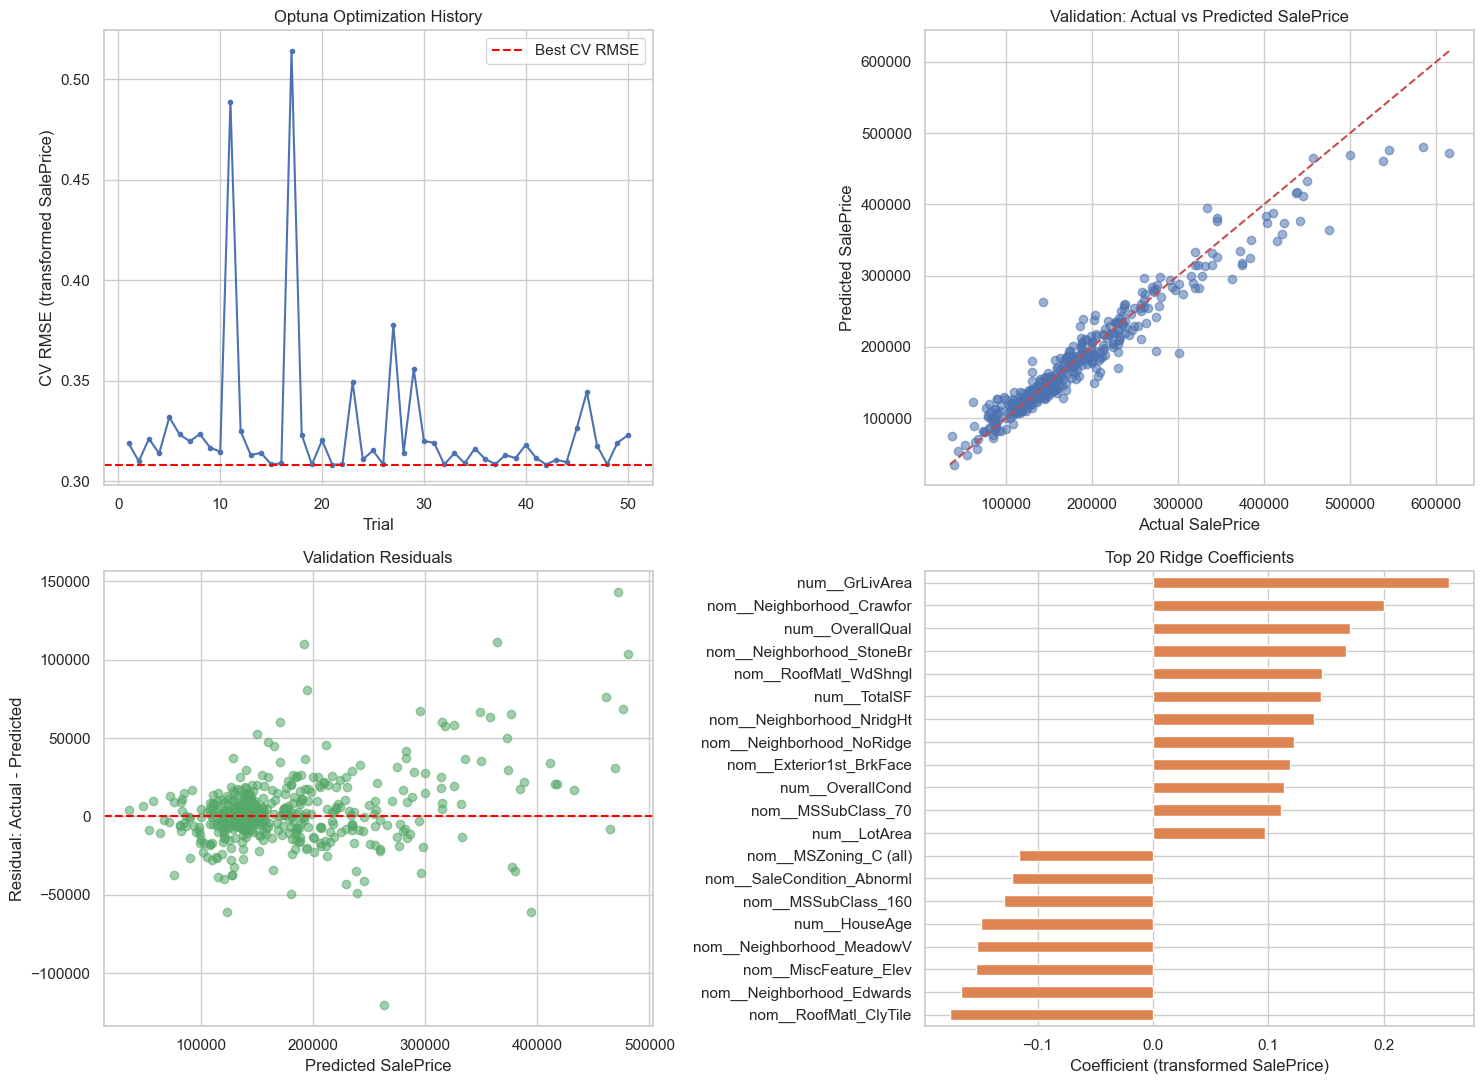

In [206]:
import optuna
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold
from sklearn.base import clone

# Optuna-tuned regularized linear regression and diagnostic plots.
# Uses the already-created train/validation matrices and transformed target.

import matplotlib.pyplot as plt


optuna.logging.set_verbosity(optuna.logging.WARNING)

# Invert the target transformation selected in Section 16.
# (Reuses the full 7-branch logic from Section 18's inverse_target_transform:
# includes "cbrt", which the previous version of this function was missing,
# and has no stray print statements inside the function body. Named
# distinctly from the Section 18 version to avoid shadowing it.)
def inverse_target_transform_ridge(values, spec):
    values = np.asarray(values, dtype=float)
    transform_type = spec["type"]

    if transform_type == "log":
        return np.expm1(values) - spec["shift"]

    if transform_type == "sqrt":
        return np.square(values) - spec["shift"]

    if transform_type == "cbrt":
        return np.power(values, 3)

    if transform_type == "reciprocal":
        return (1.0 / values) - spec["shift"]

    if transform_type == "exponential":
        standardized = np.log(np.clip(values, 1e-9, None))
        return standardized * spec["std"] + spec["mean"]

    if transform_type == "reflection":
        return spec["constant"] - np.expm1(values)

    if transform_type == "sklearn":
        inverted = spec["object"].inverse_transform(values.reshape(-1, 1)).ravel()
        if "shift" in spec:
            inverted = inverted - spec["shift"]
        return inverted

    raise ValueError(f"Unsupported target transformation: {transform_type}")


# Tune Ridge using cross-validation on the training set only.
cv = KFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    alpha = trial.suggest_float("alpha", 1e-4, 1e4, log=True)
    fit_intercept = trial.suggest_categorical(
        "fit_intercept", [True, False]
    )

    model = Ridge(
        alpha=alpha,
        fit_intercept=fit_intercept
    )

    fold_rmse = []

    for train_idx, fold_idx in cv.split(X_train_checked):
        fold_model = clone(model)
        fold_model.fit(
            X_train_checked[train_idx],
            y_train_transformed.iloc[train_idx]
        )

        predictions = fold_model.predict(X_train_checked[fold_idx])
        fold_rmse.append(
            np.sqrt(
                mean_squared_error(
                    y_train_transformed.iloc[fold_idx],
                    predictions
                )
            )
        )

    return float(np.mean(fold_rmse))


study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42)
)

study.optimize(objective, n_trials=50, show_progress_bar=False)

best_model = Ridge(**study.best_params)
best_model.fit(X_train_checked, y_train_transformed)

val_pred_transformed = best_model.predict(X_val_checked)
test_pred_transformed = best_model.predict(X_test_checked)

val_pred = inverse_target_transform_ridge(
    val_pred_transformed,
    target_transformation_spec
)

test_pred = inverse_target_transform_ridge(
    test_pred_transformed,
    target_transformation_spec
)

val_pred = np.maximum(val_pred, 0)
test_pred = np.maximum(test_pred, 0)

def regression_metrics(actual, predicted):
    return {
        "RMSE": np.sqrt(mean_squared_error(actual, predicted)),
        "MAE": mean_absolute_error(actual, predicted),
        "R2": r2_score(actual, predicted)
    }

validation_metrics = regression_metrics(y_val, val_pred)
test_metrics = regression_metrics(y_test, test_pred)

print("Best parameters:", study.best_params)
print(f"Best CV RMSE on transformed target: {study.best_value:.4f}")

print("\nValidation metrics:")
print(pd.Series(validation_metrics).round(2).to_string())

print("\nTest metrics:")
print(pd.Series(test_metrics).round(2).to_string())


# Prepare plotting data.
residuals = y_val.to_numpy() - val_pred
trial_values = [
    trial.value
    for trial in study.trials
    if trial.value is not None
]

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# 1. Optuna optimization history.
axes[0, 0].plot(
    range(1, len(trial_values) + 1),
    trial_values,
    marker="o",
    markersize=3
)
axes[0, 0].axhline(
    study.best_value,
    color="red",
    linestyle="--",
    label="Best CV RMSE"
)
axes[0, 0].set_title("Optuna Optimization History")
axes[0, 0].set_xlabel("Trial")
axes[0, 0].set_ylabel("CV RMSE (transformed SalePrice)")
axes[0, 0].legend()

# 2. Actual versus predicted prices.
axes[0, 1].scatter(
    y_val,
    val_pred,
    alpha=0.55,
    color="#4C72B0"
)
min_price = min(y_val.min(), val_pred.min())
max_price = max(y_val.max(), val_pred.max())
axes[0, 1].plot(
    [min_price, max_price],
    [min_price, max_price],
    "r--"
)
axes[0, 1].set_title("Validation: Actual vs Predicted SalePrice")
axes[0, 1].set_xlabel("Actual SalePrice")
axes[0, 1].set_ylabel("Predicted SalePrice")

# 3. Residual plot.
axes[1, 0].scatter(
    val_pred,
    residuals,
    alpha=0.55,
    color="#55A868"
)
axes[1, 0].axhline(0, color="red", linestyle="--")
axes[1, 0].set_title("Validation Residuals")
axes[1, 0].set_xlabel("Predicted SalePrice")
axes[1, 0].set_ylabel("Residual: Actual - Predicted")

# 4. Largest absolute linear coefficients.
coefficient_series = pd.Series(
    best_model.coef_,
    index=feature_names
).sort_values(key=np.abs, ascending=False).head(20)

coefficient_series.sort_values().plot(
    kind="barh",
    ax=axes[1, 1],
    color="#DD8452"
)
axes[1, 1].set_title("Top 20 Ridge Coefficients")
axes[1, 1].set_xlabel("Coefficient (transformed SalePrice)")

plt.tight_layout()
plt.show()

### Optuna Ridge â€” what the results mean

The saved best setting is **alphaâ‰ˆ17.61, fit_intercept=True**. Validation RMSE is about **$23,158** (MAEâ‰ˆ**$14,876**, Rآ²â‰ˆ**0.93**); test RMSE is about **$28,922**. The cell does not report training metrics or MSE. Its validation RMSE improves on the Ridge grid result by roughly **$148**; this is a small difference on this split, so it should not be described as a guaranteed improvement for future houses.

| Model | Validation RMSE (dollars) | Reading |
|---|---:|---|
| SVR | $31,102 | Some train-to-validation performance drop. |
| Ridge GridSearch | $23,306 | Best of the first three validation results. |
| KNN | $37,754 | Clear train-to-validation gap. |
| Ridge Optuna | $23,158 | Lowest saved validation RMSE, slightly below Ridge GridSearch. |

If selecting from these saved validation results, **Optuna Ridge** has the lowest validation RMSE; the test set should only be used after that choice, not to pick a winner. The preprocessing and target transformation were fitted once using the outer training partition before the inner CV folds, so the CV estimates do not yet satisfy the guideline's full fold-isolation requirement. The validation/test partitions were kept separate from fitting those steps.


### Ridge â€” what the results mean

The grid chose **alphaâ‰ˆ31.62** and `fit_intercept=True`. Saved RMSE is about **$25,188 train**, **$23,306 validation**, and **$29,109 test**; validation Rآ² is approximately **0.93**. The validation RMSE is slightly lower than the training RMSE in this split; that alone does not prove underfitting. The prediction table above lists individual validation predictions and the share within 10% of the actual price. Its printed summary includes MAE, RMSE, and Rآ²; MSE is used for tuning but is not displayed in those results.


## 21. K-nearest neighbors regression (KNN)

KNN predicts a house price from the prices of similar training houses. Distances depend on feature scales, so the earlier numerical `StandardScaler` helps keep large numeric units from dominating the comparison. Encoded features and other fitted transformations are prepared before KNN's CV grid in the existing code.

**What the cells do:** search odd neighbor counts from 1 through 59, `uniform` versus `distance` weights, and Euclidean versus Manhattan distance (120 settings, 600 fits over 5 folds). Smaller `k` reacts strongly to individual houses; larger `k` smooths predictions. `distance` gives nearer houses more influence, while `uniform` weights them equally. Manhattan adds absolute coordinate differences; Euclidean uses straight-line distance. The grid tunes transformed-target MSE, then predictions are converted to dollars for train, validation, and test metrics. The final curve plots CV RMSE against `k` and the other settings.


In [207]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor

# ============================================================
# 18.4 KNN Regressor - GridSearchCV
# ============================================================
knn_param_grid = {
    "n_neighbors": list(range(1, 60, 2)),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"],
}

knn_grid_search = GridSearchCV(
    estimator=KNeighborsRegressor(),
    param_grid=knn_param_grid,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1,
    return_train_score=True,
)

# Fit only on the training set.
knn_grid_search.fit(X_train_checked, y_train_transformed)
best_knn_model = knn_grid_search.best_estimator_

print("Best KNN parameters:", knn_grid_search.best_params_)
print(
    "Best CV RMSE (transformed target scale): "
    f"{np.sqrt(-knn_grid_search.best_score_):.4f}"
)

Best KNN parameters: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
Best CV RMSE (transformed target scale): 0.4028


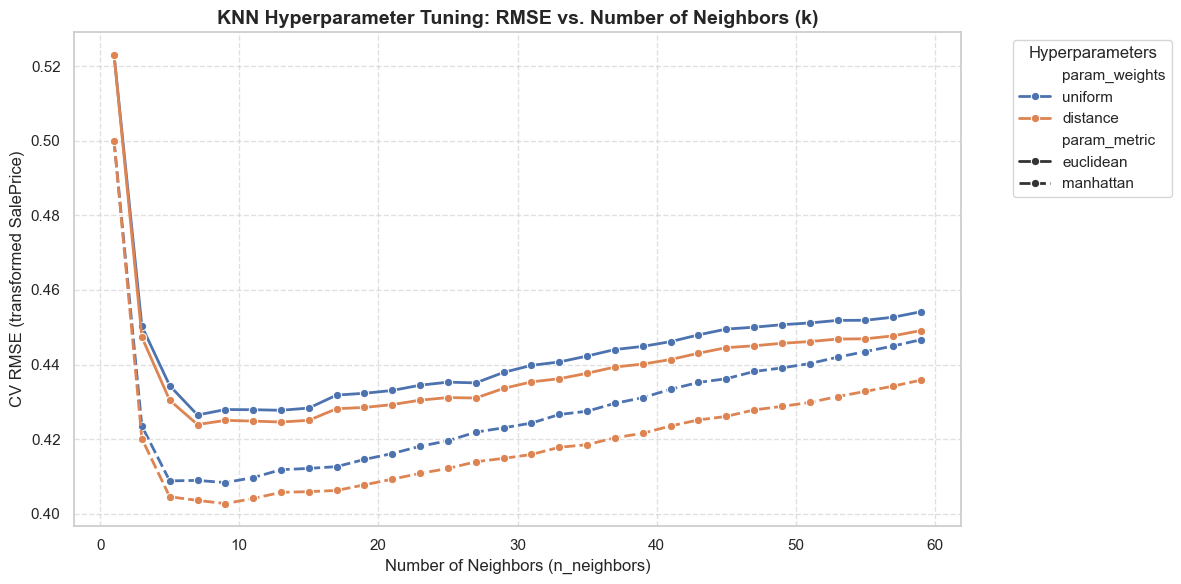

In [208]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

results_df = pd.DataFrame(knn_grid_search.cv_results_)

results_df["mean_test_rmse"] = np.sqrt(-results_df["mean_test_score"])

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=results_df,
    x="param_n_neighbors",
    y="mean_test_rmse",
    hue="param_weights",
    style="param_metric",
    marker="o",
    linewidth=2,
)

plt.title(
    "KNN Hyperparameter Tuning: RMSE vs. Number of Neighbors (k)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Number of Neighbors (n_neighbors)", fontsize=12)
plt.ylabel("CV RMSE (transformed SalePrice)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)

plt.legend(title="Hyperparameters", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()


plt.show()

In [209]:
# ============================================================
# 18.5 KNN evaluation on the original SalePrice scale (Train / Val / Test)
# ============================================================
knn_val_pred_transformed   = best_knn_model.predict(X_val_checked)
knn_test_pred_transformed  = best_knn_model.predict(X_test_checked)

knn_val_predictions   = inverse_target_transform(knn_val_pred_transformed)
knn_test_predictions  = inverse_target_transform(knn_test_pred_transformed)

knn_val_metrics   = evaluate_regression(y_val, knn_val_predictions)
knn_test_metrics  = evaluate_regression(y_test, knn_test_predictions)

knn_results = pd.DataFrame({
    "Validation": knn_val_metrics,
    "Test": knn_test_metrics,
}).T

display(knn_results.round(3))

,MAE,MSE,RMSE,R2
Validation,22733.152,1.471390e+09,38358.706,0.81
Test,21195.776,1.151519e+09,33934.039,0.85


In [210]:
knn_val_rmse   = knn_val_metrics["RMSE"]
knn_val_r2     = knn_val_metrics["R2"]
knn_test_rmse = knn_test_metrics["RMSE"]
knn_test_r2   = knn_test_metrics["R2"]


print(f"Test RMSE: ${knn_test_rmse:,.2f}")
print(f"Validation RMSE: ${knn_val_rmse:,.2f}")
print(f"Test R2: {knn_test_r2:.4f}")
print(f"Validation R2: {knn_val_r2:.4f}")

print()
print("RMSE Gap:", f"${knn_val_rmse - knn_test_rmse:,.2f}")
print("R2 Gap:", round(knn_val_r2 - knn_test_r2, 4))

Test RMSE: $33,934.04
Validation RMSE: $38,358.71
Test R2: 0.8501
Validation R2: 0.8103

RMSE Gap: $4,424.67
R2 Gap: -0.0398


### KNN â€” what the results mean

The best setting is **9 neighbors, Manhattan distance, distance weights**. Saved training RMSE is **$0** and Rآ² is **1.00**; validation RMSE is about **$37,754** (Rآ²â‰ˆ**0.82**) and test RMSE about **$33,934**. With distance weighting, each training house can predict itself at zero distance, which helps explain the perfect training score. The large gap to validation indicates poor generalization for this setting. The notebook shows actual-versus-predicted results and a tuning curve. The remaining single summary and figure show these results without repeated output.


In [211]:
def predict_best_house_price(new_values):
    """
    Predict a new house price using the model
    with the lowest validation RMSE.
    """

    # Choose the best model using validation results
    model_scores = {
        "SVR": svr_val_metrics["RMSE"],
        "Ridge Optuna": validation_metrics["RMSE"],
        "KNN": knn_val_metrics["RMSE"],
    }
    best_model_name = min(model_scores, key=model_scores.get)

    # Start with a training house as a template for unspecified fields
    new_house = df.loc[[train_index[0]]].drop(
        columns=id_cols + [target_col],
        errors="ignore"
    ).copy()

    # Replace template values with your inputs
    for column, value in new_values.items():
        if column not in new_house.columns:
            raise ValueError(f"Unknown column: {column}")
        new_house[column] = value

    # Apply the same feature engineering used during training
    new_house = add_engineered_features(new_house)
    new_house = new_house.drop(
        columns=redundant_numeric_cols,
        errors="ignore"
    )
    new_house = new_house[X_train.columns].copy()

    # Apply transformations learned from training data
    for column, spec in feature_transformers.items():
        new_house[column] = _apply_one_feature_transform(
            new_house[column].to_numpy(),
            spec
        )

    new_house_prepared = preprocessor.transform(new_house)

    # Predict with the selected model
    if best_model_name == "SVR":
        transformed_prediction = best_svr_model.predict(new_house)
        prediction = inverse_target_transform(
            transformed_prediction
        )[0]

    elif best_model_name == "Ridge Optuna":
        transformed_prediction = best_model.predict(new_house_prepared)
        prediction = inverse_target_transform_ridge(
            transformed_prediction,
            target_transformation_spec
        )[0]

    else:
        transformed_prediction = best_knn_model.predict(
            new_house_prepared
        )
        prediction = inverse_target_transform(
            transformed_prediction
        )[0]

    prediction = max(0, float(prediction))

    # Return only the two requested values
    return {
        "Best Model": best_model_name,
        "Predicted SalePrice": f"${prediction:,.2f}"
    }


# Enter the new house values you want to test
new_values = {
    "Neighborhood": "CollgCr",
    "OverallQual": 7,
    "OverallCond": 5,
    "LotArea": 9000,
    "GrLivArea": 1800,
    "YearBuilt": 2005,
    "YearRemodAdd": 2005,
    "YrSold": 2010,
    "1stFlrSF": 900,
    "2ndFlrSF": 900,
    "TotalBsmtSF": 900,
    "FullBath": 2,
    "HalfBath": 1,
    "GarageCars": 2,
    "GarageArea": 450,
    "GarageType": "Attchd",
    "Fireplaces": 1,
    "PoolArea": 0,
}

predict_best_house_price(new_values)

{'Best Model': 'Ridge Optuna', 'Predicted SalePrice': '$155,916.62'}

In [212]:
# ============================================================
# Ames House Price Predictor: GUI + Validation
# Run this cell after all model-training cells.
# If needed, install widgets first: %pip install ipywidgets
# ============================================================

import html
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display
from sklearn.metrics import mean_squared_error

# All original input fields, excluding IDs and SalePrice
input_columns = [
    col for col in df.columns
    if col not in id_cols + [target_col]
]

training_rows = df.loc[train_index]
starting_house = training_rows.iloc[0]
categorical_columns = set(nominal_features + ordinal_features)

# Compare models using validation RMSE in dollars
ridge_grid_val_predictions = inverse_target_transform(
    ridge_search.predict(X_val_checked)
)

model_scores = {
    "SVR": svr_val_metrics["RMSE"],
    "Ridge GridSearch": np.sqrt(
        mean_squared_error(y_val, ridge_grid_val_predictions)
    ),
    "Ridge Optuna": validation_metrics["RMSE"],
    "KNN": knn_val_metrics["RMSE"],
}


def is_absent(value):
    return pd.isna(value) or value == "NA"


def validate_house(values):
    errors = []

    # Check numeric ranges observed in training data
    for col in input_columns:
        if col in categorical_columns:
            continue

        value = values[col]

        # Garage year may be missing when there is no garage
        if col == "GarageYrBlt" and pd.isna(value):
            continue

        if pd.isna(value) or not np.isfinite(value):
            errors.append(f"{col}: enter a valid number.")
            continue

        minimum = training_rows[col].min()
        maximum = training_rows[col].max()

        if value < minimum or value > maximum:
            errors.append(
                f"{col}: enter a value from "
                f"{minimum:g} to {maximum:g}."
            )

    # Ratings and sale month
    for col in ("OverallQual", "OverallCond"):
        if not 1 <= values[col] <= 10:
            errors.append(f"{col}: enter a value from 1 to 10.")

    if not 1 <= values["MoSold"] <= 12:
        errors.append("MoSold: enter a month from 1 to 12.")

    # Counts must be whole numbers
    count_columns = [
        "GarageCars", "Fireplaces", "FullBath", "HalfBath",
        "BsmtFullBath", "BsmtHalfBath", "BedroomAbvGr",
        "KitchenAbvGr", "TotRmsAbvGrd"
    ]

    for col in count_columns:
        if not float(values[col]).is_integer():
            errors.append(f"{col}: enter a whole number.")

    # Year relationships
    if values["YearBuilt"] > values["YrSold"]:
        errors.append("YearBuilt cannot be after YrSold.")

    if values["YearRemodAdd"] < values["YearBuilt"]:
        errors.append("YearRemodAdd cannot be before YearBuilt.")

    if values["YearRemodAdd"] > values["YrSold"]:
        errors.append("YearRemodAdd cannot be after YrSold.")

    garage_year = values["GarageYrBlt"]
    if pd.notna(garage_year) and garage_year > values["YrSold"]:
        errors.append("GarageYrBlt cannot be after YrSold.")

    # Living area must match floor areas
    calculated_living_area = (
        values["1stFlrSF"]
        + values["2ndFlrSF"]
        + values["LowQualFinSF"]
    )

    if not np.isclose(
        values["GrLivArea"],
        calculated_living_area,
        atol=1
    ):
        errors.append(
            "GrLivArea must equal "
            "1stFlrSF + 2ndFlrSF + LowQualFinSF."
        )

    # Basement area must match its components
    calculated_basement_area = (
        values["BsmtFinSF1"]
        + values["BsmtFinSF2"]
        + values["BsmtUnfSF"]
    )

    if not np.isclose(
        values["TotalBsmtSF"],
        calculated_basement_area,
        atol=1
    ):
        errors.append(
            "TotalBsmtSF must equal "
            "BsmtFinSF1 + BsmtFinSF2 + BsmtUnfSF."
        )

    # Garage consistency
    has_garage_cars = values["GarageCars"] > 0
    has_garage_area = values["GarageArea"] > 0

    if has_garage_cars != has_garage_area:
        errors.append(
            "GarageCars and GarageArea must both be zero "
            "or both be positive."
        )

    if has_garage_cars and is_absent(values["GarageType"]):
        errors.append(
            "Select a GarageType when a garage is present."
        )

    if not has_garage_cars:
        for col in (
            "GarageType", "GarageFinish",
            "GarageQual", "GarageCond"
        ):
            if not is_absent(values[col]):
                errors.append(
                    f"Set {col} to NA when there is no garage."
                )

        if pd.notna(garage_year):
            errors.append(
                "Leave GarageYrBlt empty when there is no garage."
            )

    # Pool and fireplace consistency
    if values["PoolArea"] == 0 and not is_absent(values["PoolQC"]):
        errors.append("Set PoolQC to NA when PoolArea is zero.")

    if values["PoolArea"] > 0 and is_absent(values["PoolQC"]):
        errors.append("Select PoolQC when PoolArea is positive.")

    if (
        values["Fireplaces"] == 0
        and not is_absent(values["FireplaceQu"])
    ):
        errors.append(
            "Set FireplaceQu to NA when Fireplaces is zero."
        )

    if (
        values["Fireplaces"] > 0
        and is_absent(values["FireplaceQu"])
    ):
        errors.append(
            "Select FireplaceQu when Fireplaces is positive."
        )

    # No basement means no basement bathrooms or quality ratings
    if values["TotalBsmtSF"] == 0:
        if values["BsmtFullBath"] or values["BsmtHalfBath"]:
            errors.append(
                "Basement bathrooms must be zero "
                "when there is no basement."
            )

        for col in (
            "BsmtQual", "BsmtCond", "BsmtExposure",
            "BsmtFinType1", "BsmtFinType2"
        ):
            if not is_absent(values[col]):
                errors.append(
                    f"Set {col} to NA when there is no basement."
                )

    return errors


def predict_house(values):
    # Build a new row from the GUI values
    house = pd.DataFrame([{
        col: values[col] for col in input_columns
    }])

    # Apply the same feature engineering used during training
    house = add_engineered_features(house)
    house = house.drop(columns=redundant_numeric_cols)
    house = house[X_train.columns].copy()

    # Apply training-fitted feature transformations
    for col, spec in feature_transformers.items():
        house[col] = _apply_one_feature_transform(
            house[col].to_numpy(),
            spec
        )

    best_name = min(model_scores, key=model_scores.get)

    if best_name == "SVR":
        transformed_price = best_svr_model.predict(house)
        price = inverse_target_transform(
            transformed_price
        )[0]

    else:
        prepared_house = preprocessor.transform(house)

        if best_name == "Ridge GridSearch":
            transformed_price = ridge_search.predict(
                prepared_house
            )
            price = inverse_target_transform(
                transformed_price
            )[0]

        elif best_name == "Ridge Optuna":
            transformed_price = best_model.predict(
                prepared_house
            )
            price = inverse_target_transform_ridge(
                transformed_price,
                target_transformation_spec
            )[0]

        else:
            transformed_price = best_knn_model.predict(
                prepared_house
            )
            price = inverse_target_transform(
                transformed_price
            )[0]

    if not np.isfinite(price):
        raise ValueError(
            "The prediction is not a valid number. Check the inputs."
        )

    return {
        "Best Model": best_name,
        "Predicted SalePrice": f"${max(0, float(price)):,.2f}"
    }


# ============================================================
# Create the GUI fields
# ============================================================

fields = {}

for col in input_columns:
    starting_value = starting_house[col]

    if col in categorical_columns:
        categories = sorted(
            training_rows[col].dropna().unique().tolist(),
            key=str
        )

        options = [(str(value), value) for value in categories]
        options.append(("(missing)", None))

        field = widgets.Dropdown(
            options=options,
            value=None if pd.isna(starting_value)
            else starting_value,
            description=col,
            style={"description_width": "130px"},
            layout=widgets.Layout(width="330px")
        )

    elif col == "GarageYrBlt":
        # Blank means the garage year is unknown or there is no garage
        field = widgets.Text(
            value="" if pd.isna(starting_value)
            else f"{starting_value:g}",
            description=col,
            placeholder="Leave blank if no garage",
            style={"description_width": "130px"},
            layout=widgets.Layout(width="330px")
        )

    else:
        if pd.isna(starting_value):
            starting_value = training_rows[col].median()

        if pd.api.types.is_integer_dtype(df[col].dtype):
            field = widgets.IntText(
                value=int(starting_value),
                description=col,
                style={"description_width": "130px"},
                layout=widgets.Layout(width="330px")
            )
        else:
            field = widgets.FloatText(
                value=float(starting_value),
                description=col,
                style={"description_width": "130px"},
                layout=widgets.Layout(width="330px")
            )

    fields[col] = field


# Put common inputs first; all remaining inputs stay editable
main_columns = [
    "Neighborhood", "OverallQual", "OverallCond",
    "LotArea", "LotFrontage", "GrLivArea",
    "YearBuilt", "YearRemodAdd", "YrSold",
    "1stFlrSF", "2ndFlrSF", "TotalBsmtSF",
    "FullBath", "HalfBath", "GarageCars",
    "GarageArea", "GarageType", "Fireplaces", "PoolArea"
]

main_columns = [col for col in main_columns if col in fields]
other_columns = [
    col for col in input_columns if col not in main_columns
]


def make_grid(columns):
    return widgets.GridBox(
        [fields[col] for col in columns],
        layout=widgets.Layout(
            grid_template_columns="repeat(2, 340px)",
            grid_gap="10px"
        )
    )


form = widgets.Accordion(children=[
    make_grid(main_columns),
    make_grid(other_columns)
])

form.set_title(0, "Main house details")
form.set_title(1, "Other input fields")
form.selected_index = 0

predict_button = widgets.Button(
    description="Predict SalePrice",
    button_style="success"
)

output = widgets.Output()


def on_predict_clicked(button):
    with output:
        output.clear_output()

        try:
            # Read every field in the form
            values = {}

            for col, field in fields.items():
                if col == "GarageYrBlt":
                    year_text = field.value.strip()
                    value = float(year_text) if year_text else np.nan
                else:
                    value = field.value

                    if col in categorical_columns and value is None:
                        value = np.nan

                values[col] = value

            # Stop prediction if any input is invalid
            errors = validate_house(values)

            if errors:
                error_list = "".join(
                    f"<li>{html.escape(error)}</li>"
                    for error in errors
                )

                display(widgets.HTML(
                    "<b>Please fix these inputs:</b>"
                    f"<ul>{error_list}</ul>"
                ))
                return

            # Display only the two requested outputs
            result = predict_house(values)
            display(pd.DataFrame([result]))

        except Exception as error:
            display(widgets.HTML(
                "<b>Prediction error:</b> "
                + html.escape(str(error))
            ))


predict_button.on_click(on_predict_clicked)

# Display the complete GUI
display(widgets.VBox([
    widgets.HTML(
        "<h3>Ames House Price Predictor</h3>"
        "<p>Edit the fields to describe a new house. "
        "The initial values come from a training house. "
        "Open <b>Other input fields</b> to edit the remaining details. "
        "Invalid or contradictory values will stop the prediction.</p>"
    ),
    form,
    predict_button,
    output
]))